In [1]:
import sys
print(sys.executable)
!{sys.executable} -m pip install lightgbm

c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Scripts\python.exe


In [2]:
# =========================================================
# 1. Imports
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Display settings
sns.set_style("darkgrid", rc={"axes.facecolor": "white", "grid.color": ".8"})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [3]:
# =========================================================
# 2. Load data
# =========================================================

# Load the final feature dataset and parse the timestamp column as datetime
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])

# Sort the data chronologically and reset the index
df = df.sort_values("timestamp").reset_index(drop=True)

# Show basic checks
print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
display(df.head(2))


Shape: (62544, 38)
Date range: 2019-01-15 00:00:00 to 2026-03-04 23:00:00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,is_holiday,is_hol_or_week,price_volatility_24h,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,total_generation_lag_24h,total_generation_lag_168h,net_export_lag_24h,net_export_lag_168h,is_peak_hour,wind_x_peak,solar_x_demand,is_crisis_period,year,residual_load,load_ramp,renewable_ramp,total_wind_forecast,delta_wind_forecast
0,2019-01-15 00:00:00,35.18,54057.25,4999.00,24868.25,0.0,0,1,1,1.2875,32.516594,False,-3.14,17.94,32.610833,40.085952,False,False,24.249786,21.674999,22.09,82.0,82.150002,21.95,66572.75,68405.50,13188.0,13001.0,0,0.0,0.0,0,2019,24190.00,-1161.0,-1270.50,29867.25,-12156.0
1,2019-01-15 01:00:00,35.82,52364.25,4923.25,25149.75,0.0,1,1,1,1.2000,32.459120,False,-12.00,20.91,34.207500,40.188571,False,False,23.024083,21.674999,22.09,82.0,82.150002,21.95,65146.75,68068.25,13065.0,13461.0,0,0.0,0.0,0,2019,22291.25,-1693.0,205.75,30073.00,-11445.5


In [4]:
# =========================================================
# 3. Define the final feature set
# =========================================================

# Use all columns except timestamp and target as model features
feature_cols = [col for col in df.columns if col not in ["timestamp", "price"]]

# Show basic feature information
print("Number of selected features:", len(feature_cols))
print(feature_cols)

# Preview the selected feature columns
display(df[feature_cols].head(2))

Number of selected features: 36
['load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'is_holiday', 'is_hol_or_week', 'price_volatility_24h', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'total_generation_lag_24h', 'total_generation_lag_168h', 'net_export_lag_24h', 'net_export_lag_168h', 'is_peak_hour', 'wind_x_peak', 'solar_x_demand', 'is_crisis_period', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'total_wind_forecast', 'delta_wind_forecast']


,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,is_holiday,is_hol_or_week,price_volatility_24h,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,total_generation_lag_24h,total_generation_lag_168h,net_export_lag_24h,net_export_lag_168h,is_peak_hour,wind_x_peak,solar_x_demand,is_crisis_period,year,residual_load,load_ramp,renewable_ramp,total_wind_forecast,delta_wind_forecast
0,54057.25,4999.00,24868.25,0.0,0,1,1,1.2875,32.516594,False,-3.14,17.94,32.610833,40.085952,False,False,24.249786,21.674999,22.09,82.0,82.150002,21.95,66572.75,68405.50,13188.0,13001.0,0,0.0,0.0,0,2019,24190.00,-1161.0,-1270.50,29867.25,-12156.0
1,52364.25,4923.25,25149.75,0.0,1,1,1,1.2000,32.459120,False,-12.00,20.91,34.207500,40.188571,False,False,23.024083,21.674999,22.09,82.0,82.150002,21.95,65146.75,68068.25,13065.0,13461.0,0,0.0,0.0,0,2019,22291.25,-1693.0,205.75,30073.00,-11445.5


In [5]:
# =========================================================
# 4. Check the selected feature set
# =========================================================

# Show number of features
print("Number of selected features:", len(feature_cols))

# Show data type counts
display(df[feature_cols].dtypes.value_counts())

# Show missing values in the selected features
display(df[feature_cols].isna().sum().sort_values(ascending=False).head(20))

Number of selected features: 36


float64    27
int64       6
bool        3
Name: count, dtype: int64

load                    0
wind_offshore           0
wind_onshore            0
solar                   0
hour                    0
day_of_week             0
month                   0
temperature             0
wind_speed              0
is_weekend              0
price_lag_24h           0
price_lag_168h          0
price_rolling_24h       0
price_rolling_168h      0
is_holiday              0
is_hol_or_week          0
price_volatility_24h    0
gas_price_lag_24h       0
gas_price_lag_168h      0
coal_price_lag_24h      0
dtype: int64

In [6]:
# =========================================================
# 5. Create the hourly train, validation, and test split
# =========================================================

# Create chronological masks
train_mask = df["timestamp"] < "2025-01-01"
val_mask = (df["timestamp"] >= "2025-01-01") & (df["timestamp"] < "2025-07-01")
test_mask = df["timestamp"] >= "2025-07-01"

# Create split dataframes
train_df = df.loc[train_mask].copy()
val_df = df.loc[val_mask].copy()
test_df = df.loc[test_mask].copy()

# Show split shapes
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

# Show split date ranges
print("Train range:", train_df["timestamp"].min(), "to", train_df["timestamp"].max())
print("Validation range:", val_df["timestamp"].min(), "to", val_df["timestamp"].max())
print("Test range:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())

train_df: (52272, 38)
val_df: (4344, 38)
test_df: (5928, 38)
Train range: 2019-01-15 00:00:00 to 2024-12-31 23:00:00
Validation range: 2025-01-01 00:00:00 to 2025-06-30 23:00:00
Test range: 2025-07-01 00:00:00 to 2026-03-04 23:00:00


In [7]:
# =========================================================
# 6. Create sample weights for the training period
# =========================================================

# Create default training weights
train_weights = pd.Series(1.0, index=train_df.index)

# Assign regime-based weights
train_weights.loc[(train_df["timestamp"] >= "2019-01-01") & (train_df["timestamp"] < "2021-01-01")] = 0.6
train_weights.loc[(train_df["timestamp"] >= "2021-01-01") & (train_df["timestamp"] < "2023-01-01")] = 0.3
train_weights.loc[(train_df["timestamp"] >= "2023-01-01") & (train_df["timestamp"] < "2025-01-01")] = 1.0

# Show the weight distribution
display(train_weights.value_counts().sort_index())
display(train_weights.head())

0.3    17520
0.6    17208
1.0    17544
Name: count, dtype: int64

0    0.6
1    0.6
2    0.6
3    0.6
4    0.6
dtype: float64

In [8]:
# =========================================================
# 7. Create hourly feature matrices and targets
# =========================================================

# Create feature matrices
X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

# Create targets
y_train = train_df["price"].copy()
y_val = val_df["price"].copy()
y_test = test_df["price"].copy()

# Show shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (52272, 36)
X_val: (4344, 36)
X_test: (5928, 36)
y_train: (52272,)
y_val: (4344,)
y_test: (5928,)


In [9]:
# =========================================================
# 8. Build the naive hourly benchmark
# =========================================================

# Define a function for the naive hourly forecast
def predict_price_lag_hourly(df_input, price_col="price", day_col="day_of_week"):
    # Create 24-hour and 168-hour lagged prices
    lag_1 = df_input[price_col].shift(24)
    lag_7 = df_input[price_col].shift(168)

    # Use D-1 for Tue, Wed, Thu, Fri, Sun and D-7 for Mon, Sat
    lag_1_days = {1, 2, 3, 4, 6}

    # Return the naive prediction series
    return pd.Series(
        np.where(df_input[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df_input.index
    )

# Create naive hourly predictions for the full dataframe
df["price_pred_naive"] = predict_price_lag_hourly(df)

# Extract naive predictions for validation and test
y_val_naive = df.loc[val_df.index, "price_pred_naive"].copy()
y_test_naive = df.loc[test_df.index, "price_pred_naive"].copy()

In [10]:
# =========================================================
# 9. Define evaluation metrics
# =========================================================

# Define hourly MAE
def mae_hourly(y_true, y_pred):
    # Compute the mean absolute error
    return mean_absolute_error(y_true, y_pred)

# Define daily average error based on hourly predictions
def dae_hourly(y_true, y_pred, timestamps):
    # Build a temporary dataframe with timestamps, true values, and predictions
    eval_df = pd.DataFrame({
        "timestamp": timestamps,
        "y_true": y_true,
        "y_pred": y_pred
    })

    # Aggregate to daily sums
    daily_eval = eval_df.groupby(eval_df["timestamp"].dt.floor("D")).agg({
        "y_true": "sum",
        "y_pred": "sum"
    })

    # Compute the mean daily average error
    return np.mean(np.abs(daily_eval["y_true"] - daily_eval["y_pred"]) / 24)

# Define relative MAE against the naive benchmark
def rmae(model_mae, naive_mae):
    # Compute relative MAE
    return model_mae / naive_mae

In [11]:
# =========================================================
# 10. Evaluate the naive benchmark
# =========================================================

# Compute naive validation metrics
naive_val_mae = mae_hourly(y_val, y_val_naive)
naive_val_dae = dae_hourly(y_val, y_val_naive, val_df["timestamp"])

# Compute naive test metrics
naive_test_mae = mae_hourly(y_test, y_test_naive)
naive_test_dae = dae_hourly(y_test, y_test_naive, test_df["timestamp"])

# Print validation results
print("Naive validation MAE:", round(naive_val_mae, 4))
print("Naive validation DAE:", round(naive_val_dae, 4))

# Print test results
print("Naive test MAE:", round(naive_test_mae, 4))
print("Naive test DAE:", round(naive_test_dae, 4))

Naive validation MAE: 28.4176
Naive validation DAE: 22.5712
Naive test MAE: 23.2938
Naive test DAE: 18.7708


In [12]:
# =========================================================
# 11. Build the Lasso baseline
# =========================================================

# Build a pipeline with feature scaling and Lasso
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000, random_state=42))
])

# Fit the Lasso model on the training data with sample weights
lasso_model.fit(X_train, y_train, model__sample_weight=train_weights)

# Predict on validation and test data
y_val_pred_lasso = pd.Series(lasso_model.predict(X_val), index=y_val.index)
y_test_pred_lasso = pd.Series(lasso_model.predict(X_test), index=y_test.index)

In [13]:
# =========================================================
# 12. Evaluate the Lasso baseline
# =========================================================

# Compute Lasso validation metrics
lasso_val_mae = mae_hourly(y_val, y_val_pred_lasso)
lasso_val_dae = dae_hourly(y_val, y_val_pred_lasso, val_df["timestamp"])
lasso_val_rmae = rmae(lasso_val_mae, naive_val_mae)

# Compute Lasso test metrics
lasso_test_mae = mae_hourly(y_test, y_test_pred_lasso)
lasso_test_dae = dae_hourly(y_test, y_test_pred_lasso, test_df["timestamp"])
lasso_test_rmae = rmae(lasso_test_mae, naive_test_mae)

# Print validation results
print("Lasso validation MAE:", round(lasso_val_mae, 4))
print("Lasso validation DAE:", round(lasso_val_dae, 4))
print("Lasso validation RMAE:", round(lasso_val_rmae, 4))

# Print test results
print("Lasso test MAE:", round(lasso_test_mae, 4))
print("Lasso test DAE:", round(lasso_test_dae, 4))
print("Lasso test RMAE:", round(lasso_test_rmae, 4))

Lasso validation MAE: 15.636
Lasso validation DAE: 9.618
Lasso validation RMAE: 0.5502
Lasso test MAE: 14.952
Lasso test DAE: 9.2665
Lasso test RMAE: 0.6419


In [14]:
# =========================================================
# 13. Tune the Lasso baseline on the validation set
# =========================================================

# Define candidate alpha values for Lasso tuning
lasso_param_grid = [0.001, 0.01, 0.1, 1.0]

# Store tuning results
lasso_tuning_results = []

# Initialize tracking variables
best_lasso_model = None
best_lasso_alpha = None
best_lasso_val_mae = np.inf
best_lasso_val_dae = np.inf

# Loop over candidate alpha values
for alpha in lasso_param_grid:
    # Build a Lasso pipeline with scaling
    lasso_candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])

    # Fit on the training set
    lasso_candidate.fit(X_train, y_train, model__sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(lasso_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    lasso_tuning_results.append({
        "alpha": alpha,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_lasso_val_mae:
        best_lasso_val_mae = val_mae
        best_lasso_val_dae = val_dae
        best_lasso_alpha = alpha
        best_lasso_model = lasso_candidate

# Convert results to dataframe
lasso_tuning_results = pd.DataFrame(lasso_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(lasso_tuning_results.round(4))

# Print the best Lasso setting
print("Best Lasso alpha:", best_lasso_alpha)
print("Best Lasso validation MAE:", round(best_lasso_val_mae, 4))
print("Best Lasso validation DAE:", round(best_lasso_val_dae, 4))

c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.800e+05, tolerance: 3.202e+04
  model = cd_fast.enet_coordinate_descent(


,alpha,val_MAE,val_DAE,val_RMAE
0,0.100,15.5806,9.3823,0.5483
1,0.010,15.6360,9.6180,0.5502
2,0.001,15.6546,9.6486,0.5509
3,1.000,16.9571,10.0037,0.5967


Best Lasso alpha: 0.1
Best Lasso validation MAE: 15.5806
Best Lasso validation DAE: 9.3823


In [15]:
# =========================================================
# 14. Define hyperparameter grids for the tree-based models
# =========================================================

# Define compact hyperparameter grids for validation-based tuning
# These are kept moderate so the notebook remains practical to run

lgbm_param_grid = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6, "num_leaves": 31, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 350, "learning_rate": 0.05, "max_depth": 8, "num_leaves": 63, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 8, "num_leaves": 63, "min_child_samples": 30, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators": 350, "learning_rate": 0.10, "max_depth": 6, "num_leaves": 31, "min_child_samples": 30, "subsample": 0.9, "colsample_bytree": 0.8}
]

xgb_param_grid = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 350, "learning_rate": 0.05, "max_depth": 8, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 8, "min_child_weight": 3, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 3.0},
    {"n_estimators": 350, "learning_rate": 0.10, "max_depth": 6, "min_child_weight": 3, "subsample": 0.9, "colsample_bytree": 0.8, "reg_lambda": 3.0}
]

catboost_param_grid = [
    {"iterations": 200, "learning_rate": 0.05, "depth": 6, "l2_leaf_reg": 3},
    {"iterations": 350, "learning_rate": 0.05, "depth": 8, "l2_leaf_reg": 3},
    {"iterations": 500, "learning_rate": 0.03, "depth": 8, "l2_leaf_reg": 5},
    {"iterations": 350, "learning_rate": 0.10, "depth": 6, "l2_leaf_reg": 5}
]

# Show the number of parameter settings per model
print("LightGBM settings:", len(lgbm_param_grid))
print("XGBoost settings:", len(xgb_param_grid))
print("CatBoost settings:", len(catboost_param_grid))

LightGBM settings: 4
XGBoost settings: 4
CatBoost settings: 4


In [16]:
# =========================================================
# 15. Tune LightGBM on the validation set
# =========================================================

# Store tuning results
lgbm_tuning_results = []

# Initialize tracking variables
best_lgbm_model = None
best_lgbm_params = None
best_lgbm_val_mae = np.inf
best_lgbm_val_dae = np.inf

# Loop over candidate parameter settings
for params in lgbm_param_grid:
    # Build the LightGBM model
    lgbm_candidate = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **params
    )

    # Fit on the training set
    lgbm_candidate.fit(X_train, y_train, sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(lgbm_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    lgbm_tuning_results.append({
        "model": "LightGBM",
        **params,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_lgbm_val_mae:
        best_lgbm_val_mae = val_mae
        best_lgbm_val_dae = val_dae
        best_lgbm_params = params
        best_lgbm_model = lgbm_candidate

# Convert results to dataframe
lgbm_tuning_results = pd.DataFrame(lgbm_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(lgbm_tuning_results.round(4))

# Print the best LightGBM setting
print("Best LightGBM params:", best_lgbm_params)
print("Best LightGBM validation MAE:", round(best_lgbm_val_mae, 4))
print("Best LightGBM validation DAE:", round(best_lgbm_val_dae, 4))

,model,n_estimators,learning_rate,max_depth,num_leaves,min_child_samples,subsample,colsample_bytree,val_MAE,val_DAE,val_RMAE
0,LightGBM,350,0.10,6,31,30,0.9,0.8,13.4230,8.1782,0.4723
1,LightGBM,500,0.03,8,63,30,0.9,0.9,13.7561,9.0627,0.4841
2,LightGBM,350,0.05,8,63,20,0.8,0.8,13.8151,8.8538,0.4861
3,LightGBM,200,0.05,6,31,20,0.8,0.8,13.8301,8.8327,0.4867


Best LightGBM params: {'n_estimators': 350, 'learning_rate': 0.1, 'max_depth': 6, 'num_leaves': 31, 'min_child_samples': 30, 'subsample': 0.9, 'colsample_bytree': 0.8}
Best LightGBM validation MAE: 13.423
Best LightGBM validation DAE: 8.1782


In [17]:
# =========================================================
# 16. Tune XGBoost on the validation set
# =========================================================

# Store tuning results
xgb_tuning_results = []

# Initialize tracking variables
best_xgb_model = None
best_xgb_params = None
best_xgb_val_mae = np.inf
best_xgb_val_dae = np.inf

# Loop over candidate parameter settings
for params in xgb_param_grid:
    # Build the XGBoost model
    xgb_candidate = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        **params
    )

    # Fit on the training set
    xgb_candidate.fit(X_train, y_train, sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(xgb_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    xgb_tuning_results.append({
        "model": "XGBoost",
        **params,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_xgb_val_mae:
        best_xgb_val_mae = val_mae
        best_xgb_val_dae = val_dae
        best_xgb_params = params
        best_xgb_model = xgb_candidate

# Convert results to dataframe
xgb_tuning_results = pd.DataFrame(xgb_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(xgb_tuning_results.round(4))

# Print the best XGBoost setting
print("Best XGBoost params:", best_xgb_params)
print("Best XGBoost validation MAE:", round(best_xgb_val_mae, 4))
print("Best XGBoost validation DAE:", round(best_xgb_val_dae, 4))

,model,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,val_MAE,val_DAE,val_RMAE
0,XGBoost,350,0.10,6,3,0.9,0.8,3.0,13.5401,8.3167,0.4765
1,XGBoost,200,0.05,6,1,0.8,0.8,1.0,13.6394,8.8848,0.4800
2,XGBoost,350,0.05,8,1,0.8,0.8,1.0,13.7647,8.7881,0.4844
3,XGBoost,500,0.03,8,3,0.9,0.9,3.0,13.8909,9.0183,0.4888


Best XGBoost params: {'n_estimators': 350, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_lambda': 3.0}
Best XGBoost validation MAE: 13.5401
Best XGBoost validation DAE: 8.3167


In [18]:
# =========================================================
# 17. Tune CatBoost on the validation set
# =========================================================

# Store tuning results
catboost_tuning_results = []

# Initialize tracking variables
best_catboost_model = None
best_catboost_params = None
best_catboost_val_mae = np.inf
best_catboost_val_dae = np.inf

# Loop over candidate parameter settings
for params in catboost_param_grid:
    # Build the CatBoost model
    catboost_candidate = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        verbose=0,
        random_state=42,
        **params
    )

    # Fit on the training set
    catboost_candidate.fit(X_train, y_train, sample_weight=train_weights)

    # Predict on the validation set
    y_val_pred_candidate = pd.Series(catboost_candidate.predict(X_val), index=y_val.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Store results
    catboost_tuning_results.append({
        "model": "CatBoost",
        **params,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae
    })

    # Update the best model based on validation MAE
    if val_mae < best_catboost_val_mae:
        best_catboost_val_mae = val_mae
        best_catboost_val_dae = val_dae
        best_catboost_params = params
        best_catboost_model = catboost_candidate

# Convert results to dataframe
catboost_tuning_results = pd.DataFrame(catboost_tuning_results).sort_values("val_MAE").reset_index(drop=True)

# Show tuning table
display(catboost_tuning_results.round(4))

# Print the best CatBoost setting
print("Best CatBoost params:", best_catboost_params)
print("Best CatBoost validation MAE:", round(best_catboost_val_mae, 4))
print("Best CatBoost validation DAE:", round(best_catboost_val_dae, 4))

,model,iterations,learning_rate,depth,l2_leaf_reg,val_MAE,val_DAE,val_RMAE
0,CatBoost,350,0.05,8,3,13.9757,8.3207,0.4918
1,CatBoost,200,0.05,6,3,14.5796,8.6801,0.5130
2,CatBoost,500,0.03,8,5,15.0581,9.3006,0.5299
3,CatBoost,350,0.10,6,5,15.8142,10.0656,0.5565


Best CatBoost params: {'iterations': 350, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 3}
Best CatBoost validation MAE: 13.9757
Best CatBoost validation DAE: 8.3207


In [19]:
# =========================================================
# 18. Evaluate all best tuned models on validation and test
# =========================================================

# ---------------------------------------------------------
# 18.1 Create predictions from the best tuned models
# ---------------------------------------------------------

# Best tuned Lasso
y_val_pred_lasso_tuned = pd.Series(best_lasso_model.predict(X_val), index=y_val.index)
y_test_pred_lasso_tuned = pd.Series(best_lasso_model.predict(X_test), index=y_test.index)

# Best tuned LightGBM
y_val_pred_lgbm = pd.Series(best_lgbm_model.predict(X_val), index=y_val.index)
y_test_pred_lgbm = pd.Series(best_lgbm_model.predict(X_test), index=y_test.index)

# Best tuned XGBoost
y_val_pred_xgb = pd.Series(best_xgb_model.predict(X_val), index=y_val.index)
y_test_pred_xgb = pd.Series(best_xgb_model.predict(X_test), index=y_test.index)

# Best tuned CatBoost
y_val_pred_catboost = pd.Series(best_catboost_model.predict(X_val), index=y_val.index)
y_test_pred_catboost = pd.Series(best_catboost_model.predict(X_test), index=y_test.index)

# ---------------------------------------------------------
# 18.2 Compute validation and test metrics for all models
# ---------------------------------------------------------

# Lasso tuned
lasso_tuned_val_mae = mae_hourly(y_val, y_val_pred_lasso_tuned)
lasso_tuned_val_dae = dae_hourly(y_val, y_val_pred_lasso_tuned, val_df["timestamp"])
lasso_tuned_val_rmae = rmae(lasso_tuned_val_mae, naive_val_mae)

lasso_tuned_test_mae = mae_hourly(y_test, y_test_pred_lasso_tuned)
lasso_tuned_test_dae = dae_hourly(y_test, y_test_pred_lasso_tuned, test_df["timestamp"])
lasso_tuned_test_rmae = rmae(lasso_tuned_test_mae, naive_test_mae)

# LightGBM
lgbm_val_mae = mae_hourly(y_val, y_val_pred_lgbm)
lgbm_val_dae = dae_hourly(y_val, y_val_pred_lgbm, val_df["timestamp"])
lgbm_val_rmae = rmae(lgbm_val_mae, naive_val_mae)

lgbm_test_mae = mae_hourly(y_test, y_test_pred_lgbm)
lgbm_test_dae = dae_hourly(y_test, y_test_pred_lgbm, test_df["timestamp"])
lgbm_test_rmae = rmae(lgbm_test_mae, naive_test_mae)

# XGBoost
xgb_val_mae = mae_hourly(y_val, y_val_pred_xgb)
xgb_val_dae = dae_hourly(y_val, y_val_pred_xgb, val_df["timestamp"])
xgb_val_rmae = rmae(xgb_val_mae, naive_val_mae)

xgb_test_mae = mae_hourly(y_test, y_test_pred_xgb)
xgb_test_dae = dae_hourly(y_test, y_test_pred_xgb, test_df["timestamp"])
xgb_test_rmae = rmae(xgb_test_mae, naive_test_mae)

# CatBoost
catboost_val_mae = mae_hourly(y_val, y_val_pred_catboost)
catboost_val_dae = dae_hourly(y_val, y_val_pred_catboost, val_df["timestamp"])
catboost_val_rmae = rmae(catboost_val_mae, naive_val_mae)

catboost_test_mae = mae_hourly(y_test, y_test_pred_catboost)
catboost_test_dae = dae_hourly(y_test, y_test_pred_catboost, test_df["timestamp"])
catboost_test_rmae = rmae(catboost_test_mae, naive_test_mae)

# ---------------------------------------------------------
# 18.3 Build one final comparison table
# ---------------------------------------------------------

results_all_models = pd.DataFrame([
    {
        "model": "Naive",
        "val_MAE": naive_val_mae,
        "val_DAE": naive_val_dae,
        "val_RMAE": 1.0,
        "test_MAE": naive_test_mae,
        "test_DAE": naive_test_dae,
        "test_RMAE": 1.0
    },
    {
        "model": "Lasso_fixed",
        "val_MAE": lasso_val_mae,
        "val_DAE": lasso_val_dae,
        "val_RMAE": lasso_val_rmae,
        "test_MAE": lasso_test_mae,
        "test_DAE": lasso_test_dae,
        "test_RMAE": lasso_test_rmae
    },
    {
        "model": "Lasso_tuned",
        "val_MAE": lasso_tuned_val_mae,
        "val_DAE": lasso_tuned_val_dae,
        "val_RMAE": lasso_tuned_val_rmae,
        "test_MAE": lasso_tuned_test_mae,
        "test_DAE": lasso_tuned_test_dae,
        "test_RMAE": lasso_tuned_test_rmae
    },
    {
        "model": "LightGBM",
        "val_MAE": lgbm_val_mae,
        "val_DAE": lgbm_val_dae,
        "val_RMAE": lgbm_val_rmae,
        "test_MAE": lgbm_test_mae,
        "test_DAE": lgbm_test_dae,
        "test_RMAE": lgbm_test_rmae
    },
    {
        "model": "XGBoost",
        "val_MAE": xgb_val_mae,
        "val_DAE": xgb_val_dae,
        "val_RMAE": xgb_val_rmae,
        "test_MAE": xgb_test_mae,
        "test_DAE": xgb_test_dae,
        "test_RMAE": xgb_test_rmae
    },
    {
        "model": "CatBoost",
        "val_MAE": catboost_val_mae,
        "val_DAE": catboost_val_dae,
        "val_RMAE": catboost_val_rmae,
        "test_MAE": catboost_test_mae,
        "test_DAE": catboost_test_dae,
        "test_RMAE": catboost_test_rmae
    }
]).sort_values("test_MAE").reset_index(drop=True)

# Show the final comparison table
display(results_all_models.round(4))

,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,LightGBM,13.4230,8.1782,0.4723,11.8537,8.2682,0.5089
1,XGBoost,13.5401,8.3167,0.4765,12.0152,8.4647,0.5158
2,CatBoost,13.9757,8.3207,0.4918,12.3325,9.3771,0.5294
3,Lasso_tuned,15.5806,9.3823,0.5483,14.7668,9.0555,0.6339
4,Lasso_fixed,15.6360,9.6180,0.5502,14.9520,9.2665,0.6419
5,Naive,28.4176,22.5712,1.0000,23.2938,18.7708,1.0000


In [20]:
# =========================================================
# 19. Define complete feature groups for LightGBM ablation
# =========================================================

# Define feature groups so that all 36 features are included
feature_groups = {
    "calendar": [
        "hour", "day_of_week", "month", "is_weekend",
        "is_holiday", "is_hol_or_week", "is_peak_hour", "year"
    ],

    "price_lags": [
        "price_lag_24h", "price_lag_168h"
    ],

    "price_rolls": [
        "price_rolling_24h", "price_rolling_168h", "price_volatility_24h"
    ],

    "weather": [
        "temperature", "wind_speed"
    ],

    "renewables": [
        "wind_offshore", "wind_onshore", "solar",
        "total_wind_forecast", "delta_wind_forecast"
    ],

    "fuel_co2": [
        "gas_price_lag_24h", "gas_price_lag_168h",
        "coal_price_lag_24h", "coal_price_lag_168h",
        "co2_price_lag_24h"
    ],

    "system_current": [
        "load", "residual_load", "load_ramp", "renewable_ramp"
    ],

    "system_lags": [
        "total_generation_lag_24h", "total_generation_lag_168h",
        "net_export_lag_24h", "net_export_lag_168h"
    ],

    "interactions_flags": [
        "wind_x_peak", "solar_x_demand", "is_crisis_period"
    ]
}

# Keep only features that really exist in your dataset
feature_groups_clean = {
    group: [f for f in feats if f in feature_cols]
    for group, feats in feature_groups.items()
}

# Flatten grouped features
grouped_features = []
for feats in feature_groups_clean.values():
    grouped_features.extend(feats)

# Coverage checks
total_features = len(feature_cols)
unique_grouped_features = sorted(set(grouped_features))
missing_features = sorted(set(feature_cols) - set(grouped_features))
duplicate_features = sorted([f for f in set(grouped_features) if grouped_features.count(f) > 1])

# Print summary
print("Total number of features in feature_cols:", total_features)
print("Number of grouped features:", len(unique_grouped_features))
print("Number of missing features:", len(missing_features))
print("Number of duplicated grouped features:", len(duplicate_features))
print()

# Print groups
for group, feats in feature_groups_clean.items():
    print(f"{group}: {len(feats)} features")
    print(feats)
    print()

print("Missing features not yet assigned to a group:")
print(missing_features)

print()
print("Duplicated features appearing in more than one group:")
print(duplicate_features)

Total number of features in feature_cols: 36
Number of grouped features: 36
Number of missing features: 0
Number of duplicated grouped features: 0

calendar: 8 features
['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'is_hol_or_week', 'is_peak_hour', 'year']

price_lags: 2 features
['price_lag_24h', 'price_lag_168h']

price_rolls: 3 features
['price_rolling_24h', 'price_rolling_168h', 'price_volatility_24h']

weather: 2 features
['temperature', 'wind_speed']

renewables: 5 features
['wind_offshore', 'wind_onshore', 'solar', 'total_wind_forecast', 'delta_wind_forecast']

fuel_co2: 5 features
['gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h']

system_current: 4 features
['load', 'residual_load', 'load_ramp', 'renewable_ramp']

system_lags: 4 features
['total_generation_lag_24h', 'total_generation_lag_168h', 'net_export_lag_24h', 'net_export_lag_168h']

interactions_flags: 3 features
['wind_x_peak', 'solar_x_demand', 

In [21]:
# =========================================================
# 20. Run group ablation with LightGBM
# =========================================================

# Store ablation results
ablation_results = []

# First, store the full-model benchmark
ablation_results.append({
    "removed_group": "none_full_model",
    "n_features_used": len(feature_cols),
    "val_MAE": lgbm_val_mae,
    "val_DAE": lgbm_val_dae,
    "val_RMAE": lgbm_val_rmae,
    "test_MAE": lgbm_test_mae,
    "test_DAE": lgbm_test_dae,
    "test_RMAE": lgbm_test_rmae
})

# Loop over each feature group
for group_name, group_features in feature_groups_clean.items():
    # Define reduced feature set
    reduced_features = [f for f in feature_cols if f not in group_features]

    # Build reduced train/val/test matrices
    X_train_red = train_df[reduced_features].copy()
    X_val_red = val_df[reduced_features].copy()
    X_test_red = test_df[reduced_features].copy()

    # Train LightGBM with the best parameters
    lgbm_ablation_model = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **best_lgbm_params
    )

    lgbm_ablation_model.fit(X_train_red, y_train, sample_weight=train_weights)

    # Predict
    y_val_pred_red = pd.Series(lgbm_ablation_model.predict(X_val_red), index=y_val.index)
    y_test_pred_red = pd.Series(lgbm_ablation_model.predict(X_test_red), index=y_test.index)

    # Compute metrics
    val_mae_red = mae_hourly(y_val, y_val_pred_red)
    val_dae_red = dae_hourly(y_val, y_val_pred_red, val_df["timestamp"])
    val_rmae_red = rmae(val_mae_red, naive_val_mae)

    test_mae_red = mae_hourly(y_test, y_test_pred_red)
    test_dae_red = dae_hourly(y_test, y_test_pred_red, test_df["timestamp"])
    test_rmae_red = rmae(test_mae_red, naive_test_mae)

    # Store results
    ablation_results.append({
        "removed_group": group_name,
        "n_features_used": len(reduced_features),
        "val_MAE": val_mae_red,
        "val_DAE": val_dae_red,
        "val_RMAE": val_rmae_red,
        "test_MAE": test_mae_red,
        "test_DAE": test_dae_red,
        "test_RMAE": test_rmae_red
    })

# Convert to dataframe
ablation_results = pd.DataFrame(ablation_results)

# Add performance deltas compared with the full model
ablation_results["delta_val_MAE"] = ablation_results["val_MAE"] - lgbm_val_mae
ablation_results["delta_val_DAE"] = ablation_results["val_DAE"] - lgbm_val_dae
ablation_results["delta_test_MAE"] = ablation_results["test_MAE"] - lgbm_test_mae
ablation_results["delta_test_DAE"] = ablation_results["test_DAE"] - lgbm_test_dae

# Sort by test MAE degradation
ablation_results = ablation_results.sort_values("delta_test_MAE", ascending=False).reset_index(drop=True)

# Show results
display(ablation_results.round(4))

,removed_group,n_features_used,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE,delta_val_MAE,delta_val_DAE,delta_test_MAE,delta_test_DAE
0,price_rolls,33,14.5554,8.9387,0.5122,13.3122,10.0049,0.5715,1.1324,0.7605,1.4585,1.7366
1,renewables,31,14.1244,8.9710,0.4970,12.7108,9.2547,0.5457,0.7014,0.7928,0.8571,0.9865
2,system_lags,32,14.6608,9.3765,0.5159,12.5976,9.0376,0.5408,1.2378,1.1983,0.7439,0.7694
3,system_current,32,13.8002,7.6658,0.4856,12.5758,8.0571,0.5399,0.3771,-0.5124,0.7221,-0.2111
4,calendar,28,14.1426,8.8998,0.4977,12.5001,8.8778,0.5366,0.7195,0.7216,0.6464,0.6096
5,weather,34,13.5908,8.3697,0.4783,12.1774,8.4220,0.5228,0.1678,0.1915,0.3237,0.1537
6,price_lags,34,13.5441,7.3690,0.4766,12.0975,8.3083,0.5193,0.1211,-0.8093,0.2438,0.0400
7,interactions_flags,33,13.6681,8.2891,0.4810,11.9346,8.3091,0.5124,0.2451,0.1109,0.0809,0.0409
8,none_full_model,36,13.4230,8.1782,0.4723,11.8537,8.2682,0.5089,0.0000,0.0000,0.0000,0.0000
9,fuel_co2,31,13.4250,8.4932,0.4724,11.8328,7.7380,0.5080,0.0020,0.3150,-0.0210,-0.5302


In [22]:
# =========================================================
# 21. Single-feature ablation inside fuel_co2
# =========================================================

# Define the fuel_co2 features to test one by one
fuel_co2_features = [
    "gas_price_lag_24h",
    "gas_price_lag_168h",
    "coal_price_lag_24h",
    "coal_price_lag_168h",
    "co2_price_lag_24h"
]

# Keep only features that really exist in the dataset
fuel_co2_features = [f for f in fuel_co2_features if f in feature_cols]

# Store results
fuel_co2_ablation_results = []

# Add full-model reference
fuel_co2_ablation_results.append({
    "removed_feature": "none_full_model",
    "n_features_used": len(feature_cols),
    "val_MAE": lgbm_val_mae,
    "val_DAE": lgbm_val_dae,
    "val_RMAE": lgbm_val_rmae,
    "test_MAE": lgbm_test_mae,
    "test_DAE": lgbm_test_dae,
    "test_RMAE": lgbm_test_rmae
})

# Loop over each feature in the fuel_co2 group
for feature_to_remove in fuel_co2_features:
    # Define reduced feature set
    reduced_features = [f for f in feature_cols if f != feature_to_remove]

    # Build reduced train/val/test matrices
    X_train_red = train_df[reduced_features].copy()
    X_val_red = val_df[reduced_features].copy()
    X_test_red = test_df[reduced_features].copy()

    # Train LightGBM with the best parameters
    lgbm_ablation_model = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **best_lgbm_params
    )

    lgbm_ablation_model.fit(X_train_red, y_train, sample_weight=train_weights)

    # Predict
    y_val_pred_red = pd.Series(lgbm_ablation_model.predict(X_val_red), index=y_val.index)
    y_test_pred_red = pd.Series(lgbm_ablation_model.predict(X_test_red), index=y_test.index)

    # Compute metrics
    val_mae_red = mae_hourly(y_val, y_val_pred_red)
    val_dae_red = dae_hourly(y_val, y_val_pred_red, val_df["timestamp"])
    val_rmae_red = rmae(val_mae_red, naive_val_mae)

    test_mae_red = mae_hourly(y_test, y_test_pred_red)
    test_dae_red = dae_hourly(y_test, y_test_pred_red, test_df["timestamp"])
    test_rmae_red = rmae(test_mae_red, naive_test_mae)

    # Store results
    fuel_co2_ablation_results.append({
        "removed_feature": feature_to_remove,
        "n_features_used": len(reduced_features),
        "val_MAE": val_mae_red,
        "val_DAE": val_dae_red,
        "val_RMAE": val_rmae_red,
        "test_MAE": test_mae_red,
        "test_DAE": test_dae_red,
        "test_RMAE": test_rmae_red
    })

# Convert to dataframe
fuel_co2_ablation_results = pd.DataFrame(fuel_co2_ablation_results)

# Add deltas relative to full model
fuel_co2_ablation_results["delta_val_MAE"] = fuel_co2_ablation_results["val_MAE"] - lgbm_val_mae
fuel_co2_ablation_results["delta_val_DAE"] = fuel_co2_ablation_results["val_DAE"] - lgbm_val_dae
fuel_co2_ablation_results["delta_test_MAE"] = fuel_co2_ablation_results["test_MAE"] - lgbm_test_mae
fuel_co2_ablation_results["delta_test_DAE"] = fuel_co2_ablation_results["test_DAE"] - lgbm_test_dae

# Sort by test MAE change
fuel_co2_ablation_results = fuel_co2_ablation_results.sort_values(
    "delta_test_MAE", ascending=False
).reset_index(drop=True)

# Show results
display(fuel_co2_ablation_results.round(4))

,removed_feature,n_features_used,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE,delta_val_MAE,delta_val_DAE,delta_test_MAE,delta_test_DAE
0,co2_price_lag_24h,35,14.2396,8.9987,0.5011,13.3078,10.4527,0.5713,0.8166,0.8205,1.4540,2.1844
1,coal_price_lag_168h,35,13.6783,8.2827,0.4813,12.8338,9.4323,0.5510,0.2553,0.1045,0.9801,1.1640
2,gas_price_lag_168h,35,13.5809,8.6450,0.4779,12.4117,9.0504,0.5328,0.1579,0.4668,0.5580,0.7822
3,gas_price_lag_24h,35,14.0155,8.6220,0.4932,12.3473,8.4003,0.5301,0.5925,0.4438,0.4935,0.1321
4,coal_price_lag_24h,35,13.1788,8.1731,0.4638,12.0346,8.3859,0.5166,-0.2442,-0.0052,0.1808,0.1176
5,none_full_model,36,13.4230,8.1782,0.4723,11.8537,8.2682,0.5089,0.0000,0.0000,0.0000,0.0000


In [23]:
# =========================================================
# 22. Single-feature ablation inside interactions_flags
# =========================================================

# Define the interaction/flag features to test one by one
interaction_features = [
    "wind_x_peak",
    "solar_x_demand",
    "is_crisis_period"
]

# Keep only features that really exist in the dataset
interaction_features = [f for f in interaction_features if f in feature_cols]

# Store results
interaction_ablation_results = []

# Add full-model reference
interaction_ablation_results.append({
    "removed_feature": "none_full_model",
    "n_features_used": len(feature_cols),
    "val_MAE": lgbm_val_mae,
    "val_DAE": lgbm_val_dae,
    "val_RMAE": lgbm_val_rmae,
    "test_MAE": lgbm_test_mae,
    "test_DAE": lgbm_test_dae,
    "test_RMAE": lgbm_test_rmae
})

# Loop over each feature in the interactions_flags group
for feature_to_remove in interaction_features:
    # Define reduced feature set
    reduced_features = [f for f in feature_cols if f != feature_to_remove]

    # Build reduced train/val/test matrices
    X_train_red = train_df[reduced_features].copy()
    X_val_red = val_df[reduced_features].copy()
    X_test_red = test_df[reduced_features].copy()

    # Train LightGBM with the best parameters
    lgbm_ablation_model = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **best_lgbm_params
    )

    lgbm_ablation_model.fit(X_train_red, y_train, sample_weight=train_weights)

    # Predict
    y_val_pred_red = pd.Series(lgbm_ablation_model.predict(X_val_red), index=y_val.index)
    y_test_pred_red = pd.Series(lgbm_ablation_model.predict(X_test_red), index=y_test.index)

    # Compute metrics
    val_mae_red = mae_hourly(y_val, y_val_pred_red)
    val_dae_red = dae_hourly(y_val, y_val_pred_red, val_df["timestamp"])
    val_rmae_red = rmae(val_mae_red, naive_val_mae)

    test_mae_red = mae_hourly(y_test, y_test_pred_red)
    test_dae_red = dae_hourly(y_test, y_test_pred_red, test_df["timestamp"])
    test_rmae_red = rmae(test_mae_red, naive_test_mae)

    # Store results
    interaction_ablation_results.append({
        "removed_feature": feature_to_remove,
        "n_features_used": len(reduced_features),
        "val_MAE": val_mae_red,
        "val_DAE": val_dae_red,
        "val_RMAE": val_rmae_red,
        "test_MAE": test_mae_red,
        "test_DAE": test_dae_red,
        "test_RMAE": test_rmae_red
    })

# Convert to dataframe
interaction_ablation_results = pd.DataFrame(interaction_ablation_results)

# Add deltas relative to full model
interaction_ablation_results["delta_val_MAE"] = interaction_ablation_results["val_MAE"] - lgbm_val_mae
interaction_ablation_results["delta_val_DAE"] = interaction_ablation_results["val_DAE"] - lgbm_val_dae
interaction_ablation_results["delta_test_MAE"] = interaction_ablation_results["test_MAE"] - lgbm_test_mae
interaction_ablation_results["delta_test_DAE"] = interaction_ablation_results["test_DAE"] - lgbm_test_dae

# Sort by test MAE change
interaction_ablation_results = interaction_ablation_results.sort_values(
    "delta_test_MAE", ascending=False
).reset_index(drop=True)

# Show results
display(interaction_ablation_results.round(4))

,removed_feature,n_features_used,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE,delta_val_MAE,delta_val_DAE,delta_test_MAE,delta_test_DAE
0,is_crisis_period,35,14.1804,8.6734,0.4990,12.4583,9.0667,0.5348,0.7574,0.4952,0.6046,0.7985
1,wind_x_peak,35,14.2797,8.6570,0.5025,12.2725,8.9158,0.5269,0.8567,0.4787,0.4188,0.6476
2,solar_x_demand,35,13.8570,8.7442,0.4876,12.2115,8.8003,0.5242,0.4339,0.5660,0.3578,0.5321
3,none_full_model,36,13.4230,8.1782,0.4723,11.8537,8.2682,0.5089,0.0000,0.0000,0.0000,0.0000


In [24]:
# =========================================================
# 23. Stronger second-round tuning for LightGBM
#     Selection metric: validation MAE
#     Test MAE: reported only
# =========================================================

from itertools import product

# Define a richer search space around the current best LightGBM setup
param_grid_round2 = {
    "n_estimators": [250, 350, 450, 550],
    "learning_rate": [0.05, 0.08, 0.10],
    "max_depth": [5, 6, 7],
    "num_leaves": [24, 31, 40],
    "min_child_samples": [20, 30, 40]
}

# Build all combinations
all_param_combinations = list(product(
    param_grid_round2["n_estimators"],
    param_grid_round2["learning_rate"],
    param_grid_round2["max_depth"],
    param_grid_round2["num_leaves"],
    param_grid_round2["min_child_samples"]
))

# Keep only sensible combinations
filtered_param_combinations = []
for n_estimators, learning_rate, max_depth, num_leaves, min_child_samples in all_param_combinations:
    if max_depth == 5 and num_leaves > 31:
        continue
    filtered_param_combinations.append({
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "num_leaves": num_leaves,
        "min_child_samples": min_child_samples,
        "subsample": 0.9,
        "colsample_bytree": 0.8
    })

print("Number of LightGBM settings to test:", len(filtered_param_combinations))

# Store tuning results
lgbm_tuning_results_round2 = []

# Track the best setup by validation MAE only
best_lgbm_model_round2 = None
best_lgbm_params_round2 = None
best_lgbm_val_mae_round2 = np.inf
best_lgbm_val_dae_round2 = np.inf

# Loop over all candidate settings
for i, params in enumerate(filtered_param_combinations, start=1):
    # Build model
    lgbm_candidate = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **params
    )

    # Fit model
    lgbm_candidate.fit(X_train, y_train, sample_weight=train_weights)

    # Predict on validation and test set
    y_val_pred_candidate = pd.Series(lgbm_candidate.predict(X_val), index=y_val.index)
    y_test_pred_candidate = pd.Series(lgbm_candidate.predict(X_test), index=y_test.index)

    # Compute validation metrics
    val_mae = mae_hourly(y_val, y_val_pred_candidate)
    val_dae = dae_hourly(y_val, y_val_pred_candidate, val_df["timestamp"])
    val_rmae = rmae(val_mae, naive_val_mae)

    # Compute test metrics
    test_mae = mae_hourly(y_test, y_test_pred_candidate)
    test_dae = dae_hourly(y_test, y_test_pred_candidate, test_df["timestamp"])
    test_rmae = rmae(test_mae, naive_test_mae)

    # Store results
    lgbm_tuning_results_round2.append({
        **params,
        "val_MAE": val_mae,
        "val_DAE": val_dae,
        "val_RMAE": val_rmae,
        "test_MAE": test_mae,
        "test_DAE": test_dae,
        "test_RMAE": test_rmae
    })

    # Update best model by validation MAE only
    if val_mae < best_lgbm_val_mae_round2:
        best_lgbm_val_mae_round2 = val_mae
        best_lgbm_val_dae_round2 = val_dae
        best_lgbm_params_round2 = params
        best_lgbm_model_round2 = lgbm_candidate

# Convert to dataframe
lgbm_tuning_results_round2 = (
    pd.DataFrame(lgbm_tuning_results_round2)
    .sort_values("val_MAE")
    .reset_index(drop=True)
)

# Show best results
display(lgbm_tuning_results_round2.head(15).round(4))

print("Best LightGBM round-2 params:", best_lgbm_params_round2)
print("Best LightGBM round-2 validation MAE:", round(best_lgbm_val_mae_round2, 4))
print("Best LightGBM round-2 validation DAE:", round(best_lgbm_val_dae_round2, 4))

Number of LightGBM settings to test: 288


,n_estimators,learning_rate,max_depth,num_leaves,min_child_samples,subsample,colsample_bytree,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,550,0.05,7,40,30,0.9,0.8,13.1809,8.1400,0.4638,11.8804,8.3347,0.5100
1,450,0.05,7,40,30,0.9,0.8,13.2404,8.1910,0.4659,11.8990,8.2818,0.5108
2,350,0.10,6,24,30,0.9,0.8,13.2865,8.1014,0.4675,11.9672,8.1906,0.5138
3,350,0.05,7,40,30,0.9,0.8,13.2868,8.3195,0.4676,11.9191,8.2253,0.5117
4,550,0.05,7,31,40,0.9,0.8,13.2943,7.9408,0.4678,11.7093,7.9386,0.5027
5,350,0.05,7,31,40,0.9,0.8,13.3036,8.0832,0.4681,11.8093,7.7948,0.5070
6,550,0.10,6,24,30,0.9,0.8,13.3155,8.1077,0.4686,12.2448,8.6351,0.5257
7,450,0.05,7,31,40,0.9,0.8,13.3175,7.9905,0.4686,11.7510,7.8215,0.5045
8,350,0.10,7,24,30,0.9,0.8,13.3196,7.9373,0.4687,11.8500,7.9526,0.5087
9,550,0.05,7,40,40,0.9,0.8,13.3481,8.2834,0.4697,12.0428,8.5286,0.5170


Best LightGBM round-2 params: {'n_estimators': 550, 'learning_rate': 0.05, 'max_depth': 7, 'num_leaves': 40, 'min_child_samples': 30, 'subsample': 0.9, 'colsample_bytree': 0.8}
Best LightGBM round-2 validation MAE: 13.1809
Best LightGBM round-2 validation DAE: 8.14


In [25]:
# =========================================================
# 24. Select the final LightGBM by validation MAE
#     and compare it with the baselines
# =========================================================

# Take the best row from round-2 tuning based on validation MAE
best_lgbm_round2_row = lgbm_tuning_results_round2.iloc[0].copy()

# Extract the best round-2 parameters
best_lgbm_params_round2 = {
    "n_estimators": int(best_lgbm_round2_row["n_estimators"]),
    "learning_rate": float(best_lgbm_round2_row["learning_rate"]),
    "max_depth": int(best_lgbm_round2_row["max_depth"]),
    "num_leaves": int(best_lgbm_round2_row["num_leaves"]),
    "min_child_samples": int(best_lgbm_round2_row["min_child_samples"]),
    "subsample": float(best_lgbm_round2_row["subsample"]),
    "colsample_bytree": float(best_lgbm_round2_row["colsample_bytree"])
}

print("Final LightGBM params selected by validation MAE:")
print(best_lgbm_params_round2)

# Refit the final LightGBM on the same training set
final_lgbm_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1,
    **best_lgbm_params_round2
)

final_lgbm_model.fit(X_train, y_train, sample_weight=train_weights)

# Predict on validation and test
y_val_pred_lgbm_final = pd.Series(final_lgbm_model.predict(X_val), index=y_val.index)
y_test_pred_lgbm_final = pd.Series(final_lgbm_model.predict(X_test), index=y_test.index)

# Compute final LightGBM metrics
final_lgbm_val_mae = mae_hourly(y_val, y_val_pred_lgbm_final)
final_lgbm_val_dae = dae_hourly(y_val, y_val_pred_lgbm_final, val_df["timestamp"])
final_lgbm_val_rmae = rmae(final_lgbm_val_mae, naive_val_mae)

final_lgbm_test_mae = mae_hourly(y_test, y_test_pred_lgbm_final)
final_lgbm_test_dae = dae_hourly(y_test, y_test_pred_lgbm_final, test_df["timestamp"])
final_lgbm_test_rmae = rmae(final_lgbm_test_mae, naive_test_mae)

# Build final comparison table
final_comparison = pd.DataFrame([
    {
        "model": "Naive",
        "val_MAE": naive_val_mae,
        "val_DAE": naive_val_dae,
        "val_RMAE": 1.0,
        "test_MAE": naive_test_mae,
        "test_DAE": naive_test_dae,
        "test_RMAE": 1.0
    },
    {
        "model": "Lasso_tuned",
        "val_MAE": best_lasso_val_mae,
        "val_DAE": best_lasso_val_dae,
        "val_RMAE": rmae(best_lasso_val_mae, naive_val_mae),
        "test_MAE": lasso_tuned_test_mae,
        "test_DAE": lasso_tuned_test_dae,
        "test_RMAE": lasso_tuned_test_rmae
    },
    {
        "model": "LightGBM_final",
        "val_MAE": final_lgbm_val_mae,
        "val_DAE": final_lgbm_val_dae,
        "val_RMAE": final_lgbm_val_rmae,
        "test_MAE": final_lgbm_test_mae,
        "test_DAE": final_lgbm_test_dae,
        "test_RMAE": final_lgbm_test_rmae
    }
]).sort_values("test_MAE").reset_index(drop=True)

display(final_comparison.round(4))

Final LightGBM params selected by validation MAE:
{'n_estimators': 550, 'learning_rate': 0.05, 'max_depth': 7, 'num_leaves': 40, 'min_child_samples': 30, 'subsample': 0.9, 'colsample_bytree': 0.8}


,model,val_MAE,val_DAE,val_RMAE,test_MAE,test_DAE,test_RMAE
0,LightGBM_final,13.1809,8.1400,0.4638,11.8804,8.3347,0.5100
1,Lasso_tuned,15.5806,9.3823,0.5483,14.7668,9.0555,0.6339
2,Naive,28.4176,22.5712,1.0000,23.2938,18.7708,1.0000


In [26]:
# =========================================================
# 25. Build the final LightGBM model
# =========================================================

# Combine training and validation data for final training
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = pd.concat([y_train, y_val], axis=0)

# Create final sample weights for the full pre-test period
val_weights = pd.Series(1.0, index=X_val.index)
final_train_weights = pd.concat([train_weights, val_weights], axis=0)

# Build the final LightGBM model with the selected best parameters
lightgbm_final_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1,
    **best_lgbm_params_round2
)

# Fit the final LightGBM model
lightgbm_final_model.fit(
    X_final_train,
    y_final_train,
    sample_weight=final_train_weights
)

# Predict on the test set
y_test_pred_lgbm_final = pd.Series(
    lightgbm_final_model.predict(X_test),
    index=y_test.index
)

# Compute final LightGBM test metrics
lightgbm_final_test_mae = mae_hourly(y_test, y_test_pred_lgbm_final)
lightgbm_final_test_dae = dae_hourly(y_test, y_test_pred_lgbm_final, test_df["timestamp"])
lightgbm_final_test_rmae = rmae(lightgbm_final_test_mae, naive_test_mae)

# Print final LightGBM results
print("LightGBM final test MAE:", round(lightgbm_final_test_mae, 4))
print("LightGBM final test DAE:", round(lightgbm_final_test_dae, 4))
print("LightGBM final test RMAE:", round(lightgbm_final_test_rmae, 4))

LightGBM final test MAE: 11.7675
LightGBM final test DAE: 7.6383
LightGBM final test RMAE: 0.5052


In [27]:
# =========================================================
# 26. Build hourly evaluation dataframe for final LightGBM
# =========================================================

# Build an hourly evaluation dataframe for the test period
eval_hourly = pd.DataFrame({
    "timestamp": test_df["timestamp"].values,
    "actual": y_test.values,
    "naive": y_test_naive.values,
    "lasso": y_test_pred_lasso.values,
    "lightgbm": y_test_pred_lgbm_final.values
})

# Compute LightGBM residuals
eval_hourly["residual"] = eval_hourly["actual"] - eval_hourly["lightgbm"]

# Create a daily date column
eval_hourly["date"] = pd.to_datetime(eval_hourly["timestamp"]).dt.floor("D")

# Show the first rows
display(eval_hourly.head())

,timestamp,actual,naive,lasso,lightgbm,residual,date
0,2025-07-01 00:00:00,111.28,98.73,111.244940,94.115628,17.164372,2025-07-01
1,2025-07-01 01:00:00,95.29,89.03,102.381804,87.140943,8.149057,2025-07-01
2,2025-07-01 02:00:00,89.10,85.03,97.401692,84.942537,4.157463,2025-07-01
3,2025-07-01 03:00:00,88.08,84.13,96.598210,80.778620,7.301380,2025-07-01
4,2025-07-01 04:00:00,90.01,86.51,100.535340,83.265411,6.744589,2025-07-01


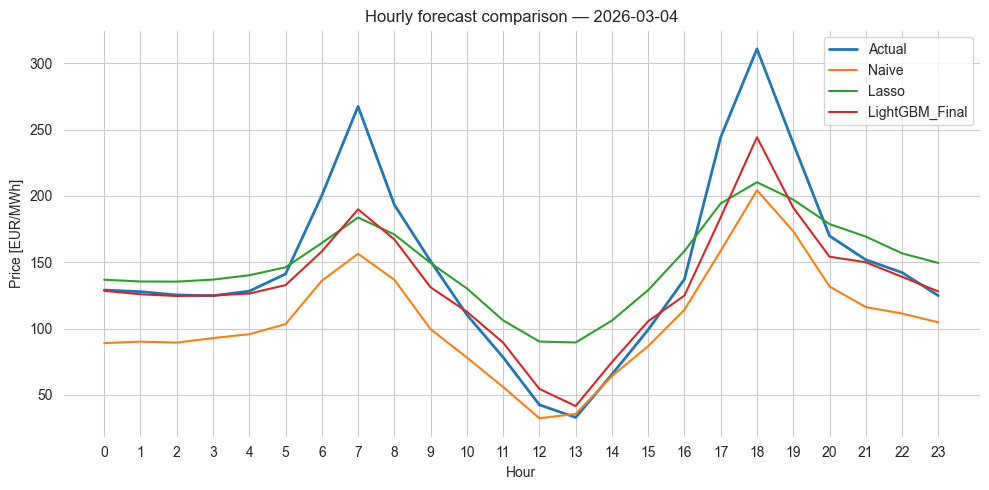

In [28]:
# =========================================================
# 27. Plot actual vs. final LightGBM for one example day
# =========================================================

# Select one test day for visual comparison
day = "2026-03-04"

# Create a mask for the selected day
day_mask = test_df["timestamp"].dt.strftime("%Y-%m-%d") == day

# Build a plotting dataframe for the selected day
plot_df = pd.DataFrame({
    "timestamp": test_df.loc[day_mask, "timestamp"].values,
    "actual": y_test.loc[day_mask].values,
    "naive": y_test_naive.loc[day_mask].values,
    "lasso": y_test_pred_lasso.loc[day_mask].values,
    "lightgbm": y_test_pred_lgbm_final.loc[day_mask].values
})

# Extract the hour from the timestamp
plot_df["hour"] = pd.to_datetime(plot_df["timestamp"]).dt.hour

# Plot hourly prices for the selected day
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.plot(plot_df["hour"], plot_df["lasso"], label="Lasso")
plt.plot(plot_df["hour"], plot_df["lightgbm"], label="LightGBM_Final")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Hourly forecast comparison — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

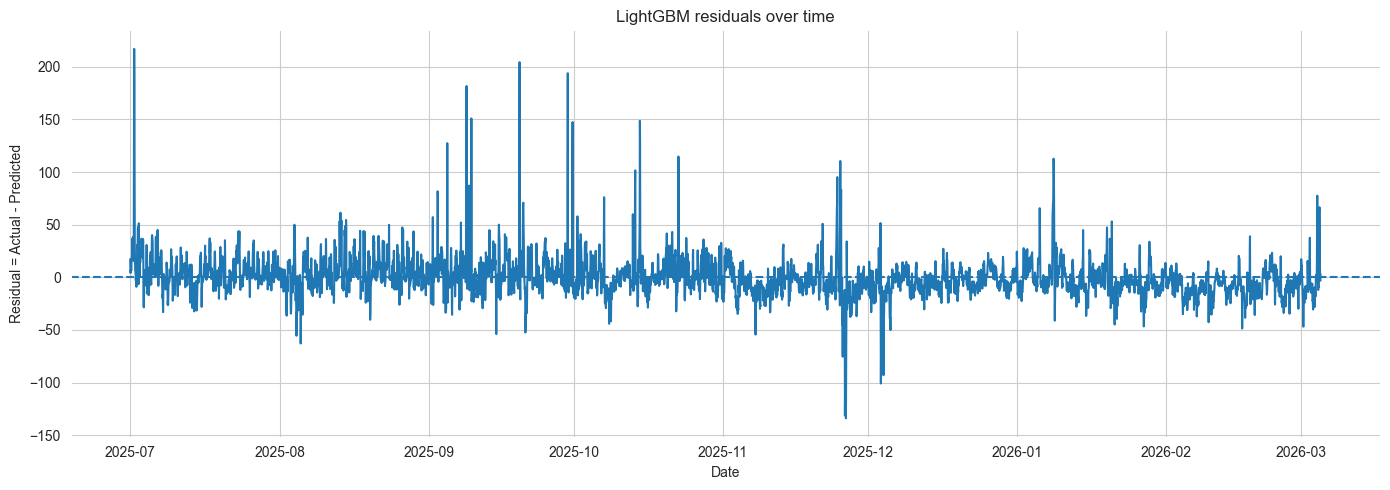

In [29]:
# =========================================================
# 28. Plot LightGBM residuals over time
# =========================================================

plt.figure(figsize=(14, 5))
plt.plot(eval_hourly["timestamp"], eval_hourly["residual"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Residual = Actual - Predicted")
plt.title("LightGBM residuals over time")
plt.grid(True)
plt.tight_layout()
plt.show()

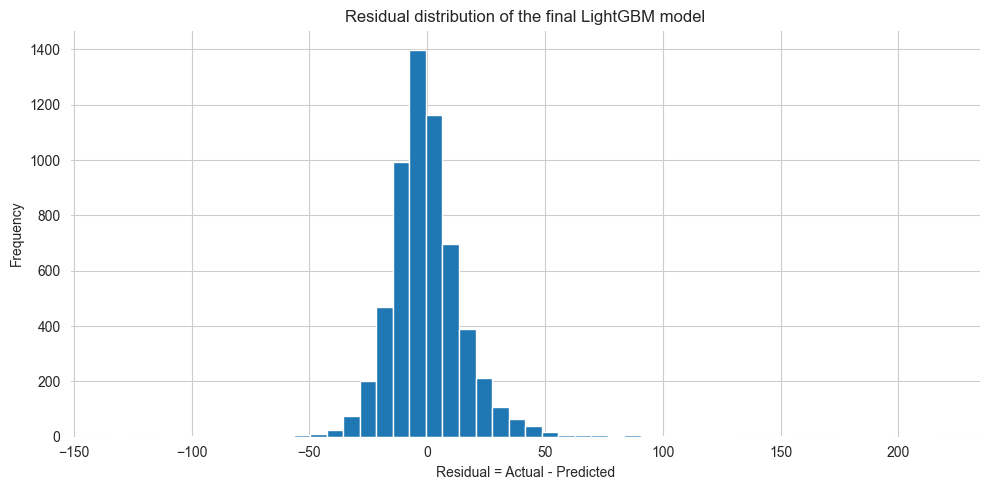

In [30]:
# =========================================================
# 29. Plot residual distribution
# =========================================================

plt.figure(figsize=(10, 5))
plt.hist(eval_hourly["residual"], bins=50)
plt.xlabel("Residual = Actual - Predicted")
plt.ylabel("Frequency")
plt.title("Residual distribution of the final LightGBM model")
plt.grid(True)
plt.tight_layout()
plt.show()

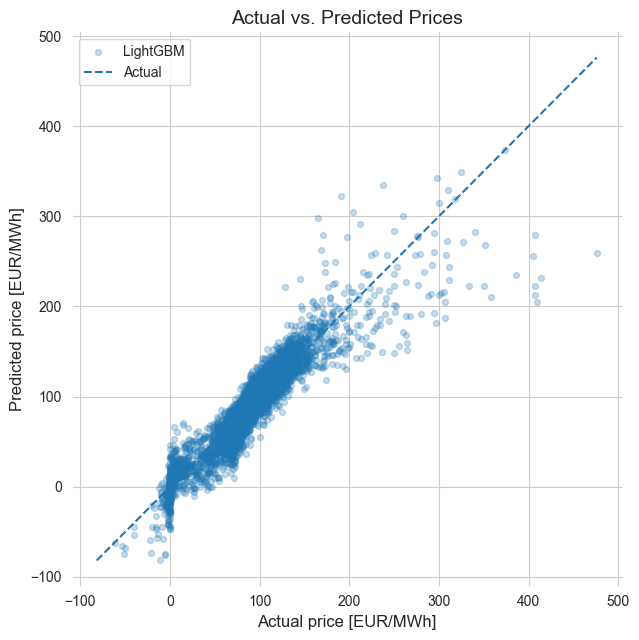

In [31]:
# =========================================================
# 30. Plot actual vs. predicted scatter
# =========================================================

plt.figure(figsize=(6.5, 6.5), facecolor="white")

plt.scatter(
    eval_hourly["actual"],
    eval_hourly["lightgbm"],
    alpha=0.25,
    s=18,
    label="LightGBM"
)

min_val = min(eval_hourly["actual"].min(), eval_hourly["lightgbm"].min())
max_val = max(eval_hourly["actual"].max(), eval_hourly["lightgbm"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1.5,
    label="Actual"
)

plt.xlabel("Actual price [EUR/MWh]", fontsize=12)
plt.ylabel("Predicted price [EUR/MWh]", fontsize=12)
plt.title("Actual vs. Predicted Prices", fontsize=14)
plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

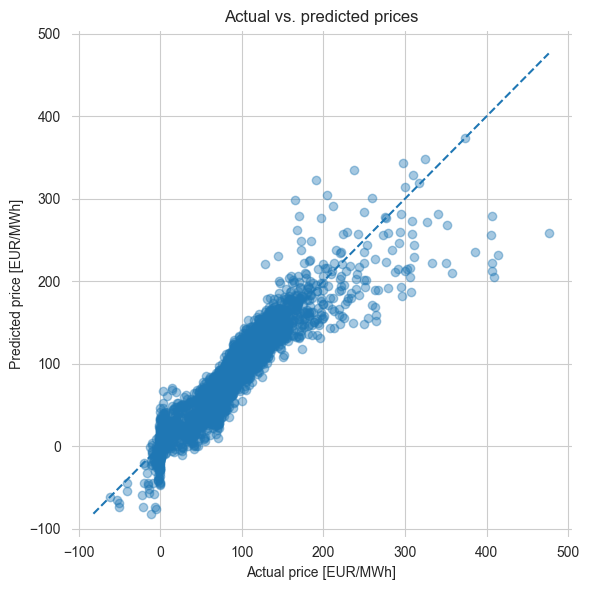

In [32]:
# =========================================================
# 30. Plot actual vs. predicted scatter
# =========================================================

plt.figure(figsize=(6, 6))
plt.scatter(eval_hourly["actual"], eval_hourly["lightgbm"], alpha=0.4)

min_val = min(eval_hourly["actual"].min(), eval_hourly["lightgbm"].min())
max_val = max(eval_hourly["actual"].max(), eval_hourly["lightgbm"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual price [EUR/MWh]")
plt.ylabel("Predicted price [EUR/MWh]")
plt.title("Actual vs. predicted prices")
plt.grid(True)
plt.tight_layout()
plt.show()

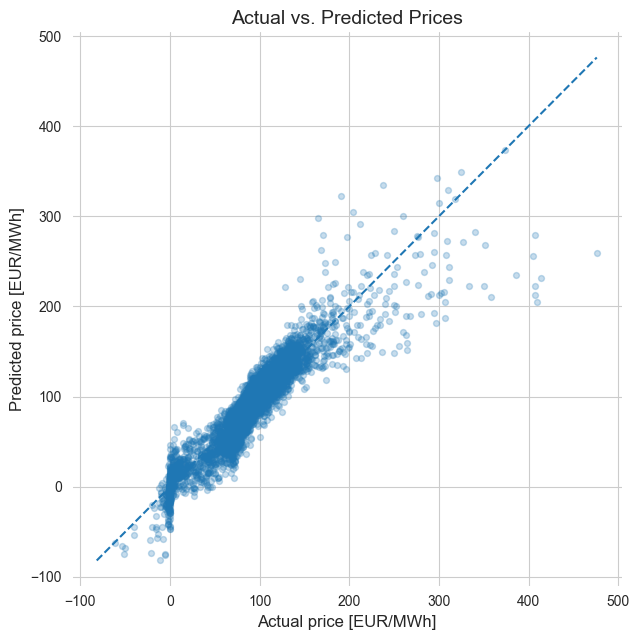

In [33]:
# =========================================================
# 30. Plot actual vs. predicted scatter
# =========================================================

plt.figure(figsize=(6.5, 6.5), facecolor="white")

plt.scatter(
    eval_hourly["actual"],
    eval_hourly["lightgbm"],
    alpha=0.25,
    s=18
)

min_val = min(eval_hourly["actual"].min(), eval_hourly["lightgbm"].min())
max_val = max(eval_hourly["actual"].max(), eval_hourly["lightgbm"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Actual price [EUR/MWh]", fontsize=12)
plt.ylabel("Predicted price [EUR/MWh]", fontsize=12)
plt.title("Actual vs. Predicted Prices", fontsize=14)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

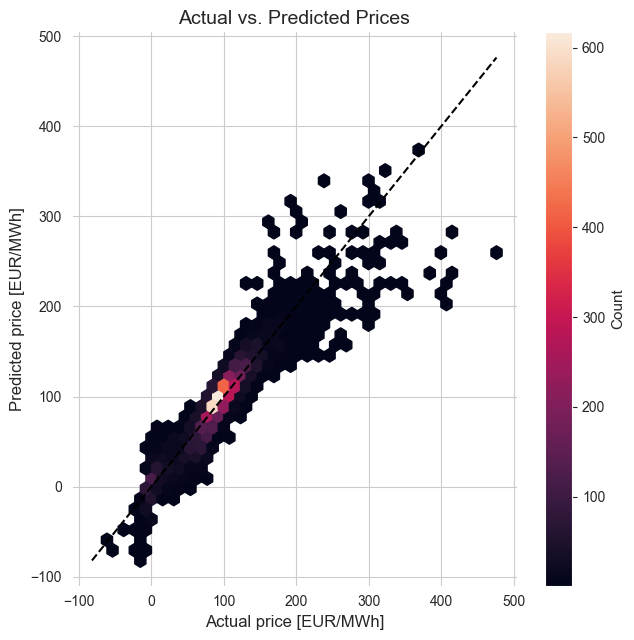

In [34]:
# =========================================================
# 30. Plot actual vs. predicted hexbin
# =========================================================

plt.figure(figsize=(6.5, 6.5), facecolor="white")

plt.hexbin(
    eval_hourly["actual"],
    eval_hourly["lightgbm"],
    gridsize=35,
    mincnt=1
)

min_val = min(eval_hourly["actual"].min(), eval_hourly["lightgbm"].min())
max_val = max(eval_hourly["actual"].max(), eval_hourly["lightgbm"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1.5,
    color="black"
)

plt.xlabel("Actual price [EUR/MWh]", fontsize=12)
plt.ylabel("Predicted price [EUR/MWh]", fontsize=12)
plt.title("Actual vs. Predicted Prices", fontsize=14)

cb = plt.colorbar()
cb.set_label("Count", fontsize=11)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

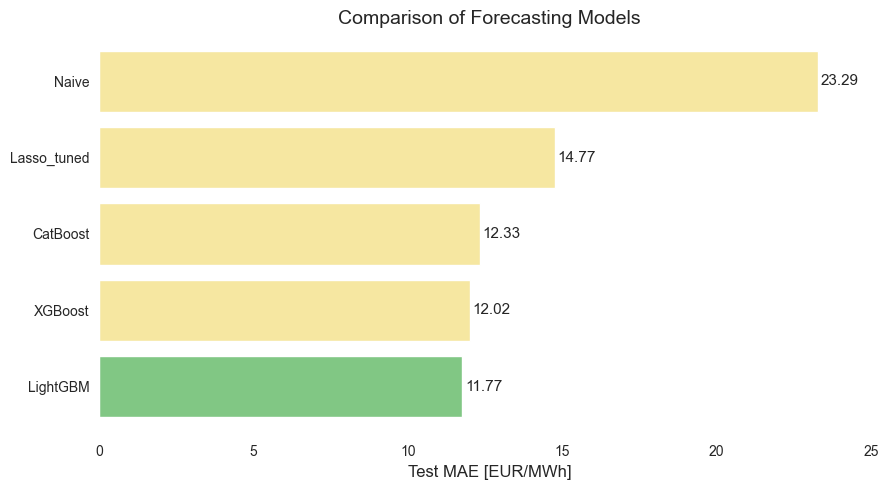

In [35]:
# =========================================================
# 31. Presentation-style bar chart of test MAE
# =========================================================

# Build comparison dataframe
mae_plot_df = pd.DataFrame({
    "model": ["Naive", "Lasso_tuned", "XGBoost", "CatBoost", "LightGBM"],
    "test_MAE": [
        naive_test_mae,
        lasso_tuned_test_mae,
        xgb_test_mae,
        catboost_test_mae,
        lightgbm_final_test_mae
    ]
}).sort_values("test_MAE", ascending=True).reset_index(drop=True)

# Define colors: highlight LightGBM, others light yellow
colors = [
    "#F6E7A1" if model != "LightGBM" else "#81C784"
    for model in mae_plot_df["model"]
]

# Plot
plt.figure(figsize=(9, 5))
bars = plt.barh(mae_plot_df["model"], mae_plot_df["test_MAE"], color=colors)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=11
    )

# Labels and styling
plt.xlabel("Test MAE [EUR/MWh]", fontsize=12)
plt.title("Comparison of Forecasting Models", fontsize=14)
plt.xlim(0, mae_plot_df["test_MAE"].max() + 2)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

In [36]:
bars = ax.barh(mae_plot_df["model"], mae_plot_df["test_MAE"], color=colors, height=0.55)

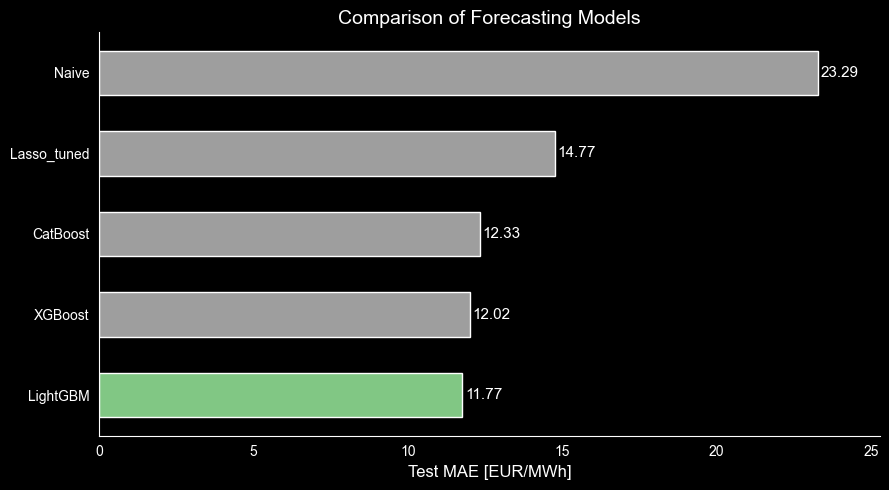

In [37]:
# =========================================================
# 31. Bar chart of test MAE
# =========================================================

# Build comparison dataframe
mae_plot_df = pd.DataFrame({
    "model": ["Naive", "Lasso_tuned", "XGBoost", "CatBoost", "LightGBM"],
    "test_MAE": [
        naive_test_mae,
        lasso_tuned_test_mae,
        xgb_test_mae,
        catboost_test_mae,
        lightgbm_final_test_mae
    ]
}).sort_values("test_MAE", ascending=True).reset_index(drop=True)

# Define colors: highlight LightGBM, others grey
colors = [
    "#9E9E9E" if model != "LightGBM" else "#81C784"
    for model in mae_plot_df["model"]
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5), facecolor="black")
ax.set_facecolor("black")

# Plot
bars = ax.barh(mae_plot_df["model"], mae_plot_df["test_MAE"], color=colors, height=0.55)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=11,
        color="white"
    )

# Labels and styling
ax.set_xlabel("Test MAE [EUR/MWh]", fontsize=12, color="white")
ax.set_title("Comparison of Forecasting Models", fontsize=14, color="white")
ax.set_xlim(0, mae_plot_df["test_MAE"].max() + 2)

# Make ticks white
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

# Turn off grid
ax.grid(False)

plt.tight_layout()
plt.show()

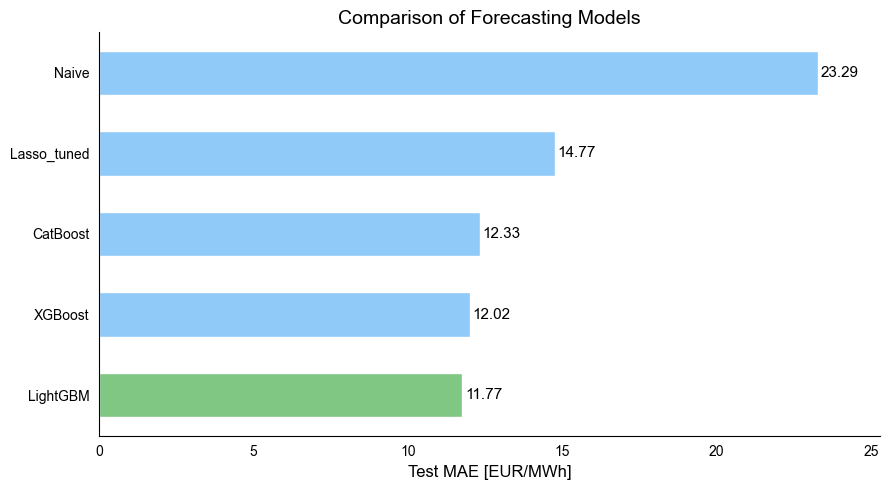

In [38]:
# =========================================================
# 31. Bar chart of test MAE
# =========================================================

# Build comparison dataframe
mae_plot_df = pd.DataFrame({
    "model": ["Naive", "Lasso_tuned", "XGBoost", "CatBoost", "LightGBM"],
    "test_MAE": [
        naive_test_mae,
        lasso_tuned_test_mae,
        xgb_test_mae,
        catboost_test_mae,
        lightgbm_final_test_mae
    ]
}).sort_values("test_MAE", ascending=True).reset_index(drop=True)

# Define colors: highlight LightGBM, others blue
colors = [
    "#90CAF9" if model != "LightGBM" else "#81C784"
    for model in mae_plot_df["model"]
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")

# Plot
bars = ax.barh(mae_plot_df["model"], mae_plot_df["test_MAE"], color=colors, height=0.55)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=11,
        color="black"
    )

# Labels and styling
ax.set_xlabel("Test MAE [EUR/MWh]", fontsize=12, color="black")
ax.set_title("Comparison of Forecasting Models", fontsize=14, color="black")
ax.set_xlim(0, mae_plot_df["test_MAE"].max() + 2)

# Make ticks black
ax.tick_params(axis="x", colors="black")
ax.tick_params(axis="y", colors="black")

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

# Turn off grid
ax.grid(False)

plt.tight_layout()
plt.show()

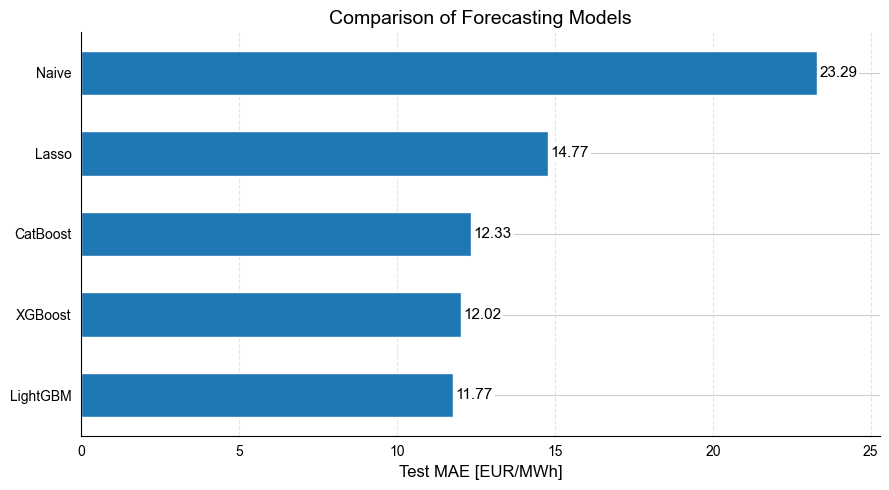

In [68]:
# =========================================================
# 31. Bar chart of test MAE
# =========================================================

# Build comparison dataframe
mae_plot_df = pd.DataFrame({
    "model": ["Naive", "Lasso", "XGBoost", "CatBoost", "LightGBM"],
    "test_MAE": [
        naive_test_mae,
        lasso_tuned_test_mae,
        xgb_test_mae,
        catboost_test_mae,
        lightgbm_final_test_mae
    ]
}).sort_values("test_MAE", ascending=True).reset_index(drop=True)

# Create figure
fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")

# Plot
bars = ax.barh(
    mae_plot_df["model"],
    mae_plot_df["test_MAE"],
    color="#1f77b4",
    height=0.55
)

# Add value labels with white background
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=11,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5)
    )

# Labels and styling
ax.set_xlabel("Test MAE [EUR/MWh]", fontsize=12, color="black")
ax.set_title("Comparison of Forecasting Models", fontsize=14, color="black")
ax.set_xlim(0, mae_plot_df["test_MAE"].max() + 2)

# Ticks
ax.tick_params(axis="x", colors="black")
ax.tick_params(axis="y", colors="black")

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

# Grid on
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

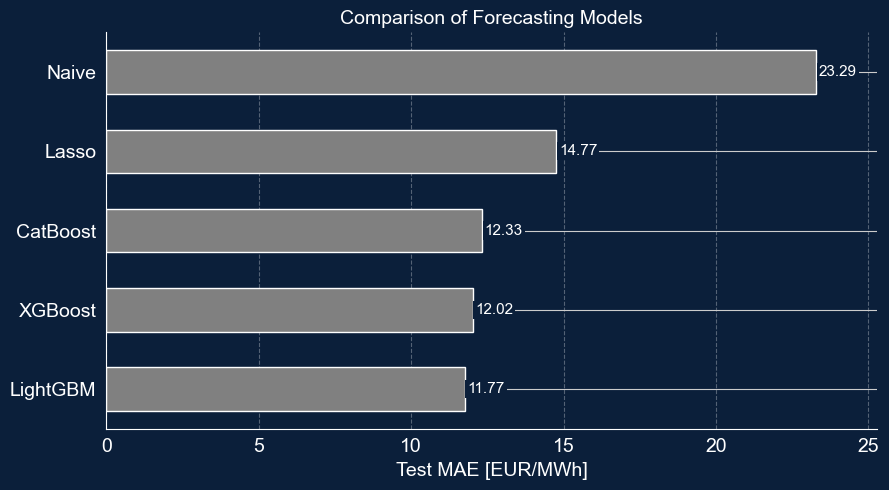

In [71]:
# =========================================================
# 31. Bar chart of test MAE
# =========================================================

# Build comparison dataframe
mae_plot_df = pd.DataFrame({
    "model": ["Naive", "Lasso", "XGBoost", "CatBoost", "LightGBM"],
    "test_MAE": [
        naive_test_mae,
        lasso_tuned_test_mae,
        xgb_test_mae,
        catboost_test_mae,
        lightgbm_final_test_mae
    ]
}).sort_values("test_MAE", ascending=True).reset_index(drop=True)

# Create figure
fig, ax = plt.subplots(figsize=(9, 5), facecolor="#0b1f3a")
ax.set_facecolor("#0b1f3a")

# Plot
bars = ax.barh(
    mae_plot_df["model"],
    mae_plot_df["test_MAE"],
    color="grey",
    height=0.55
)

# Add value labels with dark-blue background
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=11,
        color="white",
        bbox=dict(facecolor="#0b1f3a", edgecolor="none", pad=1.5)
    )

# Labels and styling
ax.set_xlabel("Test MAE [EUR/MWh]", fontsize=14, color="white")
ax.set_title("Comparison of Forecasting Models", fontsize=14, color="white")
ax.set_xlim(0, mae_plot_df["test_MAE"].max() + 2)

# Ticks
ax.tick_params(axis="x", colors="white", labelsize=14)
ax.tick_params(axis="y", colors="white", labelsize=14)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

# Grid on
ax.grid(True, axis="x", linestyle="--", alpha=0.3, color="white")

plt.tight_layout()
plt.show()

---------------------------------------------------------------------------------------------
# SHAP

--------------------------------------------------------------------------------------------

In [40]:
# =========================================================
# 25.1 Import SHAP
# =========================================================

import shap

c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
# =========================================================
# 32. SHAP analysis for the final LightGBM model
# =========================================================

# Create a TreeExplainer for the final LightGBM model
explainer = shap.TreeExplainer(lightgbm_final_model)

# Compute SHAP values on the test set
shap_values = explainer.shap_values(X_test)

# Quick shape checks
print("X_test shape:", X_test.shape)
print("SHAP values shape:", np.array(shap_values).shape)

X_test shape: (5928, 36)
SHAP values shape: (5928, 36)


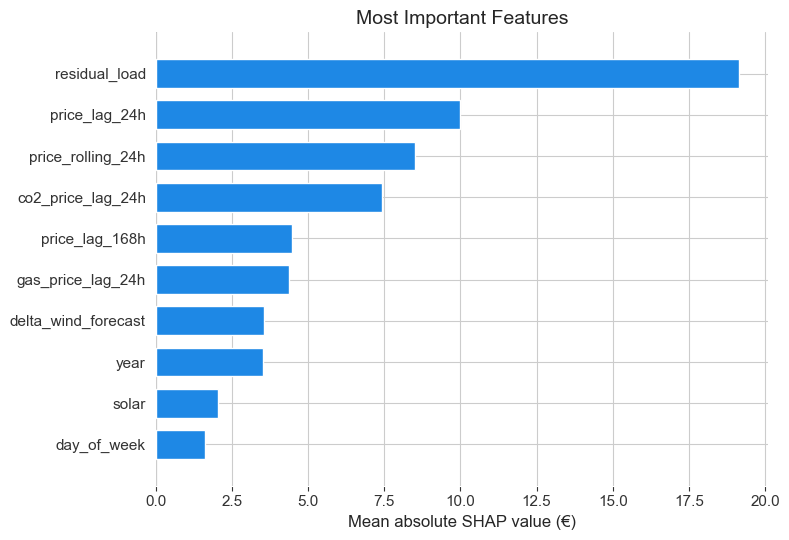

In [42]:
# =========================================================
# 33. Global SHAP importance bar plot
# =========================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    color="#1E88E5",
    max_display=10,
    show=False
)

ax = plt.gca()
ax.set_xlabel("Mean absolute SHAP value (€)", fontsize=12)
ax.set_title("Most Important Features", fontsize=14)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/shap_importance_lgbm.png", dpi=150)
plt.show()

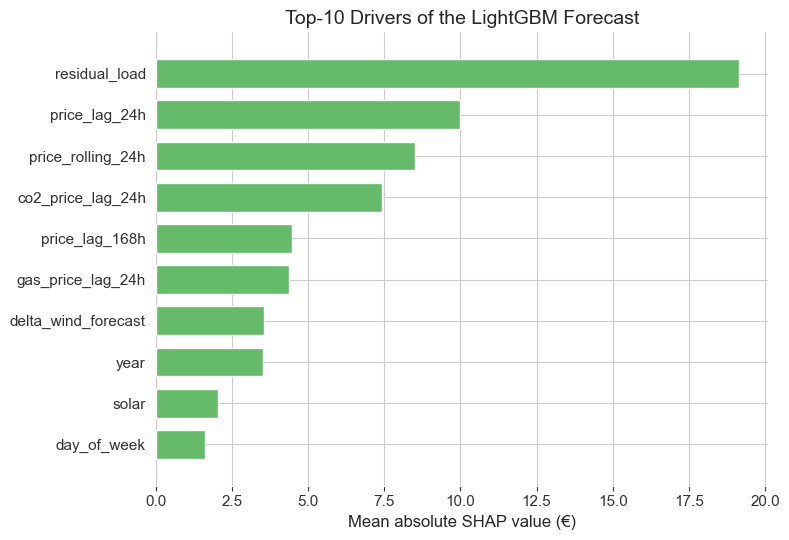

In [43]:
# =========================================================
# 33. Global SHAP importance bar plot
# =========================================================

plt.figure(figsize=(9, 5), facecolor="white")

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    color="#66BB6A",
    max_display=10,
    show=False
)

ax = plt.gca()
ax.set_xlabel("Mean absolute SHAP value (€)", fontsize=12)
ax.set_title("Top-10 Drivers of the LightGBM Forecast", fontsize=14)
ax.tick_params(axis="both", labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/shap_importance_lgbm.png", dpi=150)
plt.show()

In [44]:
# =========================================================
# 34. SHAP importance table
# =========================================================

# Convert SHAP values to dataframe
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

# Compute mean absolute SHAP importance
mean_importance = shap_df.abs().mean().sort_values(ascending=False)

# Show table
display(mean_importance.to_frame(name="mean_abs_shap"))

,mean_abs_shap
residual_load,19.152150
price_lag_24h,9.974423
price_rolling_24h,8.498786
co2_price_lag_24h,7.416374
price_lag_168h,4.462395
gas_price_lag_24h,4.380161
delta_wind_forecast,3.543396
year,3.521382
solar,2.055182
day_of_week,1.606151


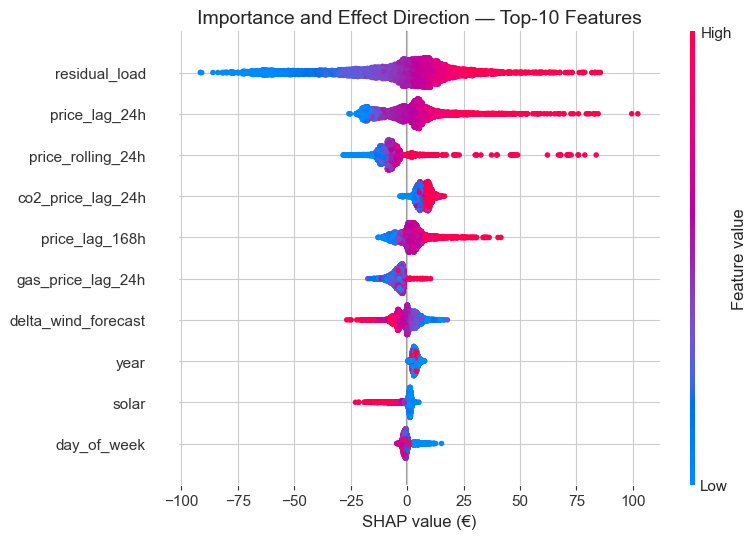

In [45]:
# =========================================================
# 35. SHAP beeswarm plot
# =========================================================

shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    show=False
)

ax = plt.gca()
ax.set_xlabel("SHAP value (€)", fontsize=12)
ax.set_title("Importance and Effect Direction — Top-10 Features", fontsize=14)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/shap_beeswarm_lgbm.png", dpi=150)
plt.show()

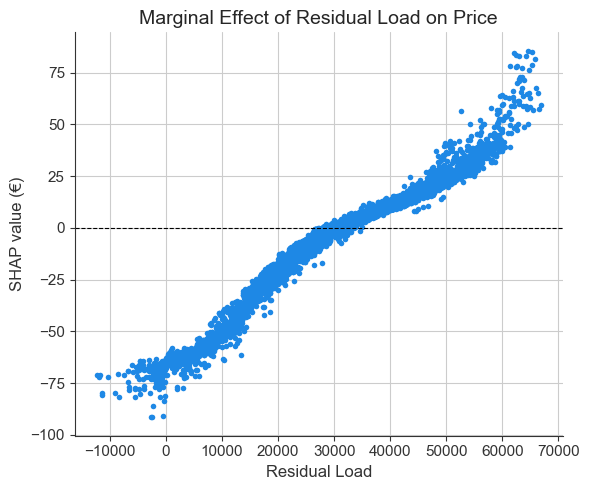

In [46]:
# =========================================================
# 36. Dependence plot for residual_load
# =========================================================

shap.dependence_plot(
    "residual_load",
    shap_values,
    X_test,
    interaction_index=None,
    show=False
)

ax = plt.gca()
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Residual Load", fontsize=12)
ax.set_ylabel("SHAP value (€)", fontsize=12)
ax.set_title("Marginal Effect of Residual Load on Price", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

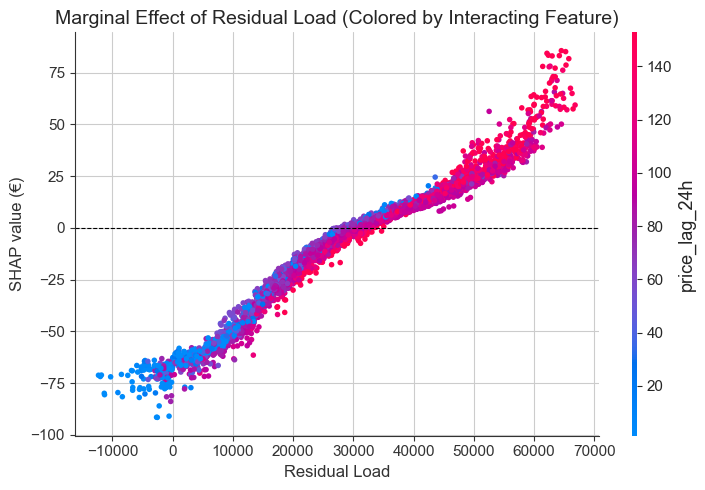

In [47]:
# =========================================================
# 37. Dependence plot for residual_load with interaction
# =========================================================

shap.dependence_plot(
    "residual_load",
    shap_values,
    X_test,
    show=False
)

ax = plt.gca()
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Residual Load", fontsize=12)
ax.set_ylabel("SHAP value (€)", fontsize=12)
ax.set_title("Marginal Effect of Residual Load (Colored by Interacting Feature)", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

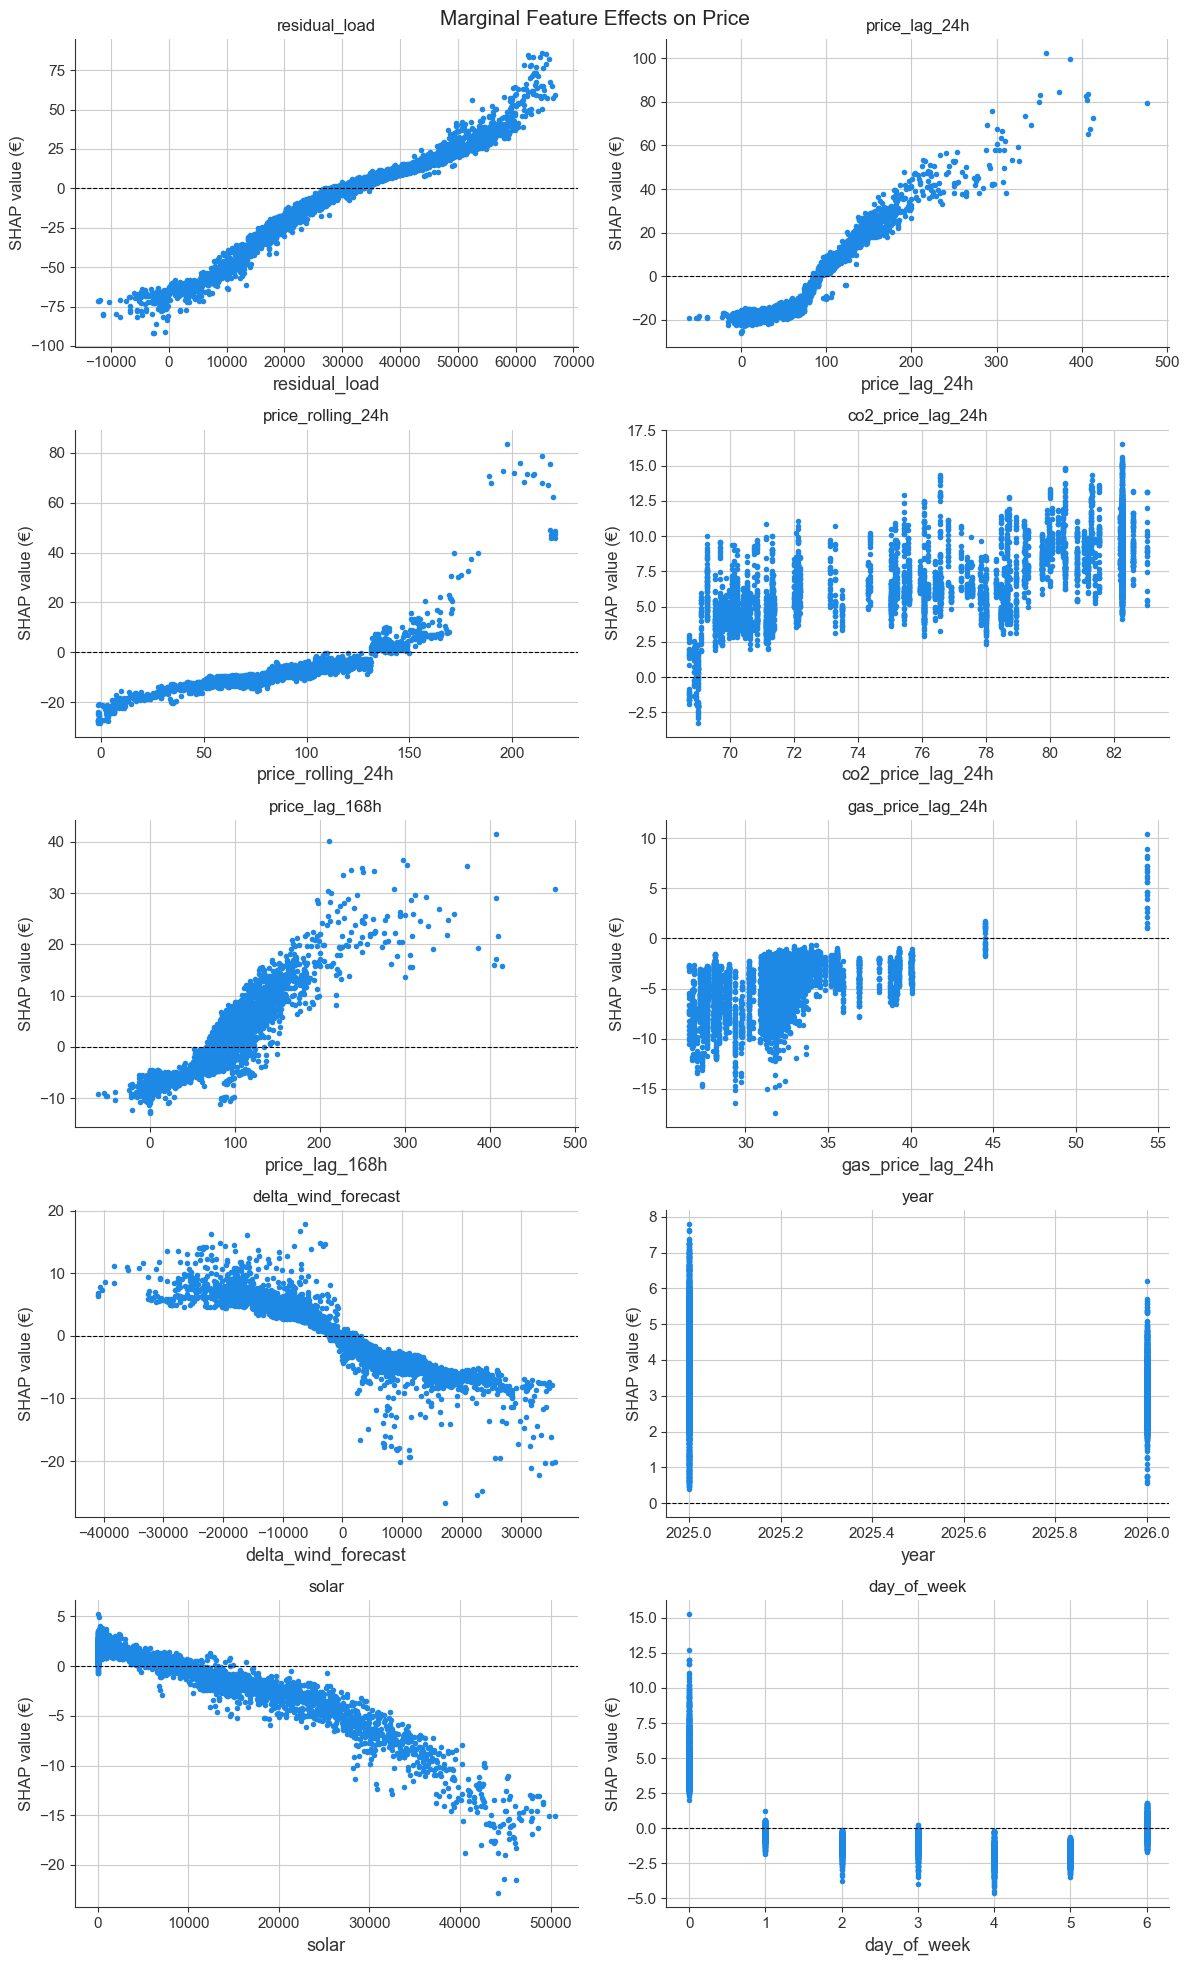

In [48]:
# =========================================================
# 38. Dependence plots for the top-10 features
# =========================================================

# Select top-10 features by mean absolute SHAP value
top10 = shap_df.abs().mean().sort_values(ascending=False).head(10)
features = top10.index.tolist()

# Create subplot grid
fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()

# Plot dependence plots
for i, feature in enumerate(features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        interaction_index=None,
        show=False,
        ax=axes[i]
    )
    axes[i].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_ylabel("SHAP value (€)", fontsize=12)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

plt.suptitle("Marginal Feature Effects on Price", fontsize=15)
plt.tight_layout()
plt.show()

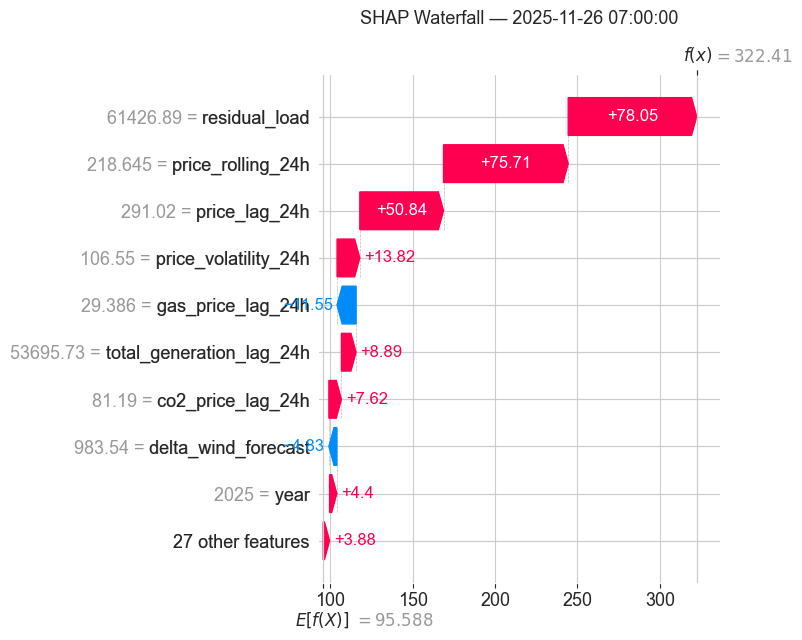

In [49]:
# =========================================================
# 39. Waterfall plot for one specific prediction
# =========================================================

# Choose one timestamp from the test set
target_timestamp = "2025-11-26 07:00:00"

# Find the index of that timestamp in test_df
idx = test_df[test_df["timestamp"] == target_timestamp].index[0]

# Convert to row position inside X_test
row_position = X_test.index.get_loc(idx)

# Compute SHAP explanation object
shap_explanation = explainer(X_test)

# Plot waterfall
plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation[row_position], max_display=10, show=False)
plt.title(f"SHAP Waterfall — {target_timestamp}", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------

# Battery Operation Optimization

---------------------------------------------------------------------------------------------

In [50]:
# =========================================================
# Battery Step 1. Define battery parameters
# =========================================================

# Battery energy capacity [MWh]
capacity_mwh = 40.0

# Maximum charging power [MW]
max_charge_mw = 20.0

# Maximum discharging power [MW]
max_discharge_mw = 20.0

# Charging efficiency [-]
eta_charge = 0.95

# Discharging efficiency [-]
eta_discharge = 0.95

# Minimum allowed state of charge [MWh]
soc_min_mwh = 0.10 * capacity_mwh

# Maximum allowed state of charge [MWh]
soc_max_mwh = 0.90 * capacity_mwh

# Initial SOC at the start of the day [MWh]
soc_init_mwh = 0.50 * capacity_mwh

# Required final SOC at the end of the day [MWh]
soc_final_mwh = soc_init_mwh

# Length of one time step [hours]
dt = 1.0

# Quick check
print("Battery parameters:")
print(f"capacity_mwh      = {capacity_mwh}")
print(f"max_charge_mw     = {max_charge_mw}")
print(f"max_discharge_mw  = {max_discharge_mw}")
print(f"eta_charge        = {eta_charge}")
print(f"eta_discharge     = {eta_discharge}")
print(f"soc_min_mwh       = {soc_min_mwh}")
print(f"soc_max_mwh       = {soc_max_mwh}")
print(f"soc_init_mwh      = {soc_init_mwh}")
print(f"soc_final_mwh     = {soc_final_mwh}")
print(f"dt                = {dt}")

Battery parameters:
capacity_mwh      = 40.0
max_charge_mw     = 20.0
max_discharge_mw  = 20.0
eta_charge        = 0.95
eta_discharge     = 0.95
soc_min_mwh       = 4.0
soc_max_mwh       = 36.0
soc_init_mwh      = 20.0
soc_final_mwh     = 20.0
dt                = 1.0


In [51]:
# =========================================================
# Battery Step 2. Build hourly battery input dataframe
# =========================================================

# Build an hourly dataframe for the battery simulation
bess_input_hourly = pd.DataFrame({
    "timestamp": test_df["timestamp"].values,
    "actual": y_test.values,
    "forecast": y_test_pred_lgbm_final.values
})

# Create daily date and hour columns
bess_input_hourly["date"] = pd.to_datetime(bess_input_hourly["timestamp"]).dt.floor("D")
bess_input_hourly["hour"] = pd.to_datetime(bess_input_hourly["timestamp"]).dt.hour

# Quick checks
print("Shape:", bess_input_hourly.shape)
print("Number of test days:", bess_input_hourly["date"].nunique())
display(bess_input_hourly.head())

Shape: (5928, 5)
Number of test days: 247


,timestamp,actual,forecast,date,hour
0,2025-07-01 00:00:00,111.28,94.115628,2025-07-01,0
1,2025-07-01 01:00:00,95.29,87.140943,2025-07-01,1
2,2025-07-01 02:00:00,89.10,84.942537,2025-07-01,2
3,2025-07-01 03:00:00,88.08,80.778620,2025-07-01,3
4,2025-07-01 04:00:00,90.01,83.265411,2025-07-01,4


In [52]:
# =========================================================
# Battery Step 3. Extract one example day
# =========================================================

# Choose one test day
example_day = "2026-03-04"

# Filter the hourly battery input for that day
day_df = bess_input_hourly[bess_input_hourly["date"] == pd.to_datetime(example_day)].copy()

# Keep relevant columns and sort by time
day_df = day_df[["timestamp", "hour", "actual", "forecast"]].sort_values("timestamp").reset_index(drop=True)

# Quick check
print("Selected day:", example_day)
print("Number of hourly rows:", len(day_df))
display(day_df)

Selected day: 2026-03-04
Number of hourly rows: 24


,timestamp,hour,actual,forecast
0,2026-03-04 00:00:00,0,129.01,128.427386
1,2026-03-04 01:00:00,1,127.82,125.846638
2,2026-03-04 02:00:00,2,125.32,124.556412
3,2026-03-04 03:00:00,3,124.74,124.957093
4,2026-03-04 04:00:00,4,128.20,126.395506
5,2026-03-04 05:00:00,5,141.16,132.765205
6,2026-03-04 06:00:00,6,200.30,158.155809
7,2026-03-04 07:00:00,7,267.49,189.895576
8,2026-03-04 08:00:00,8,193.35,167.208147
9,2026-03-04 09:00:00,9,150.76,131.077524


In [53]:
# =========================================================
# Battery Step 4. Create one-day price vectors
# =========================================================

# Actual price vector for the selected day [EUR/MWh]
prices_actual = day_df["actual"].to_numpy()

# Forecast price vector for the selected day [EUR/MWh]
prices_forecast = day_df["forecast"].to_numpy()

# Quick checks
print("Length of actual price vector:", len(prices_actual))
print("Length of forecast price vector:", len(prices_forecast))

print("\nActual prices:")
print(prices_actual)

print("\nForecast prices:")
print(prices_forecast)

Length of actual price vector: 24
Length of forecast price vector: 24

Actual prices:
[129.01 127.82 125.32 124.74 128.2  141.16 200.3  267.49 193.35 150.76
 110.42  78.3   42.5   32.98  65.41  99.11 137.21 244.27 310.86 239.63
 169.86 151.88 142.24 124.81]

Forecast prices:
[128.42738571 125.84663788 124.55641173 124.9570934  126.39550566
 132.7652053  158.15580869 189.89557642 167.20814668 131.07752368
 112.69589523  89.39845033  54.49152     41.57273785  74.66437952
 105.54312968 124.91330512 183.87703124 244.26196629 191.18707418
 154.18008868 149.97176903 139.01436577 127.98533998]


In [54]:
# =========================================================
# Battery Step 5. Import solver and define daily optimizer
# =========================================================
# This defines the linear-program battery optimizer for one 24-hour price curve.
from scipy.optimize import linprog

def optimize_bess_day(prices, timestamps, hours):
    """
    Solve the daily battery arbitrage problem for one 24-hour price vector.

    Parameters
    ----------
    prices : array-like
        24 hourly electricity prices [EUR/MWh]
    timestamps : array-like
        24 timestamps of the day
    hours : array-like
        24 hour values (0 to 23)

    Returns
    -------
    day_result : pd.DataFrame
        Hourly battery schedule and cashflows
    daily_summary : dict
        Daily summary values
    """

    prices = np.asarray(prices)
    n = len(prices)
    n_vars = 3 * n

    # Variable block positions
    charge_start = 0
    discharge_start = n
    soc_start = 2 * n

    # Objective vector
    c = np.concatenate([
        prices,           # charging = cost
        -prices,          # discharging = revenue
        np.zeros(n)       # SOC has no direct profit term
    ])

    # Bounds
    charge_bounds = [(0, max_charge_mw * dt) for _ in range(n)]
    discharge_bounds = [(0, max_discharge_mw * dt) for _ in range(n)]
    soc_bounds = [(soc_min_mwh, soc_max_mwh) for _ in range(n)]
    bounds = charge_bounds + discharge_bounds + soc_bounds

    # Equality constraints
    A_eq = []
    b_eq = []

    # Hour 0 SOC equation
    row = np.zeros(n_vars)
    row[charge_start + 0] = -eta_charge
    row[discharge_start + 0] = 1 / eta_discharge
    row[soc_start + 0] = 1
    A_eq.append(row)
    b_eq.append(soc_init_mwh)

    # Hours 1 to n-1
    for t in range(1, n):
        row = np.zeros(n_vars)
        row[charge_start + t] = -eta_charge
        row[discharge_start + t] = 1 / eta_discharge
        row[soc_start + t] = 1
        row[soc_start + (t - 1)] = -1
        A_eq.append(row)
        b_eq.append(0)

    # Final SOC
    row = np.zeros(n_vars)
    row[soc_start + (n - 1)] = 1
    A_eq.append(row)
    b_eq.append(soc_final_mwh)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Solve
    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")

    # Extract solution
    x_opt = result.x
    charge_opt = x_opt[charge_start:discharge_start]
    discharge_opt = x_opt[discharge_start:soc_start]
    soc_opt = x_opt[soc_start:]

    # Build hourly result table
    day_result = pd.DataFrame({
        "timestamp": timestamps,
        "hour": hours,
        "price": prices,
        "charge_mwh": charge_opt,
        "discharge_mwh": discharge_opt,
        "soc_mwh": soc_opt
    })

    # Hourly cashflow
    day_result["cashflow_eur"] = (
        day_result["price"] * day_result["discharge_mwh"]
        - day_result["price"] * day_result["charge_mwh"]
    )

    # Daily summary
    daily_summary = {
        "date": pd.to_datetime(day_result["timestamp"]).dt.floor("D").iloc[0],
        "daily_profit_eur": day_result["cashflow_eur"].sum(),
        "total_charge_mwh": day_result["charge_mwh"].sum(),
        "total_discharge_mwh": day_result["discharge_mwh"].sum()
    }

    return day_result, daily_summary

In [55]:
# =========================================================
# Battery Step 6. Perfect-foresight optimization for one day 
#(gives the best possible one-day battery schedule when the optimizer knows the true prices.)
# =========================================================

# Optimize using actual prices
bess_day_perfect, bess_day_summary_perfect = optimize_bess_day(
    prices=prices_actual,
    timestamps=day_df["timestamp"].to_numpy(),
    hours=day_df["hour"].to_numpy()
)

# Show hourly result table
display(bess_day_perfect.round(4))

# Show daily summary
print("Perfect-foresight daily summary:")
for key, value in bess_day_summary_perfect.items():
    if key == "date":
        print(f"{key}: {value}")
    else:
        print(f"{key}: {value:.2f}")

C:\Users\atefe\AppData\Local\Temp\ipykernel_2792\2811580481.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(bess_day_perfect.round(4))


,timestamp,hour,price,charge_mwh,discharge_mwh,soc_mwh,cashflow_eur
0,2026-03-04 00:00:00,0,129.01,0.0000,0.0,20.0000,0.0000
1,2026-03-04 01:00:00,1,127.82,0.0000,0.0,20.0000,0.0000
2,2026-03-04 02:00:00,2,125.32,0.0000,0.0,20.0000,0.0000
3,2026-03-04 03:00:00,3,124.74,16.8421,0.0,36.0000,-2100.8842
4,2026-03-04 04:00:00,4,128.20,0.0000,0.0,36.0000,0.0000
5,2026-03-04 05:00:00,5,141.16,0.0000,-0.0,36.0000,-0.0000
6,2026-03-04 06:00:00,6,200.30,0.0000,10.4,25.0526,2083.1200
7,2026-03-04 07:00:00,7,267.49,0.0000,20.0,4.0000,5349.8000
8,2026-03-04 08:00:00,8,193.35,0.0000,-0.0,4.0000,-0.0000
9,2026-03-04 09:00:00,9,150.76,-0.0000,0.0,4.0000,0.0000


Perfect-foresight daily summary:
date: 2026-03-04 00:00:00
daily_profit_eur: 10746.40
total_charge_mwh: 67.37
total_discharge_mwh: 60.80


In [56]:
# =========================================================
# Battery Step 7. Define forecast-based daily optimizer
# =========================================================

def optimize_bess_day_with_settlement(opt_prices, settle_prices, timestamps, hours):
    """
    Optimize the battery schedule using one price vector,
    then calculate realized cashflow using another price vector.
    """

    opt_prices = np.asarray(opt_prices)
    settle_prices = np.asarray(settle_prices)

    n = len(opt_prices)
    n_vars = 3 * n

    # Variable block positions
    charge_start = 0
    discharge_start = n
    soc_start = 2 * n

    # Objective vector: optimize on forecast prices
    c = np.concatenate([
        opt_prices,
        -opt_prices,
        np.zeros(n)
    ])

    # Bounds
    charge_bounds = [(0, max_charge_mw * dt) for _ in range(n)]
    discharge_bounds = [(0, max_discharge_mw * dt) for _ in range(n)]
    soc_bounds = [(soc_min_mwh, soc_max_mwh) for _ in range(n)]
    bounds = charge_bounds + discharge_bounds + soc_bounds

    # Equality constraints
    A_eq = []
    b_eq = []

    # Hour 0
    row = np.zeros(n_vars)
    row[charge_start + 0] = -eta_charge
    row[discharge_start + 0] = 1 / eta_discharge
    row[soc_start + 0] = 1
    A_eq.append(row)
    b_eq.append(soc_init_mwh)

    # Hours 1 to n-1
    for t in range(1, n):
        row = np.zeros(n_vars)
        row[charge_start + t] = -eta_charge
        row[discharge_start + t] = 1 / eta_discharge
        row[soc_start + t] = 1
        row[soc_start + (t - 1)] = -1
        A_eq.append(row)
        b_eq.append(0)

    # Final SOC
    row = np.zeros(n_vars)
    row[soc_start + (n - 1)] = 1
    A_eq.append(row)
    b_eq.append(soc_final_mwh)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Solve
    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")

    # Extract solution
    x_opt = result.x
    charge_opt = x_opt[charge_start:discharge_start]
    discharge_opt = x_opt[discharge_start:soc_start]
    soc_opt = x_opt[soc_start:]

    # Build result table
    day_result = pd.DataFrame({
        "timestamp": timestamps,
        "hour": hours,
        "price_opt": opt_prices,
        "price_settle": settle_prices,
        "charge_mwh": charge_opt,
        "discharge_mwh": discharge_opt,
        "soc_mwh": soc_opt
    })

    # Realized cashflow uses actual settlement prices
    day_result["cashflow_eur"] = (
        day_result["price_settle"] * day_result["discharge_mwh"]
        - day_result["price_settle"] * day_result["charge_mwh"]
    )

    # Daily summary
    daily_summary = {
        "date": pd.to_datetime(day_result["timestamp"]).dt.floor("D").iloc[0],
        "daily_profit_eur": day_result["cashflow_eur"].sum(),
        "total_charge_mwh": day_result["charge_mwh"].sum(),
        "total_discharge_mwh": day_result["discharge_mwh"].sum()
    }

    return day_result, daily_summary

In [57]:
# =========================================================
# Battery Step 8. Forecast-based optimization for one day
# =========================================================

# Optimize using forecast prices, settle using actual prices
bess_day_forecast, bess_day_summary_forecast = optimize_bess_day_with_settlement(
    opt_prices=prices_forecast,
    settle_prices=prices_actual,
    timestamps=day_df["timestamp"].to_numpy(),
    hours=day_df["hour"].to_numpy()
)

# Show hourly result table
display(bess_day_forecast.round(4))

# Show daily summary
print("Forecast-based daily summary:")
for key, value in bess_day_summary_forecast.items():
    if key == "date":
        print(f"{key}: {value}")
    else:
        print(f"{key}: {value:.2f}")

C:\Users\atefe\AppData\Local\Temp\ipykernel_2792\2854207504.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(bess_day_forecast.round(4))


,timestamp,hour,price_opt,price_settle,charge_mwh,discharge_mwh,soc_mwh,cashflow_eur
0,2026-03-04 00:00:00,0,128.4274,129.01,0.0000,0.0,20.0000,0.0000
1,2026-03-04 01:00:00,1,125.8466,127.82,0.0000,0.0,20.0000,0.0000
2,2026-03-04 02:00:00,2,124.5564,125.32,16.8421,0.0,36.0000,-2110.6526
3,2026-03-04 03:00:00,3,124.9571,124.74,-0.0000,0.0,36.0000,0.0000
4,2026-03-04 04:00:00,4,126.3955,128.20,-0.0000,0.0,36.0000,0.0000
5,2026-03-04 05:00:00,5,132.7652,141.16,0.0000,0.0,36.0000,0.0000
6,2026-03-04 06:00:00,6,158.1558,200.30,0.0000,-0.0,36.0000,-0.0000
7,2026-03-04 07:00:00,7,189.8956,267.49,0.0000,20.0,14.9474,5349.8000
8,2026-03-04 08:00:00,8,167.2081,193.35,0.0000,10.4,4.0000,2010.8400
9,2026-03-04 09:00:00,9,131.0775,150.76,-0.0000,0.0,4.0000,0.0000


Forecast-based daily summary:
date: 2026-03-04 00:00:00
daily_profit_eur: 10616.10
total_charge_mwh: 67.37
total_discharge_mwh: 60.80


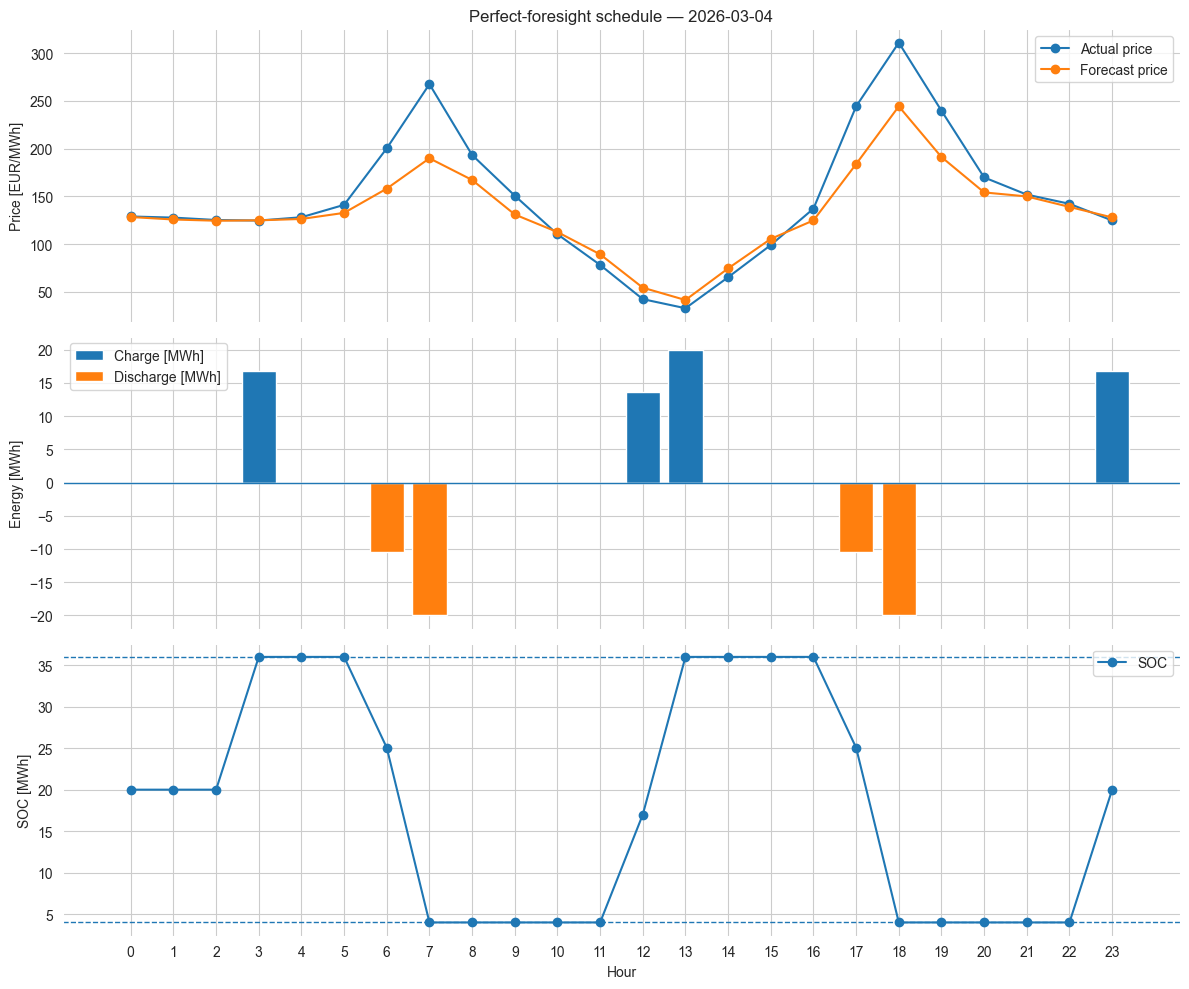

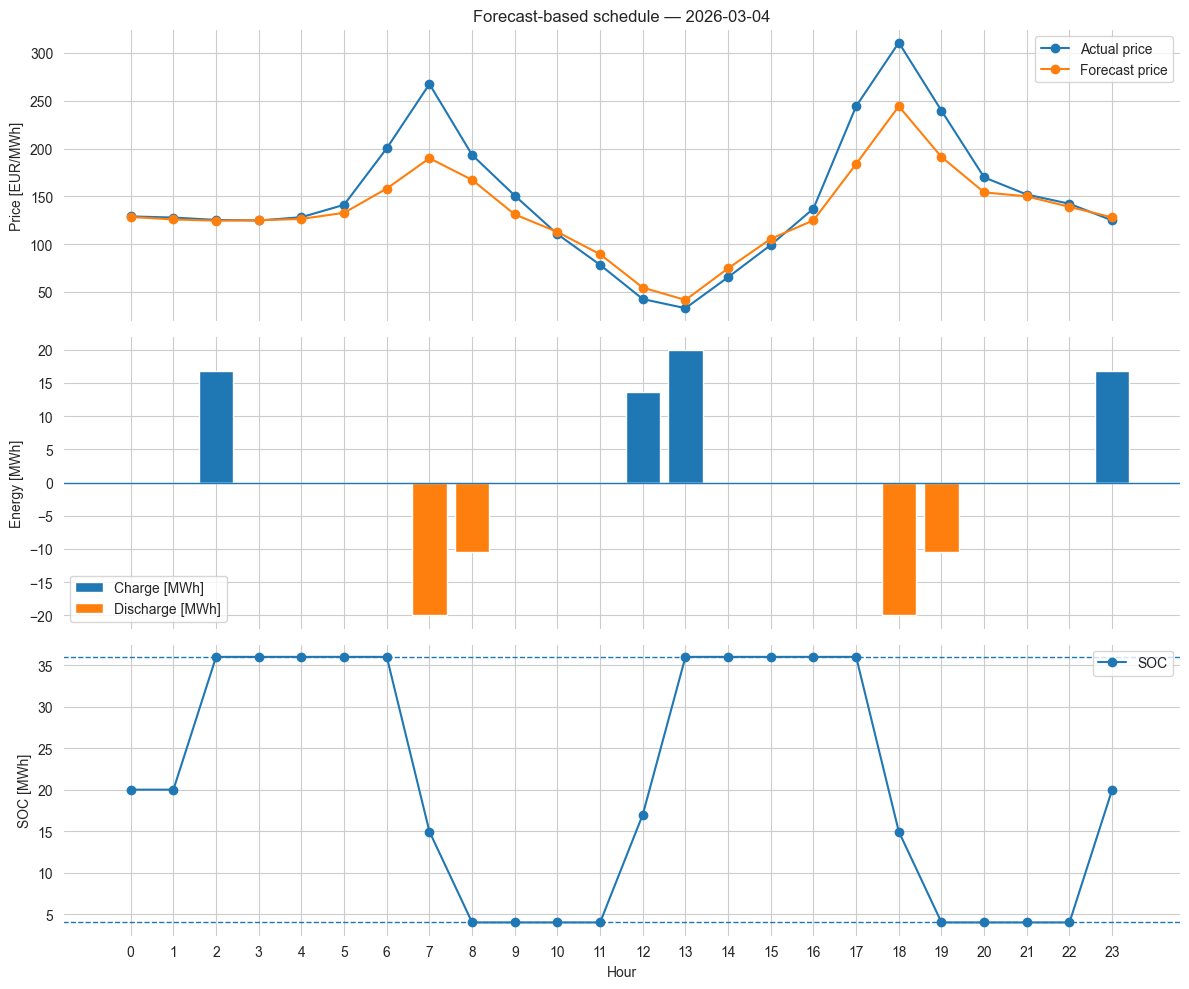

Comparison day: 2026-03-04
Perfect-foresight profit [EUR]: 10746.40
Forecast-based profit [EUR]:   10616.10
Profit gap [EUR]:              130.30


In [58]:
# =========================================================
# Battery Step 9. Compare one-day schedules
# =========================================================

# Daily profits
profit_perfect = bess_day_perfect["cashflow_eur"].sum()
profit_forecast = bess_day_forecast["cashflow_eur"].sum()

# ---------------------------------------------------------
# Plot perfect-foresight schedule
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1) Price curves
axes[0].plot(day_df["hour"], day_df["actual"], marker="o", label="Actual price")
axes[0].plot(day_df["hour"], day_df["forecast"], marker="o", label="Forecast price")
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title(f"Perfect-foresight schedule — {example_day}")
axes[0].grid(True)
axes[0].legend()

# 2) Charge/discharge
axes[1].bar(bess_day_perfect["hour"], bess_day_perfect["charge_mwh"], label="Charge [MWh]")
axes[1].bar(bess_day_perfect["hour"], -bess_day_perfect["discharge_mwh"], label="Discharge [MWh]")
axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Energy [MWh]")
axes[1].grid(True)
axes[1].legend()

# 3) SOC
axes[2].plot(bess_day_perfect["hour"], bess_day_perfect["soc_mwh"], marker="o", label="SOC")
axes[2].axhline(soc_min_mwh, linestyle="--", linewidth=1)
axes[2].axhline(soc_max_mwh, linestyle="--", linewidth=1)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("SOC [MWh]")
axes[2].set_xticks(range(24))
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot forecast-based schedule
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1) Price curves
axes[0].plot(day_df["hour"], day_df["actual"], marker="o", label="Actual price")
axes[0].plot(day_df["hour"], day_df["forecast"], marker="o", label="Forecast price")
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title(f"Forecast-based schedule — {example_day}")
axes[0].grid(True)
axes[0].legend()

# 2) Charge/discharge
axes[1].bar(bess_day_forecast["hour"], bess_day_forecast["charge_mwh"], label="Charge [MWh]")
axes[1].bar(bess_day_forecast["hour"], -bess_day_forecast["discharge_mwh"], label="Discharge [MWh]")
axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Energy [MWh]")
axes[1].grid(True)
axes[1].legend()

# 3) SOC
axes[2].plot(bess_day_forecast["hour"], bess_day_forecast["soc_mwh"], marker="o", label="SOC")
axes[2].axhline(soc_min_mwh, linestyle="--", linewidth=1)
axes[2].axhline(soc_max_mwh, linestyle="--", linewidth=1)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("SOC [MWh]")
axes[2].set_xticks(range(24))
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

# Print daily comparison
print(f"Comparison day: {example_day}")
print(f"Perfect-foresight profit [EUR]: {profit_perfect:.2f}")
print(f"Forecast-based profit [EUR]:   {profit_forecast:.2f}")
print(f"Profit gap [EUR]:              {profit_perfect - profit_forecast:.2f}")

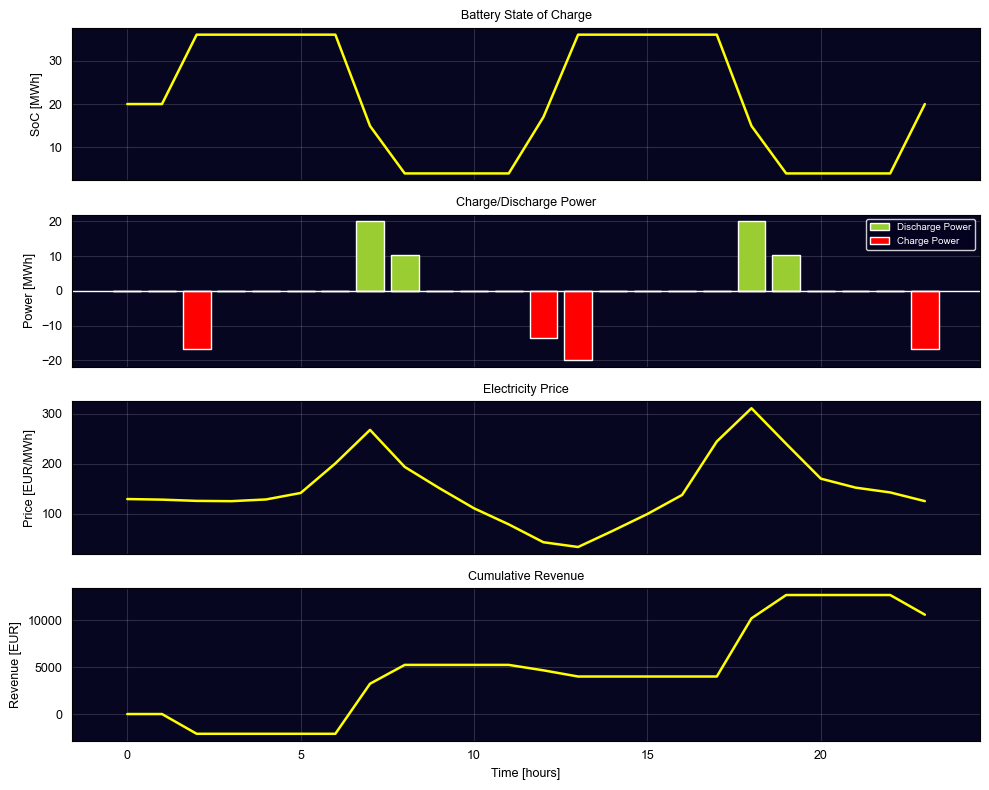

In [89]:
# =========================================================
# Battery Step 9. Forecast-based schedule plot (presentation style)
# =========================================================

# Build plotting dataframe
plot_bess = bess_day_forecast.copy()

# Use actual prices for the price panel and realized revenue
plot_bess["price_actual"] = day_df["actual"].values
plot_bess["cum_revenue_eur"] = plot_bess["cashflow_eur"].cumsum()

# Create figure
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, facecolor="white")

# Common dark style for all panels
for ax in axes:
    ax.set_facecolor("#060621")
    ax.grid(True, color="white", alpha=0.15, linewidth=0.8)
    ax.tick_params(colors="black", labelsize=9)
    for spine in ax.spines.values():
        spine.set_color("black")

# ---------------------------------------------------------
# 1) State of charge
# ---------------------------------------------------------
axes[0].plot(
    plot_bess["hour"],
    plot_bess["soc_mwh"],
    color="yellow",
    linewidth=1.8
)
axes[0].set_ylabel("SoC [MWh]", fontsize=9, color="black")
axes[0].set_title("Battery State of Charge", fontsize=9, color="black")

# ---------------------------------------------------------
# 2) Charge / discharge power
# ---------------------------------------------------------
axes[1].bar(
    plot_bess["hour"],
    plot_bess["discharge_mwh"],
    color="yellowgreen",
    label="Discharge Power"
)
axes[1].bar(
    plot_bess["hour"],
    -plot_bess["charge_mwh"],
    color="red",
    label="Charge Power"
)
axes[1].axhline(0, color="white", linewidth=1)
axes[1].set_ylabel("Power [MWh]", fontsize=9, color="black")
axes[1].set_title("Charge/Discharge Power", fontsize=9, color="black")
axes[1].legend(loc="upper right", fontsize=7, facecolor="#030320", edgecolor="white", labelcolor="white")

# ---------------------------------------------------------
# 3) Electricity price
# ---------------------------------------------------------
axes[2].plot(
    plot_bess["hour"],
    plot_bess["price_actual"],
    color="yellow",
    linewidth=1.8
)
axes[2].set_ylabel("Price [EUR/MWh]", fontsize=9, color="black")
axes[2].set_title("Electricity Price", fontsize=9, color="black")

# ---------------------------------------------------------
# 4) Cumulative revenue
# ---------------------------------------------------------
axes[3].plot(
    plot_bess["hour"],
    plot_bess["cum_revenue_eur"],
    color="yellow",
    linewidth=1.8
)
axes[3].set_ylabel("Revenue [EUR]", fontsize=9, color="black")
axes[3].set_title("Cumulative Revenue", fontsize=9, color="black")
axes[3].set_xlabel("Time [hours]", fontsize=9, color="black")

# X-axis
axes[3].set_xticks(range(0, 25, 5))

plt.tight_layout()
plt.show()

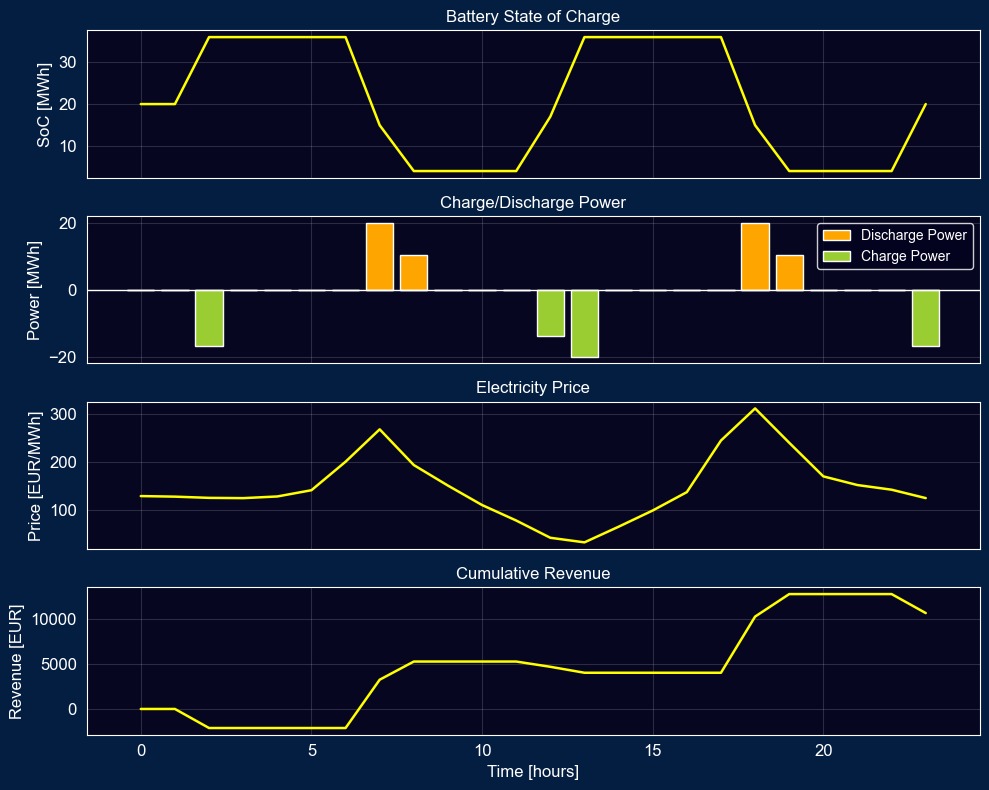

In [94]:
# =========================================================
# Battery Step 9. Forecast-based schedule plot (presentation style)
# =========================================================

# Build plotting dataframe
plot_bess = bess_day_forecast.copy()

# Use actual prices for the price panel and realized revenue
plot_bess["price_actual"] = day_df["actual"].values
plot_bess["cum_revenue_eur"] = plot_bess["cashflow_eur"].cumsum()

# Create figure
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, facecolor="#041E42")

# Common dark style for all panels
for ax in axes:
    ax.set_facecolor("#060621")
    ax.grid(True, color="white", alpha=0.15, linewidth=0.8)
    ax.tick_params(colors="white", labelsize=12)
    for spine in ax.spines.values():
        spine.set_color("white")

# ---------------------------------------------------------
# 1) State of charge
# ---------------------------------------------------------
axes[0].plot(
    plot_bess["hour"],
    plot_bess["soc_mwh"],
    color="yellow",
    linewidth=1.8
)
axes[0].set_ylabel("SoC [MWh]", fontsize=12, color="white")
axes[0].set_title("Battery State of Charge", fontsize=12, color="white")

# ---------------------------------------------------------
# 2) Charge / discharge power
# ---------------------------------------------------------
axes[1].bar(
    plot_bess["hour"],
    plot_bess["discharge_mwh"],
    color="orange",
    label="Discharge Power"
)
axes[1].bar(
    plot_bess["hour"],
    -plot_bess["charge_mwh"],
    color="yellowgreen",
    label="Charge Power"
)
axes[1].axhline(0, color="white", linewidth=1)
axes[1].set_ylabel("Power [MWh]", fontsize=12, color="white")
axes[1].set_title("Charge/Discharge Power", fontsize=12, color="white")
axes[1].legend(
    loc="upper right",
    fontsize=10,
    facecolor="#030320",
    edgecolor="white",
    labelcolor="white"
)

# ---------------------------------------------------------
# 3) Electricity price
# ---------------------------------------------------------
axes[2].plot(
    plot_bess["hour"],
    plot_bess["price_actual"],
    color="yellow",
    linewidth=1.8
)
axes[2].set_ylabel("Price [EUR/MWh]", fontsize=12, color="white")
axes[2].set_title("Electricity Price", fontsize=12, color="white")

# ---------------------------------------------------------
# 4) Cumulative revenue
# ---------------------------------------------------------
axes[3].plot(
    plot_bess["hour"],
    plot_bess["cum_revenue_eur"],
    color="yellow",
    linewidth=1.8
)
axes[3].set_ylabel("Revenue [EUR]", fontsize=12, color="white")
axes[3].set_title("Cumulative Revenue", fontsize=12, color="white")
axes[3].set_xlabel("Time [hours]", fontsize=12, color="white")

# X-axis
axes[3].set_xticks(range(0, 25, 5))

plt.tight_layout()
plt.show()

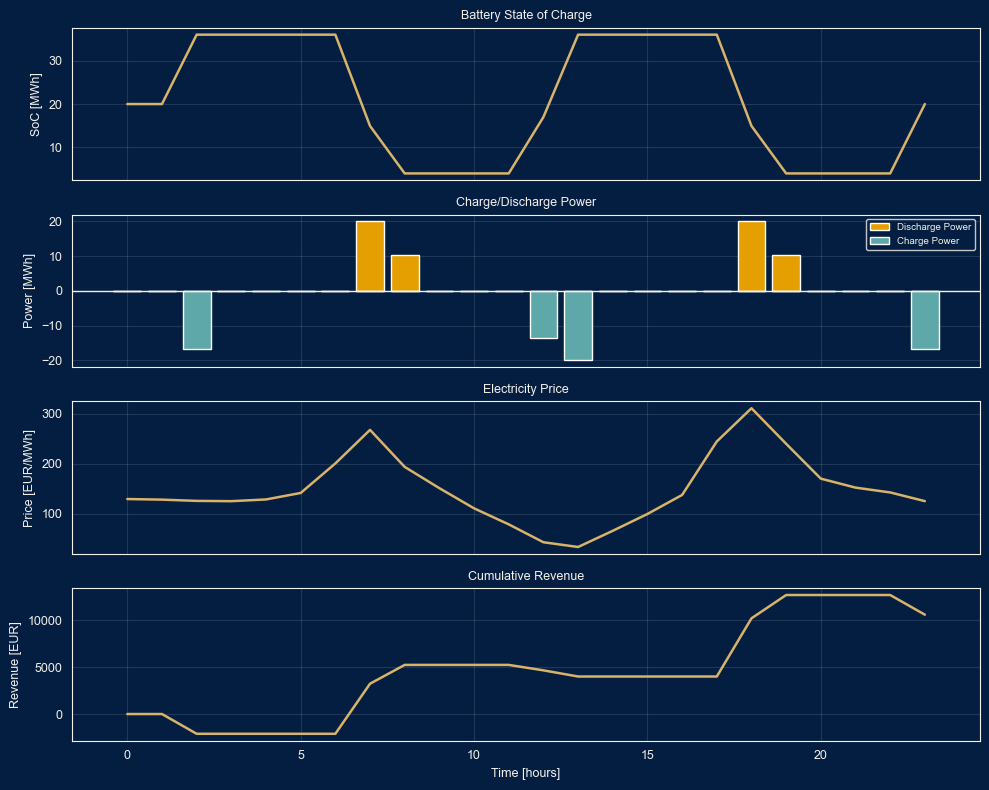

In [91]:
# =========================================================
# Battery Step 9. Forecast-based schedule plot (presentation style)
# =========================================================

# Build plotting dataframe
plot_bess = bess_day_forecast.copy()

# Use actual prices for the price panel and realized revenue
plot_bess["price_actual"] = day_df["actual"].values
plot_bess["cum_revenue_eur"] = plot_bess["cashflow_eur"].cumsum()

# Presentation colors
bg_color = "#041E42"        # presentation navy
text_color = "#F3F1EA"      # warm white
grid_color = "#F3F1EA"
soc_color = "#D8B36A"       # muted gold
charge_color = "#5FA8A9"    # same green as before
discharge_color = "#E69F00" # orange

# Create figure
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, facecolor=bg_color)

# Common slide style for all panels
for ax in axes:
    ax.set_facecolor(bg_color)
    ax.grid(True, color=grid_color, alpha=0.12, linewidth=0.8)
    ax.tick_params(colors=text_color, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(text_color)

# ---------------------------------------------------------
# 1) State of charge
# ---------------------------------------------------------
axes[0].plot(
    plot_bess["hour"],
    plot_bess["soc_mwh"],
    color=soc_color,
    linewidth=1.8
)
axes[0].set_ylabel("SoC [MWh]", fontsize=9, color=text_color)
axes[0].set_title("Battery State of Charge", fontsize=9, color=text_color)

# ---------------------------------------------------------
# 2) Charge / discharge power
# ---------------------------------------------------------
axes[1].bar(
    plot_bess["hour"],
    plot_bess["discharge_mwh"],
    color=discharge_color,
    label="Discharge Power"
)
axes[1].bar(
    plot_bess["hour"],
    -plot_bess["charge_mwh"],
    color=charge_color,
    label="Charge Power"
)
axes[1].axhline(0, color=text_color, linewidth=1)
axes[1].set_ylabel("Power [MWh]", fontsize=9, color=text_color)
axes[1].set_title("Charge/Discharge Power", fontsize=9, color=text_color)
axes[1].legend(
    loc="upper right",
    fontsize=7,
    facecolor=bg_color,
    edgecolor=text_color,
    labelcolor=text_color
)

# ---------------------------------------------------------
# 3) Electricity price
# ---------------------------------------------------------
axes[2].plot(
    plot_bess["hour"],
    plot_bess["price_actual"],
    color=soc_color,
    linewidth=1.8
)
axes[2].set_ylabel("Price [EUR/MWh]", fontsize=9, color=text_color)
axes[2].set_title("Electricity Price", fontsize=9, color=text_color)

# ---------------------------------------------------------
# 4) Cumulative revenue
# ---------------------------------------------------------
axes[3].plot(
    plot_bess["hour"],
    plot_bess["cum_revenue_eur"],
    color=soc_color,
    linewidth=1.8
)
axes[3].set_ylabel("Revenue [EUR]", fontsize=9, color=text_color)
axes[3].set_title("Cumulative Revenue", fontsize=9, color=text_color)
axes[3].set_xlabel("Time [hours]", fontsize=9, color=text_color)

# X-axis
axes[3].set_xticks(range(0, 25, 5))

plt.tight_layout()
plt.show()

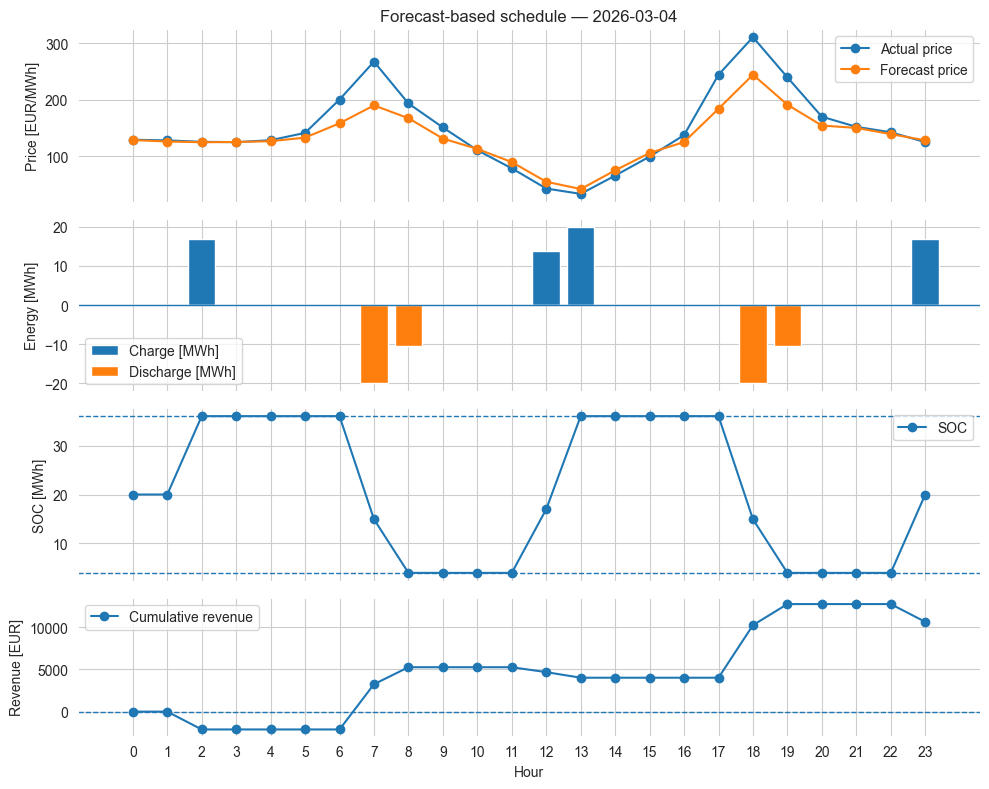

In [97]:
# =========================================================
# Battery Step 9. Forecast-based schedule with revenue panel
# =========================================================

# Build plotting dataframe
plot_bess = bess_day_forecast.copy()

# Add actual and forecast prices from the selected day
plot_bess["price_actual"] = day_df["actual"].values
plot_bess["price_forecast"] = day_df["forecast"].values

# Cumulative realized revenue based on actual settlement prices
plot_bess["cum_revenue_eur"] = plot_bess["cashflow_eur"].cumsum()

# Create figure with 4 panels
fig, axes = plt.subplots(
    4, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 2, 2, 1.6]}
)

# =========================================================
# 1) Price curves
# =========================================================
axes[0].plot(
    plot_bess["hour"],
    plot_bess["price_actual"],
    marker="o",
    label="Actual price"
)
axes[0].plot(
    plot_bess["hour"],
    plot_bess["price_forecast"],
    marker="o",
    label="Forecast price"
)
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title(f"Forecast-based schedule — {example_day}")
axes[0].legend(loc="upper right")
axes[0].grid(True)

# =========================================================
# 2) Charge / discharge bars
# =========================================================
axes[1].bar(
    plot_bess["hour"],
    plot_bess["charge_mwh"],
    label="Charge [MWh]"
)
axes[1].bar(
    plot_bess["hour"],
    -plot_bess["discharge_mwh"],
    label="Discharge [MWh]"
)
axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Energy [MWh]")
axes[1].legend(loc="lower left")
axes[1].grid(True)

# =========================================================
# 3) SOC trajectory
# =========================================================
axes[2].plot(
    plot_bess["hour"],
    plot_bess["soc_mwh"],
    marker="o",
    label="SOC"
)
axes[2].axhline(soc_min_mwh, linestyle="--", linewidth=1)
axes[2].axhline(soc_max_mwh, linestyle="--", linewidth=1)
axes[2].set_ylabel("SOC [MWh]")
axes[2].legend(loc="upper right")
axes[2].grid(True)

# =========================================================
# 4) Cumulative revenue
# =========================================================
axes[3].plot(
    plot_bess["hour"],
    plot_bess["cum_revenue_eur"],
    marker="o",
    label="Cumulative revenue"
)
axes[3].axhline(0, linestyle="--", linewidth=1)
axes[3].set_ylabel("Revenue [EUR]")
axes[3].set_xlabel("Hour")
axes[3].legend(loc="upper left")
axes[3].grid(True)

# X-axis formatting
axes[3].set_xticks(range(24))

plt.tight_layout()
plt.show()

In [61]:
# =========================================================
# Battery Step 10. Run battery optimization for all test days
# =========================================================

# Store hourly and daily results
all_day_results_perfect = []
all_day_summaries_perfect = []

all_day_results_forecast = []
all_day_summaries_forecast = []

# Loop over all days in the test period
for date, group in bess_input_hourly.groupby("date"):
    # Sort one daily block
    group = group.sort_values("timestamp").reset_index(drop=True)

    # Skip incomplete days
    if len(group) != 24:
        continue

    timestamps_day = group["timestamp"].to_numpy()
    hours_day = group["hour"].to_numpy()
    actual_prices_day = group["actual"].to_numpy()
    forecast_prices_day = group["forecast"].to_numpy()

    # -----------------------------------------------------
    # Perfect foresight: optimize and settle on actual prices
    # -----------------------------------------------------
    day_result_perfect, daily_summary_perfect = optimize_bess_day(
        prices=actual_prices_day,
        timestamps=timestamps_day,
        hours=hours_day
    )
    day_result_perfect["date"] = date
    all_day_results_perfect.append(day_result_perfect)
    all_day_summaries_perfect.append(daily_summary_perfect)

    # -----------------------------------------------------
    # Forecast-based: optimize on forecast, settle on actual
    # -----------------------------------------------------
    day_result_forecast, daily_summary_forecast = optimize_bess_day_with_settlement(
        opt_prices=forecast_prices_day,
        settle_prices=actual_prices_day,
        timestamps=timestamps_day,
        hours=hours_day
    )
    day_result_forecast["date"] = date
    all_day_results_forecast.append(day_result_forecast)
    all_day_summaries_forecast.append(daily_summary_forecast)

# Combine results
bess_hourly_perfect = pd.concat(all_day_results_perfect, ignore_index=True)
bess_daily_perfect = pd.DataFrame(all_day_summaries_perfect)

bess_hourly_forecast = pd.concat(all_day_results_forecast, ignore_index=True)
bess_daily_forecast = pd.DataFrame(all_day_summaries_forecast)

# Quick checks
print("Number of optimized days (perfect):", len(bess_daily_perfect))
print("Number of optimized days (forecast):", len(bess_daily_forecast))

display(bess_daily_perfect.head())
display(bess_daily_forecast.head())

Number of optimized days (perfect): 247
Number of optimized days (forecast): 247


,date,daily_profit_eur,total_charge_mwh,total_discharge_mwh
0,2025-07-01,12117.473263,84.210526,76.00
1,2025-07-02,5958.395789,84.210526,76.00
2,2025-07-03,3854.741474,67.368421,60.80
3,2025-07-04,4601.357553,116.842105,105.45
4,2025-07-05,3553.129170,125.318560,113.10


,date,daily_profit_eur,total_charge_mwh,total_discharge_mwh
0,2025-07-01,11876.276632,84.210526,76.0
1,2025-07-02,5591.685053,84.210526,76.0
2,2025-07-03,3428.226105,84.210526,76.0
3,2025-07-04,4594.555211,73.684211,66.5
4,2025-07-05,3520.436789,176.842105,159.6


In [62]:
# =========================================================
# Battery Step 11. Summarize total results
# =========================================================

# Perfect-foresight summary
total_profit_perfect_eur = bess_daily_perfect["daily_profit_eur"].sum()
avg_daily_profit_perfect_eur = bess_daily_perfect["daily_profit_eur"].mean()
total_charge_perfect_mwh = bess_daily_perfect["total_charge_mwh"].sum()
total_discharge_perfect_mwh = bess_daily_perfect["total_discharge_mwh"].sum()

# Forecast-based summary
total_profit_forecast_eur = bess_daily_forecast["daily_profit_eur"].sum()
avg_daily_profit_forecast_eur = bess_daily_forecast["daily_profit_eur"].mean()
total_charge_forecast_mwh = bess_daily_forecast["total_charge_mwh"].sum()
total_discharge_forecast_mwh = bess_daily_forecast["total_discharge_mwh"].sum()

print("Perfect foresight:")
print(f"  Total profit [EUR]: {total_profit_perfect_eur:.2f}")
print(f"  Average daily profit [EUR/day]: {avg_daily_profit_perfect_eur:.2f}")
print(f"  Total charged energy [MWh]: {total_charge_perfect_mwh:.2f}")
print(f"  Total discharged energy [MWh]: {total_discharge_perfect_mwh:.2f}")

print("\nForecast based:")
print(f"  Total profit [EUR]: {total_profit_forecast_eur:.2f}")
print(f"  Average daily profit [EUR/day]: {avg_daily_profit_forecast_eur:.2f}")
print(f"  Total charged energy [MWh]: {total_charge_forecast_mwh:.2f}")
print(f"  Total discharged energy [MWh]: {total_discharge_forecast_mwh:.2f}")

Perfect foresight:
  Total profit [EUR]: 801507.33
  Average daily profit [EUR/day]: 3244.97
  Total charged energy [MWh]: 18848.92
  Total discharged energy [MWh]: 17011.15

Forecast based:
  Total profit [EUR]: 743185.61
  Average daily profit [EUR/day]: 3008.85
  Total charged energy [MWh]: 19679.83
  Total discharged energy [MWh]: 17761.05


In [63]:
# =========================================================
# Battery Step 12. Build compact scenario comparison table
# =========================================================

bess_comparison = pd.DataFrame({
    "scenario": ["Perfect_Foresight", "Forecast_Based"],
    "total_profit_eur": [
        total_profit_perfect_eur,
        total_profit_forecast_eur
    ],
    "avg_daily_profit_eur": [
        avg_daily_profit_perfect_eur,
        avg_daily_profit_forecast_eur
    ],
    "total_charge_mwh": [
        total_charge_perfect_mwh,
        total_charge_forecast_mwh
    ],
    "total_discharge_mwh": [
        total_discharge_perfect_mwh,
        total_discharge_forecast_mwh
    ]
})

profit_gap_total = total_profit_perfect_eur - total_profit_forecast_eur
avg_profit_gap_daily = avg_daily_profit_perfect_eur - avg_daily_profit_forecast_eur

display(bess_comparison.round(2))

print(f"Total profit gap [EUR]: {profit_gap_total:.2f}")
print(f"Average daily profit gap [EUR/day]: {avg_profit_gap_daily:.2f}")

,scenario,total_profit_eur,avg_daily_profit_eur,total_charge_mwh,total_discharge_mwh
0,Perfect_Foresight,801507.33,3244.97,18848.92,17011.15
1,Forecast_Based,743185.61,3008.85,19679.83,17761.05


Total profit gap [EUR]: 58321.72
Average daily profit gap [EUR/day]: 236.12


C:\Users\atefe\AppData\Local\Temp\ipykernel_2792\3870548815.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(daily_profit_compare.head().round(2))


,date,profit_perfect_eur,profit_forecast_eur,profit_gap_eur
0,2025-07-01,12117.47,11876.28,241.20
1,2025-07-02,5958.40,5591.69,366.71
2,2025-07-03,3854.74,3428.23,426.52
3,2025-07-04,4601.36,4594.56,6.80
4,2025-07-05,3553.13,3520.44,32.69


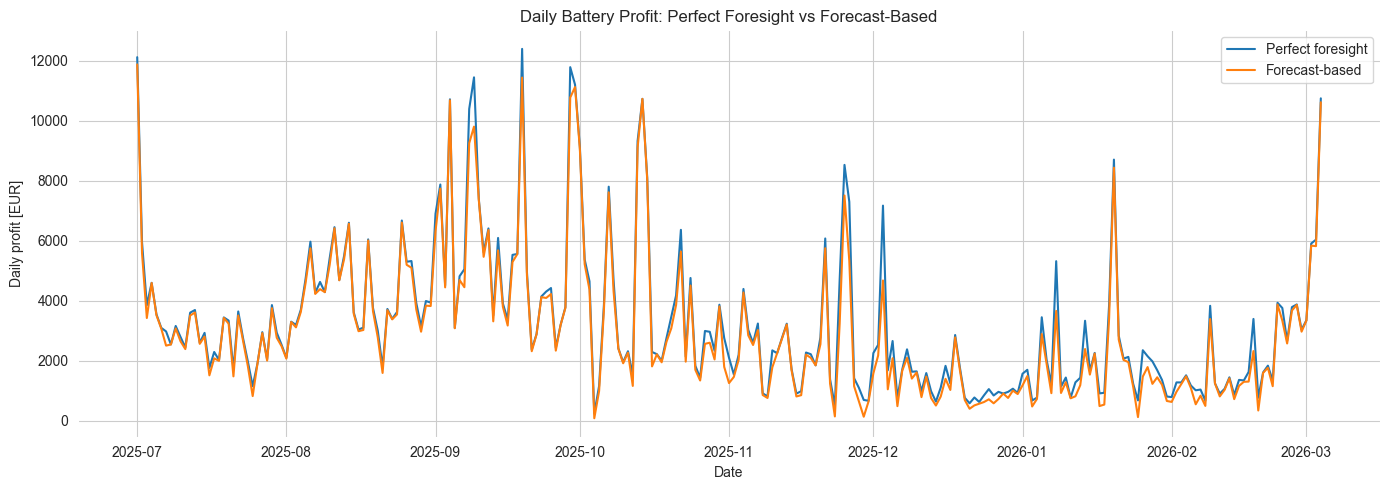

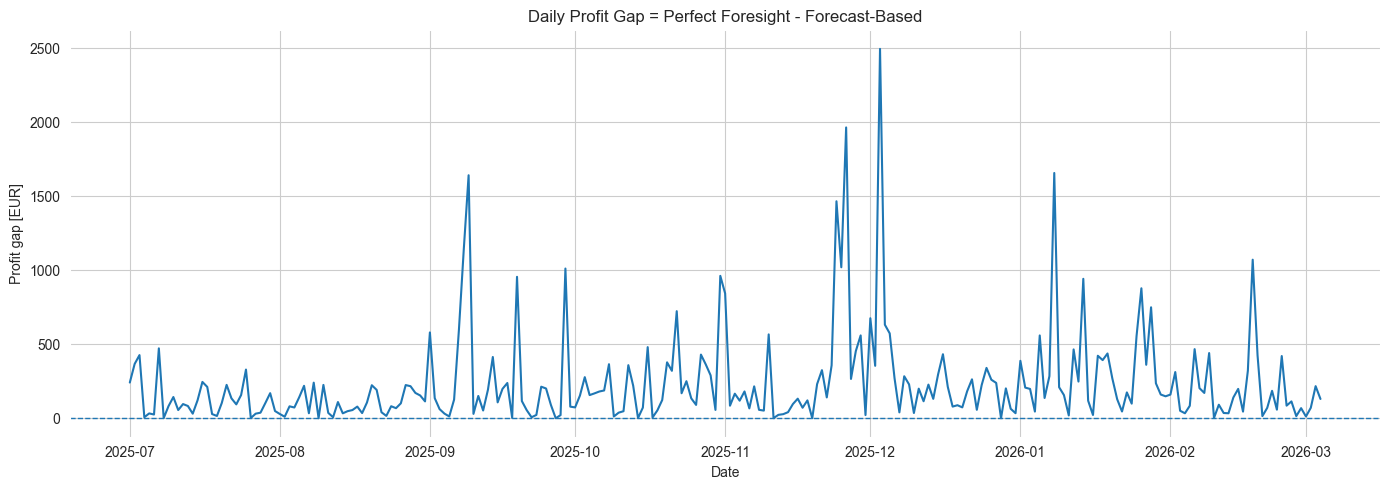

C:\Users\atefe\AppData\Local\Temp\ipykernel_2792\3870548815.py:82: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(monthly_profit_compare.round(2))


,month,profit_perfect_eur,profit_forecast_eur,profit_gap_eur
0,2025-07-01,100338.81,96220.97,4117.84
1,2025-08-01,132323.68,129161.81,3161.87
2,2025-09-01,180132.80,171650.07,8482.73
3,2025-10-01,121735.33,114598.70,7136.63
4,2025-11-01,76637.92,66973.17,9664.75
5,2025-12-01,47873.15,38568.15,9305.00
6,2026-01-01,63853.57,53143.46,10710.10
7,2026-02-01,52564.02,47250.75,5313.27
8,2026-03-01,26048.05,25618.54,429.52


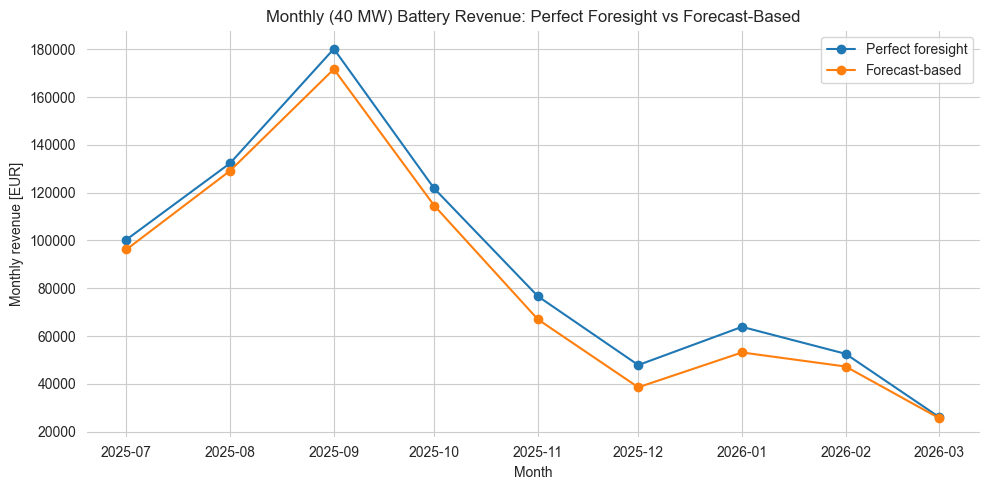

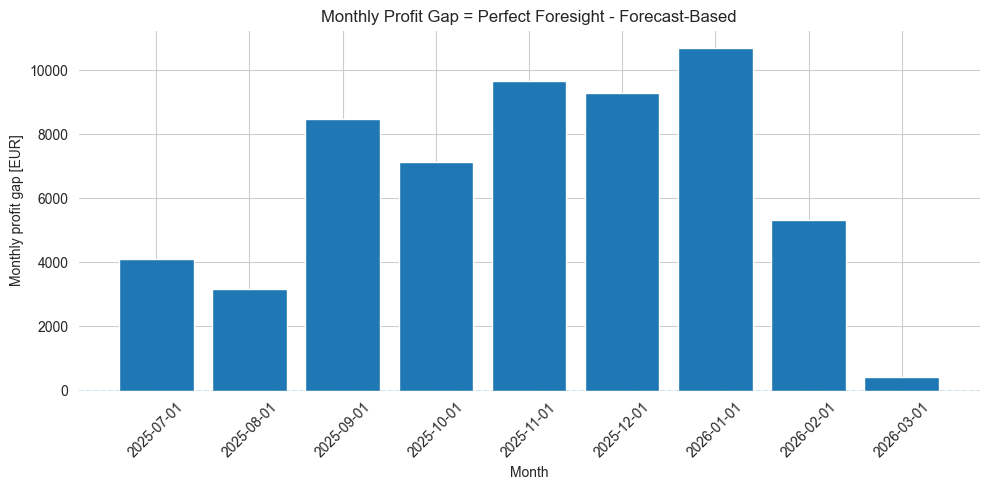

In [116]:
# =========================================================
# Battery Step 13. Build daily profit comparison table
# =========================================================

# Merge daily profits from both scenarios
daily_profit_compare = bess_daily_perfect[["date", "daily_profit_eur"]].rename(
    columns={"daily_profit_eur": "profit_perfect_eur"}
).merge(
    bess_daily_forecast[["date", "daily_profit_eur"]].rename(
        columns={"daily_profit_eur": "profit_forecast_eur"}
    ),
    on="date",
    how="inner"
)

# Daily profit gap
daily_profit_compare["profit_gap_eur"] = (
    daily_profit_compare["profit_perfect_eur"]
    - daily_profit_compare["profit_forecast_eur"]
)

display(daily_profit_compare.head().round(2))

# =========================================================
# Battery Step 14. Plot daily profits for both scenarios
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily_profit_compare["date"],
    daily_profit_compare["profit_perfect_eur"],
    label="Perfect foresight"
)

plt.plot(
    daily_profit_compare["date"],
    daily_profit_compare["profit_forecast_eur"],
    label="Forecast-based"
)

plt.xlabel("Date")
plt.ylabel("Daily profit [EUR]")
plt.title("Daily Battery Profit: Perfect Foresight vs Forecast-Based")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Battery Step 15. Plot daily profit gap
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily_profit_compare["date"],
    daily_profit_compare["profit_gap_eur"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Date")
plt.ylabel("Profit gap [EUR]")
plt.title("Daily Profit Gap = Perfect Foresight - Forecast-Based")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Battery Step 16. Build monthly profit comparison table
# =========================================================

daily_profit_compare["month"] = daily_profit_compare["date"].dt.to_period("M").dt.to_timestamp()

monthly_profit_compare = daily_profit_compare.groupby("month", as_index=False).agg({
    "profit_perfect_eur": "sum",
    "profit_forecast_eur": "sum",
    "profit_gap_eur": "sum"
})

display(monthly_profit_compare.round(2))

# =========================================================
# Battery Step 17. Plot monthly revenue comparison
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profit_compare["month"],
    monthly_profit_compare["profit_perfect_eur"],
    marker="o",
    label="Perfect foresight"
)

plt.plot(
    monthly_profit_compare["month"],
    monthly_profit_compare["profit_forecast_eur"],
    marker="o",
    label="Forecast-based"
)

plt.xlabel("Month")
plt.ylabel("Monthly revenue [EUR]")
plt.title("Monthly (40 MW) Battery Revenue: Perfect Foresight vs Forecast-Based")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Battery Step 18. Plot monthly profit gap
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_profit_compare["month"].astype(str),
    monthly_profit_compare["profit_gap_eur"]
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Month")
plt.ylabel("Monthly profit gap [EUR]")
plt.title("Monthly Profit Gap = Perfect Foresight - Forecast-Based")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

,scenario,total_profit_eur
0,Perfect_Foresight,801507.33
1,Forecast_Based,743185.61


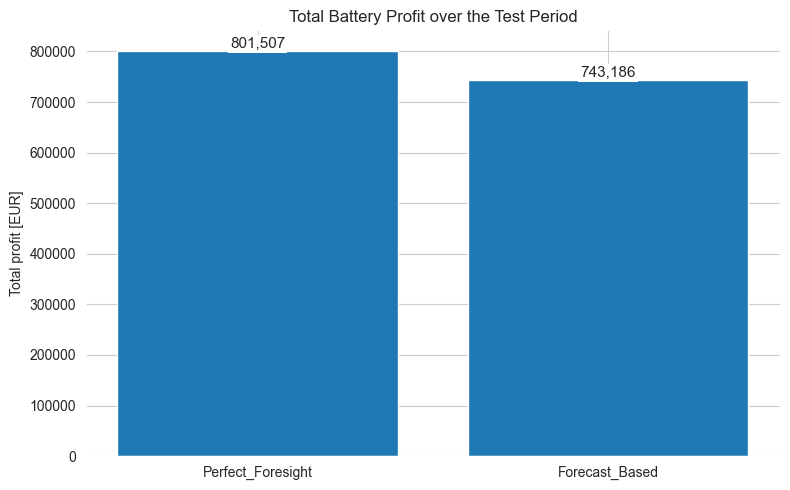

In [65]:
# =========================================================
# Battery Step 19. Total profit comparison
# =========================================================

# Build summary dataframe
summary_profit = pd.DataFrame({
    "scenario": ["Perfect_Foresight", "Forecast_Based"],
    "total_profit_eur": [
        bess_daily_perfect["daily_profit_eur"].sum(),
        bess_daily_forecast["daily_profit_eur"].sum()
    ]
})

display(summary_profit.round(2))

# Plot
plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_profit["scenario"],
    summary_profit["total_profit_eur"]
)

# Add value labels with white background
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5)
    )

plt.ylabel("Total profit [EUR]")
plt.title("Total Battery Profit over the Test Period")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [66]:
# =========================================================
# Battery Step 20. Normalize profit by battery size
# =========================================================

battery_power_mw = max_discharge_mw
battery_energy_mwh = capacity_mwh

summary_profit = pd.DataFrame({
    "scenario": ["Perfect_Foresight", "Forecast_Based"],
    "total_profit_eur": [
        bess_daily_perfect["daily_profit_eur"].sum(),
        bess_daily_forecast["daily_profit_eur"].sum()
    ],
    "profit_per_mw_eur": [
        bess_daily_perfect["daily_profit_eur"].sum() / battery_power_mw,
        bess_daily_forecast["daily_profit_eur"].sum() / battery_power_mw
    ],
    "profit_per_mwh_eur": [
        bess_daily_perfect["daily_profit_eur"].sum() / battery_energy_mwh,
        bess_daily_forecast["daily_profit_eur"].sum() / battery_energy_mwh
    ]
})

display(summary_profit.round(2))

,scenario,total_profit_eur,profit_per_mw_eur,profit_per_mwh_eur
0,Perfect_Foresight,801507.33,40075.37,20037.68
1,Forecast_Based,743185.61,37159.28,18579.64


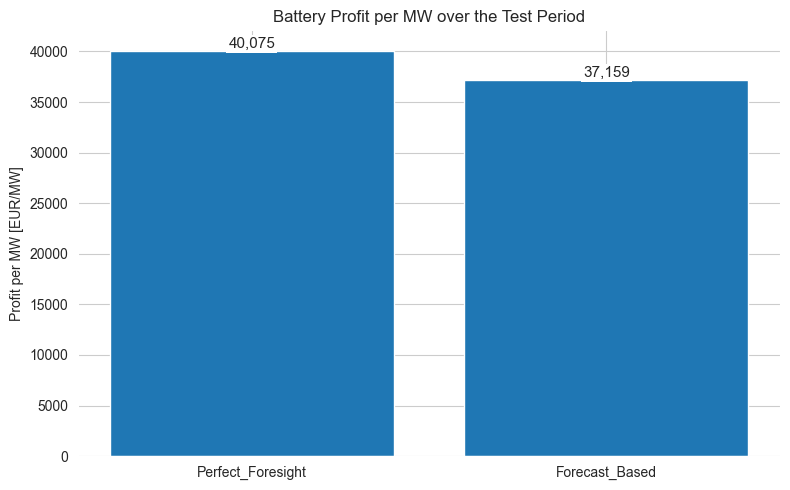

In [67]:
# =========================================================
# Battery Step 21. Plot profit per MW
# =========================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_profit["scenario"],
    summary_profit["profit_per_mw_eur"]
)

# Add value labels with white background
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5)
    )

plt.ylabel("Profit per MW [EUR/MW]")
plt.title("Battery Profit per MW over the Test Period")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

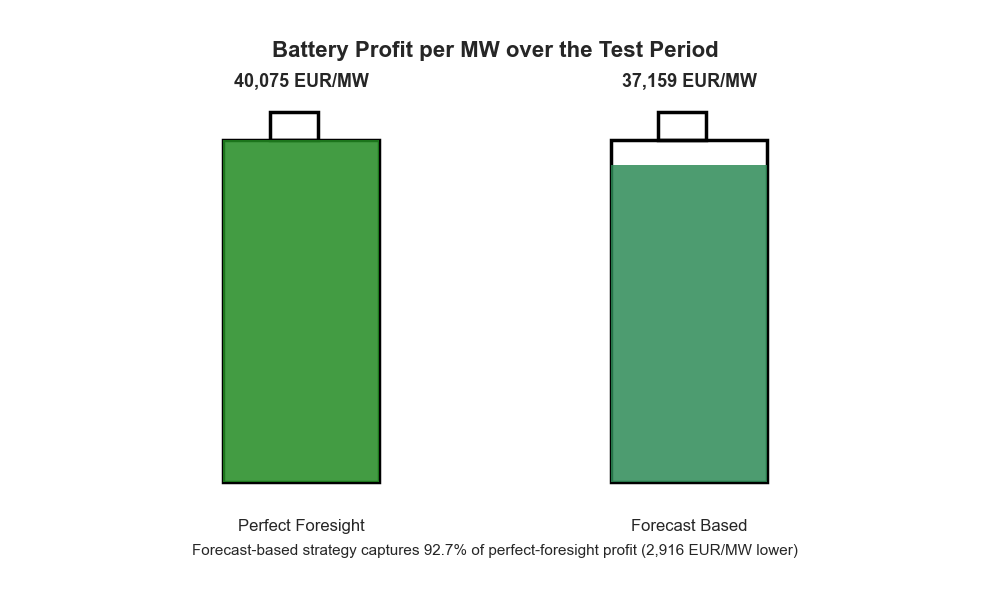

In [72]:
# =========================================================
# Battery-style profit comparison
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Normalize fill level relative to the best value
max_profit = max(profits)
fill_levels = [p / max_profit for p in profits]

# Figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis("off")

# Battery positions
x_positions = [2.2, 6.2]
battery_width = 1.6
battery_height = 4.2
cap_width = 0.5
cap_height = 0.35

for x, label, profit, fill in zip(x_positions, labels, profits, fill_levels):
    y = 1.2

    # Battery outer body
    body = Rectangle(
        (x, y), battery_width, battery_height,
        fill=False, linewidth=2.5, edgecolor="black"
    )
    ax.add_patch(body)

    # Battery cap
    cap = Rectangle(
        (x + battery_width * 0.3, y + battery_height),
        cap_width, cap_height,
        fill=False, linewidth=2.5, edgecolor="black"
    )
    ax.add_patch(cap)

    # Filled portion
    fill_rect = Rectangle(
        (x, y),
        battery_width,
        battery_height * fill,
        facecolor="forestgreen" if label == "Perfect Foresight" else "seagreen",
        edgecolor="none",
        alpha=0.85
    )
    ax.add_patch(fill_rect)

    # Profit label
    ax.text(
        x + battery_width / 2,
        y + battery_height + 0.6,
        f"{profit:,.0f} EUR/MW",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

    # Category label
    ax.text(
        x + battery_width / 2,
        y - 0.45,
        label,
        ha="center",
        va="top",
        fontsize=12
    )

# Title
ax.text(
    5, 6.5,
    "Battery Profit per MW over the Test Period",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

# Optional note
gap = profits[0] - profits[1]
ax.text(
    5, 0.35,
    f"Forecast-based strategy captures {profits[1]/profits[0]*100:.1f}% of perfect-foresight profit "
    f"({gap:,.0f} EUR/MW lower)",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout()
plt.show()

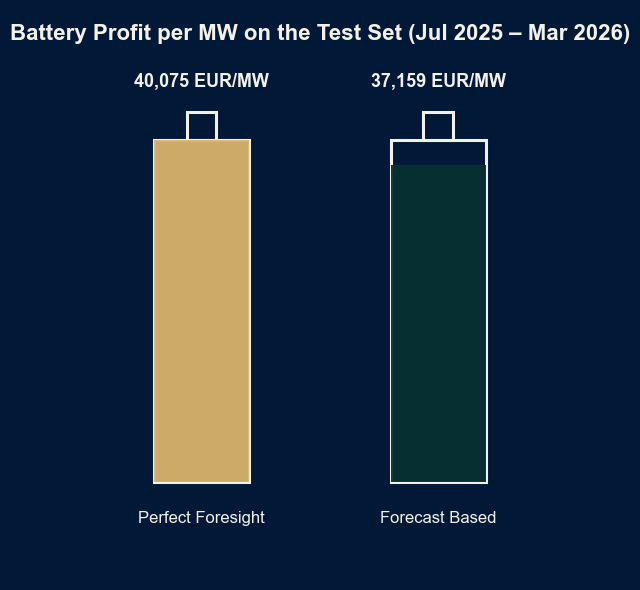

In [86]:
# =========================================================
# Battery-style profit comparison in presentation colors
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors matching the slide
bg_color = "#021837"         # dark navy
text_color = "#F3F1EA"       # warm white
perfect_color = "#D8B36A"    # muted gold
forecast_color = "#073132"   # soft teal

# Normalize fill level relative to the best value
max_profit = max(profits)
fill_levels = [p / max_profit for p in profits]

# Figure
fig, ax = plt.subplots(figsize=(7, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis("off")

# Battery settings
x_positions = [2.2, 6.2]
battery_width = 1.6
battery_height = 4.2
cap_width = 0.5
cap_height = 0.35

for x, label, profit, fill in zip(x_positions, labels, profits, fill_levels):
    y = 1.2
    fill_color = perfect_color if label == "Perfect Foresight" else forecast_color

    # Battery body
    body = Rectangle(
        (x, y), battery_width, battery_height,
        fill=False, linewidth=2.2, edgecolor=text_color
    )
    ax.add_patch(body)

    # Battery cap
    cap = Rectangle(
        (x + battery_width * 0.34, y + battery_height),
        cap_width, cap_height,
        fill=False, linewidth=2.2, edgecolor=text_color
    )
    ax.add_patch(cap)

    # Filled level
    fill_rect = Rectangle(
        (x, y),
        battery_width,
        battery_height * fill,
        facecolor=fill_color,
        edgecolor="none",
        alpha=0.95
    )
    ax.add_patch(fill_rect)

    # Profit value
    ax.text(
        x + battery_width / 2,
        y + battery_height + 0.6,
        f"{profit:,.0f} EUR/MW",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=text_color
    )

    # Label
    ax.text(
        x + battery_width / 2,
        y - 0.35,
        label,
        ha="center",
        va="top",
        fontsize=12,
        color=text_color
    )

# Title
ax.text(
    5, 6.7,
    "Battery Profit per MW on the Test Set (Jul 2025 – Mar 2026)",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color=text_color
)

# Bottom annotation
capture_ratio = profits[1] / profits[0] * 100
gap = profits[0] - profits[1]

#ax.text(
   # 5, 0.35,
   # f"Forecast-based strategy captures {capture_ratio:.1f}% of the perfect-foresight benchmark",
  #  ha="center",
  #  va="center",
   # fontsize=11,
   # color=text_color
#)

plt.tight_layout()
plt.show()

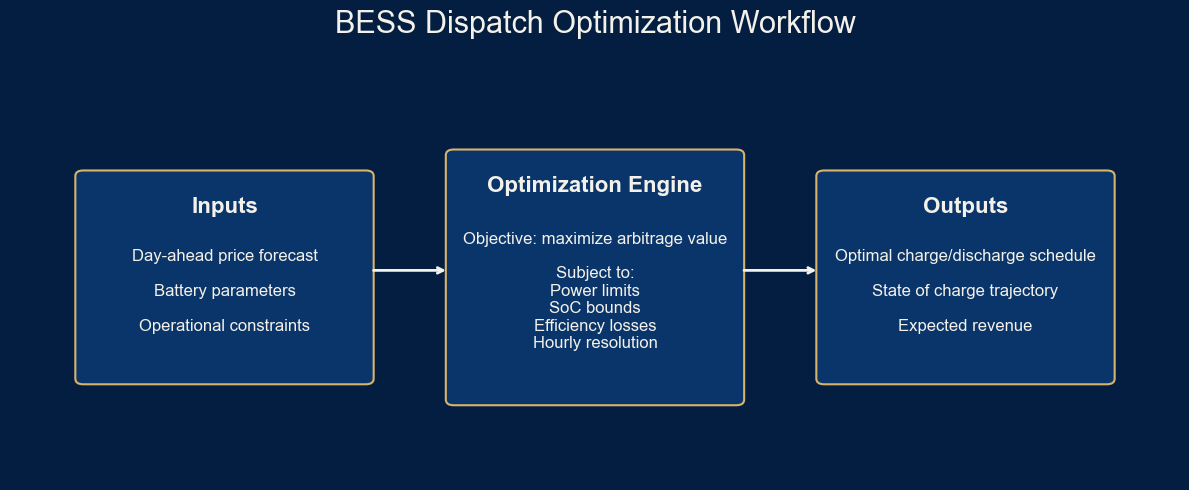

In [98]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Colors
bg = "#041E42"
box = "#0A356B"
text = "#F3F1EA"
accent = "#D8B36A"

fig, ax = plt.subplots(figsize=(12, 5), facecolor=bg)
ax.set_facecolor(bg)
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

def add_box(x, y, w, h, title, lines, title_color=text):
    rect = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5,
        edgecolor=accent,
        facecolor=box
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.35, title,
            ha="center", va="top", fontsize=16, color=title_color, weight="bold")
    ax.text(x + w/2, y + h/2 - 0.2, lines,
            ha="center", va="center", fontsize=12, color=text)

# Left: inputs
add_box(
    0.7, 1.4, 3.0, 3.0,
    "Inputs",
    "Day-ahead price forecast\n\nBattery parameters\n\nOperational constraints"
)

# Middle: optimization
add_box(
    4.5, 1.1, 3.0, 3.6,
    "Optimization Engine",
    "Objective: maximize arbitrage value\n\nSubject to:\nPower limits\nSoC bounds\nEfficiency losses\nHourly resolution"
)

# Right: outputs
add_box(
    8.3, 1.4, 3.0, 3.0,
    "Outputs",
    "Optimal charge/discharge schedule\n\nState of charge trajectory\n\nExpected revenue"
)

# Arrows
ax.annotate("", xy=(4.5, 3.0), xytext=(3.7, 3.0),
            arrowprops=dict(arrowstyle="->", color=text, lw=2))
ax.annotate("", xy=(8.3, 3.0), xytext=(7.5, 3.0),
            arrowprops=dict(arrowstyle="->", color=text, lw=2))

ax.set_title("BESS Dispatch Optimization Workflow", fontsize=22, color=text, pad=20)

plt.tight_layout()
plt.show()

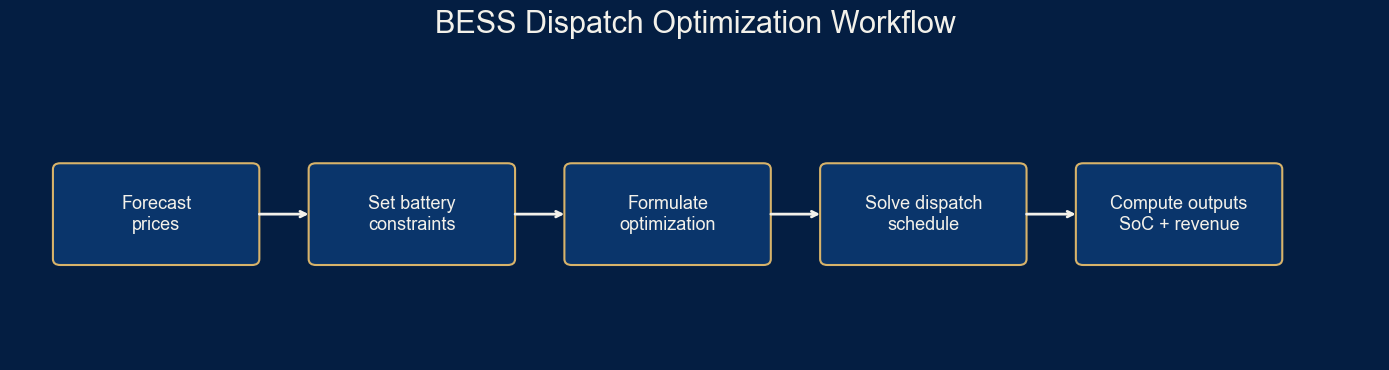

In [99]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

bg = "#041E42"
box = "#0A356B"
text = "#F3F1EA"
accent = "#D8B36A"

steps = [
    "Forecast\nprices",
    "Set battery\nconstraints",
    "Formulate\noptimization",
    "Solve dispatch\nschedule",
    "Compute outputs\nSoC + revenue"
]

fig, ax = plt.subplots(figsize=(14, 3.8), facecolor=bg)
ax.set_facecolor(bg)
ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
ax.axis("off")

x_positions = [0.5, 3.3, 6.1, 8.9, 11.7]

for i, (x, label) in enumerate(zip(x_positions, steps)):
    rect = FancyBboxPatch(
        (x, 1.3), 2.2, 1.3,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5,
        edgecolor=accent,
        facecolor=box
    )
    ax.add_patch(rect)
    ax.text(x + 1.1, 1.95, label, ha="center", va="center", fontsize=13, color=text)

    if i < len(x_positions) - 1:
        ax.annotate("", xy=(x + 2.8, 1.95), xytext=(x + 2.2, 1.95),
                    arrowprops=dict(arrowstyle="->", color=text, lw=2))

ax.set_title("BESS Dispatch Optimization Workflow", fontsize=22, color=text, pad=20)

plt.tight_layout()
plt.show()

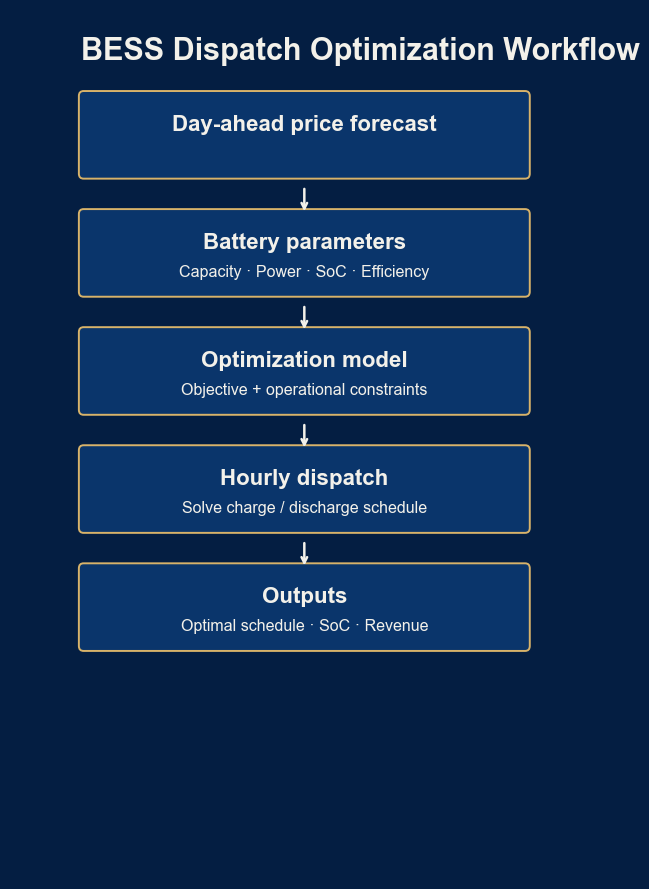

In [100]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------
bg_color = "#041E42"      # slide navy
box_color = "#0A356B"     # slightly lighter blue
text_color = "#F3F1EA"    # warm white
accent_color = "#D8B36A"  # muted gold

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 9), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

# ---------------------------------------------------------
# Helper function
# ---------------------------------------------------------
def add_box(x, y, w, h, title, subtitle=None):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.4,
        edgecolor=accent_color,
        facecolor=box_color
    )
    ax.add_patch(box)

    ax.text(
        x + w / 2, y + h * 0.63,
        title,
        ha="center", va="center",
        fontsize=16, color=text_color, fontweight="bold"
    )

    if subtitle:
        ax.text(
            x + w / 2, y + h * 0.28,
            subtitle,
            ha="center", va="center",
            fontsize=11.5, color=text_color
        )

# ---------------------------------------------------------
# Boxes
# ---------------------------------------------------------
x = 1.2
w = 7.6
h = 1.35

ys = [11.3, 9.4, 7.5, 5.6, 3.7]

titles = [
    "Day-ahead price forecast",
    "Battery parameters",
    "Optimization model",
    "Hourly dispatch",
    "Outputs"
]

subtitles = [
    None,
    "Capacity · Power · SoC · Efficiency",
    "Objective + operational constraints",
    "Solve charge / discharge schedule",
    "Optimal schedule · SoC · Revenue"
]

for y, title, subtitle in zip(ys, titles, subtitles):
    add_box(x, y, w, h, title, subtitle)

# ---------------------------------------------------------
# Arrows
# ---------------------------------------------------------
for i in range(len(ys) - 1):
    x_arrow = x + w / 2
    y_top = ys[i] - 0.15
    y_bottom = ys[i + 1] + h + 0.15

    ax.annotate(
        "",
        xy=(x_arrow, y_bottom - 0.2),
        xytext=(x_arrow, y_top),
        arrowprops=dict(arrowstyle="->", lw=1.8, color=text_color)
    )

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------
ax.text(
    1.2, 13.2,
    "BESS Dispatch Optimization Workflow",
    fontsize=22,
    color=text_color,
    fontweight="bold",
    ha="left"
)

plt.tight_layout()
plt.show()

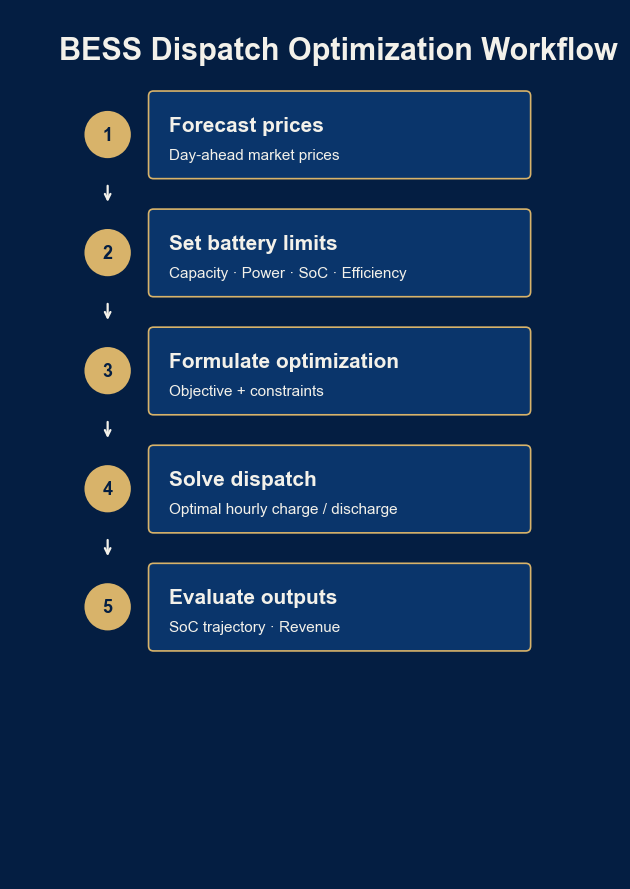

In [103]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle

bg_color = "#041E42"
box_color = "#0A356B"
text_color = "#F3F1EA"
accent_color = "#D8B36A"

fig, ax = plt.subplots(figsize=(7, 9), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

def add_step(y, number, title, subtitle=""):
    # circle
    circ = Circle((1.6, y + 0.68), 0.38, facecolor=accent_color, edgecolor="none")
    ax.add_patch(circ)
    ax.text(1.6, y + 0.68, str(number), ha="center", va="center",
            fontsize=13, color=bg_color, fontweight="bold")

    # box
    box = FancyBboxPatch(
        (2.3, y), 6.2, 1.35,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.2,
        edgecolor=accent_color,
        facecolor=box_color
    )
    ax.add_patch(box)

    ax.text(2.6, y + 0.83, title, ha="left", va="center",
            fontsize=15, color=text_color, fontweight="bold")
    if subtitle:
        ax.text(2.6, y + 0.35, subtitle, ha="left", va="center",
                fontsize=11, color=text_color)

ys = [11.3, 9.4, 7.5, 5.6, 3.7]
steps = [
    (1, "Forecast prices", "Day-ahead market prices"),
    (2, "Set battery limits", "Capacity · Power · SoC · Efficiency"),
    (3, "Formulate optimization", "Objective + constraints"),
    (4, "Solve dispatch", "Optimal hourly charge / discharge"),
    (5, "Evaluate outputs", "SoC trajectory · Revenue")
]

for y, (n, t, s) in zip(ys, steps):
    add_step(y, n, t, s)

for i in range(len(ys) - 1):
    ax.annotate(
        "",
        xy=(1.6, ys[i + 1] + 1.45),
        xytext=(1.6, ys[i] - 0.1),
        arrowprops=dict(arrowstyle="->", lw=1.6, color=text_color)
    )

ax.text(
    0.8, 13.2,
    "BESS Dispatch Optimization Workflow",
    fontsize=22,
    color=text_color,
    fontweight="bold",
    ha="left"
)

plt.tight_layout()
plt.show()

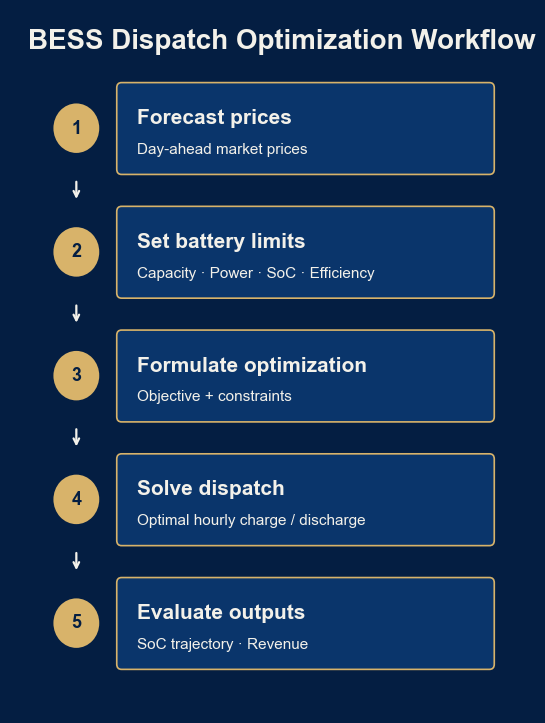

In [104]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle

bg_color = "#041E42"
box_color = "#0A356B"
text_color = "#F3F1EA"
accent_color = "#D8B36A"

fig, ax = plt.subplots(figsize=(6, 7.2), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.set_xlim(0.5, 9.2)
ax.set_ylim(3.0, 13.8)
ax.axis("off")

def add_step(y, number, title, subtitle=""):
    # circle
    circ = Circle((1.6, y + 0.68), 0.38, facecolor=accent_color, edgecolor="none")
    ax.add_patch(circ)
    ax.text(
        1.6, y + 0.68, str(number),
        ha="center", va="center",
        fontsize=13, color=bg_color, fontweight="bold"
    )

    # box
    box = FancyBboxPatch(
        (2.3, y), 6.2, 1.35,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.2,
        edgecolor=accent_color,
        facecolor=box_color
    )
    ax.add_patch(box)

    ax.text(
        2.6, y + 0.83, title,
        ha="left", va="center",
        fontsize=15, color=text_color, fontweight="bold"
    )
    if subtitle:
        ax.text(
            2.6, y + 0.35, subtitle,
            ha="left", va="center",
            fontsize=11, color=text_color
        )

ys = [11.3, 9.4, 7.5, 5.6, 3.7]
steps = [
    (1, "Forecast prices", "Day-ahead market prices"),
    (2, "Set battery limits", "Capacity · Power · SoC · Efficiency"),
    (3, "Formulate optimization", "Objective + constraints"),
    (4, "Solve dispatch", "Optimal hourly charge / discharge"),
    (5, "Evaluate outputs", "SoC trajectory · Revenue")
]

for y, (n, t, s) in zip(ys, steps):
    add_step(y, n, t, s)

for i in range(len(ys) - 1):
    ax.annotate(
        "",
        xy=(1.6, ys[i + 1] + 1.45),
        xytext=(1.6, ys[i] - 0.1),
        arrowprops=dict(arrowstyle="->", lw=1.6, color=text_color)
    )

ax.text(
    0.8, 13.2,
    "BESS Dispatch Optimization Workflow",
    fontsize=20,
    color=text_color,
    fontweight="bold",
    ha="left"
)

plt.tight_layout(pad=0.6)
plt.show()

In [105]:
plt.savefig("bess_workflow.png", dpi=300, bbox_inches="tight", pad_inches=0.05)

<Figure size 640x480 with 0 Axes>

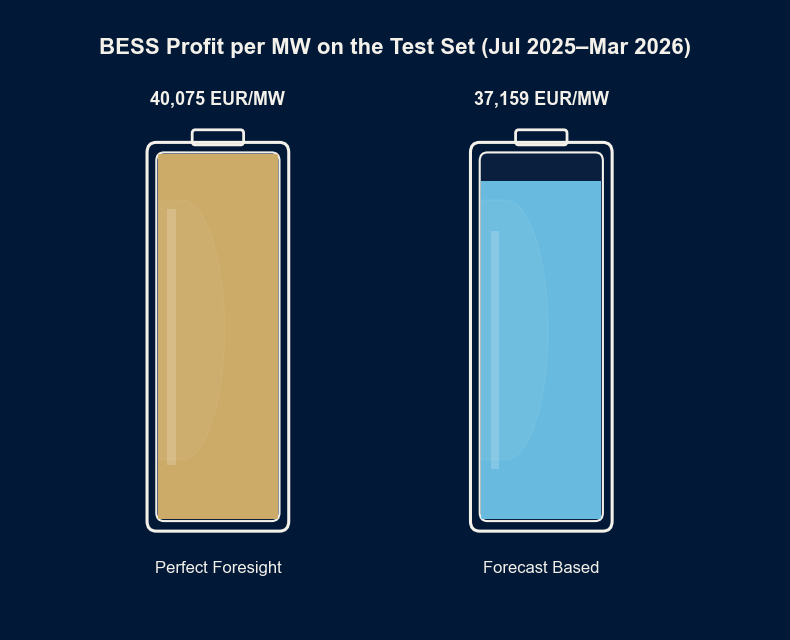

In [106]:
# =========================================================
# Battery-style profit comparison with rounded battery shape
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
import numpy as np

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors matching the presentation
bg_color = "#021837"         # dark navy
text_color = "#F3F1EA"       # warm white
perfect_color = "#D8B36A"    # muted gold
forecast_color = "#6EC5E9"   # light blue like the image

# Normalize fill level relative to the best value
max_profit = max(profits)
fill_levels = [p / max_profit for p in profits]

# Figure
fig, ax = plt.subplots(figsize=(8, 6.5), facecolor=bg_color)
ax.set_facecolor(bg_color)
ax.set_xlim(0, 10)
ax.set_ylim(0, 7.4)
ax.axis("off")


def draw_battery(ax, x, y, width, height, fill_frac, fill_color, edge_color, label, value):
    # Outer rounded battery body
    outer = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        linewidth=2.2,
        edgecolor=edge_color,
        facecolor="none"
    )
    ax.add_patch(outer)

    # Inner rounded area
    inner_margin = 0.12
    inner_x = x + inner_margin
    inner_y = y + inner_margin
    inner_w = width - 2 * inner_margin
    inner_h = height - 2 * inner_margin

    inner = FancyBboxPatch(
        (inner_x, inner_y),
        inner_w,
        inner_h,
        boxstyle="round,pad=0.02,rounding_size=0.10",
        linewidth=1.5,
        edgecolor=edge_color,
        facecolor=(1, 1, 1, 0.03)
    )
    ax.add_patch(inner)

    # Battery cap
    cap_w = width * 0.36
    cap_h = 0.16
    cap_x = x + (width - cap_w) / 2
    cap_y = y + height
    cap = FancyBboxPatch(
        (cap_x, cap_y),
        cap_w,
        cap_h,
        boxstyle="round,pad=0.01,rounding_size=0.04",
        linewidth=2.0,
        edgecolor=edge_color,
        facecolor="none"
    )
    ax.add_patch(cap)

    # Filled liquid area
    liquid_h = inner_h * fill_frac
    liquid = Rectangle(
        (inner_x, inner_y),
        inner_w,
        liquid_h,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Soft highlight on liquid
    highlight = Rectangle(
        (inner_x + inner_w * 0.08, inner_y + liquid_h * 0.15),
        inner_w * 0.07,
        liquid_h * 0.7,
        linewidth=0,
        facecolor="white",
        alpha=0.18
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Slight curved glossy overlay
    theta = np.linspace(-np.pi/2, np.pi/2, 200)
    arc_x = inner_x + inner_w * 0.2 + 0.55 * np.cos(theta)
    arc_y = inner_y + inner_h * 0.52 + 1.55 * np.sin(theta)
    ax.fill_betweenx(
        arc_y,
        inner_x,
        np.minimum(arc_x, inner_x + inner_w),
        color="white",
        alpha=0.05
    )

    # Value
    ax.text(
        x + width / 2,
        y + height + 0.42,
        f"{value:,.0f} EUR/MW",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=text_color
    )

    # Label
    ax.text(
        x + width / 2,
        y - 0.38,
        label,
        ha="center",
        va="top",
        fontsize=12,
        color=text_color
    )


# Battery positions and size
draw_battery(
    ax=ax,
    x=1.8, y=1.2,
    width=1.8, height=4.6,
    fill_frac=fill_levels[0],
    fill_color=perfect_color,
    edge_color=text_color,
    label=labels[0],
    value=profits[0]
)

draw_battery(
    ax=ax,
    x=6.0, y=1.2,
    width=1.8, height=4.6,
    fill_frac=fill_levels[1],
    fill_color=forecast_color,
    edge_color=text_color,
    label=labels[1],
    value=profits[1]
)

# Title
ax.text(
    5,
    6.95,
    "BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color=text_color
)

plt.tight_layout()
plt.show()

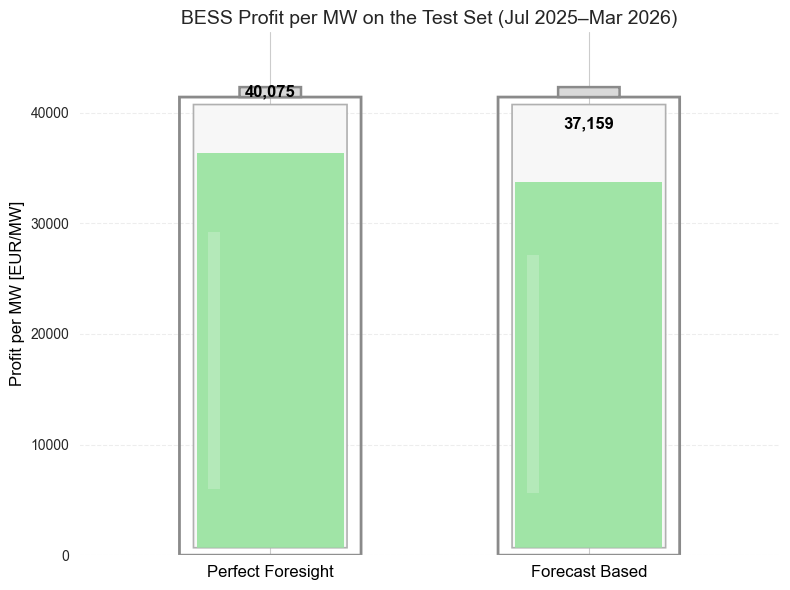

In [107]:
# =========================================================
# Battery-style profit comparison with grey battery shell
# and light-green fill on white background
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors
bg_color = "white"
shell_color = "#8A8A8A"      # grey battery shell
inner_edge_color = "#B0B0B0" # lighter grey inner border
fill_color = "#9BE3A2"       # light green fill
text_color = "black"

# Scale settings
y_max = 45000
battery_width = 0.55

# Figure
fig, ax = plt.subplots(figsize=(8, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

# X positions
xpos = [0, 1]

def draw_battery_data(ax, x_center, value, width, y_max):
    # Battery geometry in data coordinates
    body_bottom = 0
    body_height = y_max * 0.92
    body_left = x_center - width / 2

    # Outer shell
    outer = FancyBboxPatch(
        (body_left, body_bottom),
        width,
        body_height,
        boxstyle="round,pad=0.01,rounding_size=0.08",
        linewidth=2.0,
        edgecolor=shell_color,
        facecolor="none",
        mutation_aspect=1
    )
    ax.add_patch(outer)

    # Inner area
    margin_x = width * 0.08
    margin_y = y_max * 0.015
    inner_left = body_left + margin_x
    inner_bottom = body_bottom + margin_y
    inner_width = width - 2 * margin_x
    inner_height = body_height - 2 * margin_y

    inner = FancyBboxPatch(
        (inner_left, inner_bottom),
        inner_width,
        inner_height,
        boxstyle="round,pad=0.01,rounding_size=0.06",
        linewidth=1.2,
        edgecolor=inner_edge_color,
        facecolor="#F7F7F7"
    )
    ax.add_patch(inner)

    # Fill
    fill_height = inner_height * (value / y_max)
    liquid = Rectangle(
        (inner_left, inner_bottom),
        inner_width,
        fill_height,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Small highlight
    highlight = Rectangle(
        (inner_left + inner_width * 0.08, inner_bottom + fill_height * 0.15),
        inner_width * 0.08,
        fill_height * 0.65,
        linewidth=0,
        facecolor="white",
        alpha=0.22
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Battery cap
    cap_width = width * 0.34
    cap_height = y_max * 0.02
    cap_left = x_center - cap_width / 2
    cap_bottom = body_bottom + body_height
    cap = FancyBboxPatch(
        (cap_left, cap_bottom),
        cap_width,
        cap_height,
        boxstyle="round,pad=0.003,rounding_size=0.02",
        linewidth=1.8,
        edgecolor=shell_color,
        facecolor="#D9D9D9"
    )
    ax.add_patch(cap)

    # Value label
    ax.text(
        x_center,
        value + y_max * 0.025,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=text_color
    )

# Draw batteries
for x, p in zip(xpos, profits):
    draw_battery_data(ax, x, p, battery_width, y_max)

# Axes styling
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, y_max * 1.05)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=12, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=12, color=text_color)
ax.set_title("BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)", fontsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

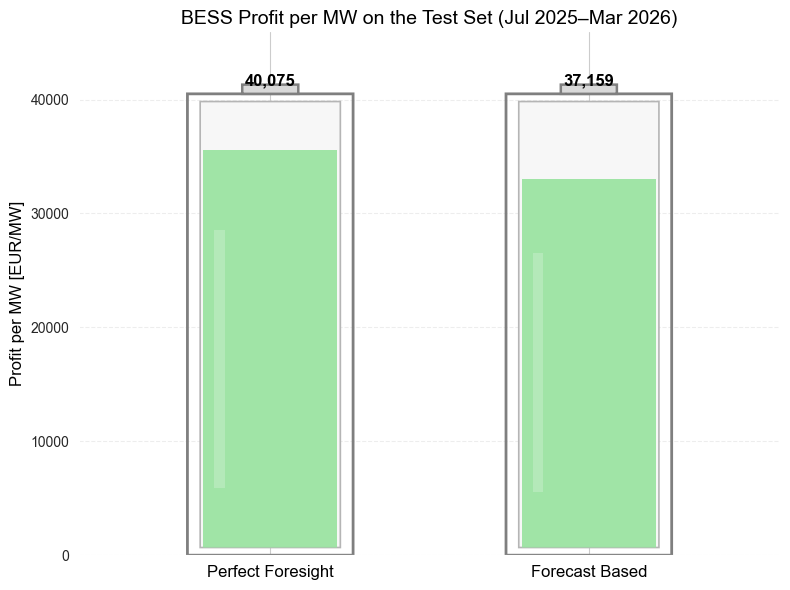

In [108]:
# =========================================================
# Battery-style profit comparison with rounded batteries
# white background, grey shell, green fill
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors
bg_color = "white"
shell_color = "#7F7F7F"
inner_edge_color = "#B5B5B5"
fill_color = "#9BE3A2"
text_color = "black"

# Scale
y_max = 45000
xpos = [0, 1]
battery_width = 0.50

# Figure
fig, ax = plt.subplots(figsize=(8, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

def draw_battery(ax, x_center, value, width, y_max):
    body_bottom = 0
    body_height = y_max * 0.90
    body_left = x_center - width / 2

    # Outer rounded shell
    outer = FancyBboxPatch(
        (body_left, body_bottom),
        width,
        body_height,
        boxstyle="round,pad=0.01,rounding_size=0.10",
        linewidth=2.0,
        edgecolor=shell_color,
        facecolor="none",
        mutation_aspect=1
    )
    ax.add_patch(outer)

    # Inner rounded area
    margin_x = width * 0.08
    margin_y = y_max * 0.015
    inner_left = body_left + margin_x
    inner_bottom = body_bottom + margin_y
    inner_width = width - 2 * margin_x
    inner_height = body_height - 2 * margin_y

    inner = FancyBboxPatch(
        (inner_left, inner_bottom),
        inner_width,
        inner_height,
        boxstyle="round,pad=0.01,rounding_size=0.08",
        linewidth=1.2,
        edgecolor=inner_edge_color,
        facecolor="#F7F7F7"
    )
    ax.add_patch(inner)

    # Fill
    fill_height = inner_height * (value / y_max)
    liquid = Rectangle(
        (inner_left, inner_bottom),
        inner_width,
        fill_height,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Highlight
    highlight = Rectangle(
        (inner_left + inner_width * 0.08, inner_bottom + fill_height * 0.15),
        inner_width * 0.08,
        fill_height * 0.65,
        linewidth=0,
        facecolor="white",
        alpha=0.22
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Cap
    cap_width = width * 0.34
    cap_height = y_max * 0.018
    cap_left = x_center - cap_width / 2
    cap_bottom = body_bottom + body_height
    cap = FancyBboxPatch(
        (cap_left, cap_bottom),
        cap_width,
        cap_height,
        boxstyle="round,pad=0.003,rounding_size=0.02",
        linewidth=1.8,
        edgecolor=shell_color,
        facecolor="#D9D9D9"
    )
    ax.add_patch(cap)

# Draw batteries
for x, p in zip(xpos, profits):
    draw_battery(ax, x, p, battery_width, y_max)

# Put both values at the same height
value_label_y = 41000
for x, p in zip(xpos, profits):
    ax.text(
        x,
        value_label_y,
        f"{p:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=text_color
    )

# Axes styling
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, y_max * 1.02)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=12, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=12, color=text_color)
ax.set_title("BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)", fontsize=14, color=text_color)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

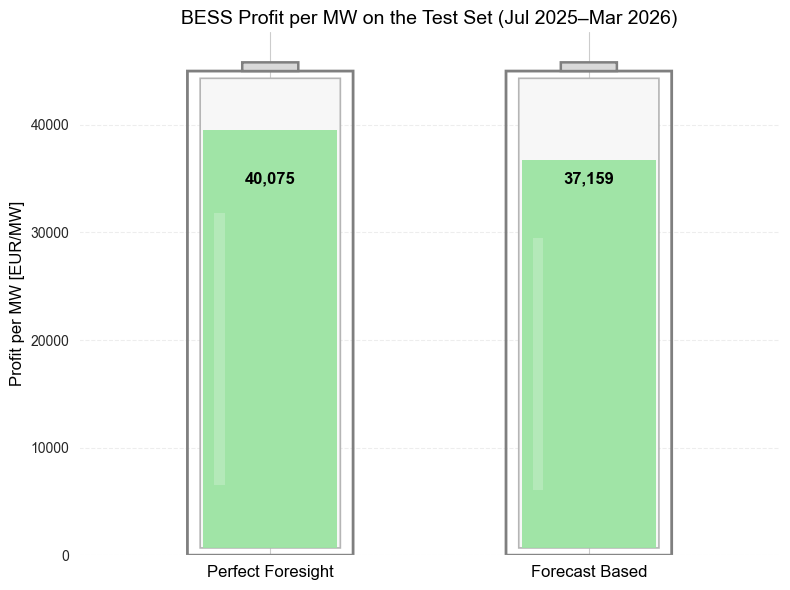

In [109]:
# =========================================================
# Battery-style profit comparison with rounded batteries
# fixed battery height = 45,000 EUR/MW
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors
bg_color = "white"
shell_color = "#7F7F7F"
inner_edge_color = "#B5B5B5"
fill_color = "#9BE3A2"
text_color = "black"

# Fixed battery scale
battery_max = 45000
xpos = [0, 1]
battery_width = 0.50

# Figure
fig, ax = plt.subplots(figsize=(8, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

def draw_battery(ax, x_center, value, width, battery_max):
    body_bottom = 0
    body_height = battery_max
    body_left = x_center - width / 2

    # Outer rounded shell
    outer = FancyBboxPatch(
        (body_left, body_bottom),
        width,
        body_height,
        boxstyle="round,pad=0.01,rounding_size=0.10",
        linewidth=2.0,
        edgecolor=shell_color,
        facecolor="none",
        mutation_aspect=1
    )
    ax.add_patch(outer)

    # Inner rounded area
    margin_x = width * 0.08
    margin_y = battery_max * 0.015
    inner_left = body_left + margin_x
    inner_bottom = body_bottom + margin_y
    inner_width = width - 2 * margin_x
    inner_height = body_height - 2 * margin_y

    inner = FancyBboxPatch(
        (inner_left, inner_bottom),
        inner_width,
        inner_height,
        boxstyle="round,pad=0.01,rounding_size=0.08",
        linewidth=1.2,
        edgecolor=inner_edge_color,
        facecolor="#F7F7F7"
    )
    ax.add_patch(inner)

    # Fill based on fixed battery scale
    fill_height = inner_height * (value / battery_max)
    liquid = Rectangle(
        (inner_left, inner_bottom),
        inner_width,
        fill_height,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Highlight
    highlight = Rectangle(
        (inner_left + inner_width * 0.08, inner_bottom + fill_height * 0.15),
        inner_width * 0.08,
        max(fill_height * 0.65, 0),
        linewidth=0,
        facecolor="white",
        alpha=0.22
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Battery cap
    cap_width = width * 0.34
    cap_height = battery_max * 0.018
    cap_left = x_center - cap_width / 2
    cap_bottom = body_bottom + body_height
    cap = FancyBboxPatch(
        (cap_left, cap_bottom),
        cap_width,
        cap_height,
        boxstyle="round,pad=0.003,rounding_size=0.02",
        linewidth=1.8,
        edgecolor=shell_color,
        facecolor="#D9D9D9"
    )
    ax.add_patch(cap)

# Draw batteries
for x, p in zip(xpos, profits):
    draw_battery(ax, x, p, battery_width, battery_max)

# Put numbers inside batteries at fixed height
label_y = 35000
for x, p in zip(xpos, profits):
    ax.text(
        x,
        label_y,
        f"{p:,.0f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=text_color
    )

# Axes styling
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, battery_max * 1.08)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=12, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=12, color=text_color)
ax.set_title("BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)", fontsize=14, color=text_color)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

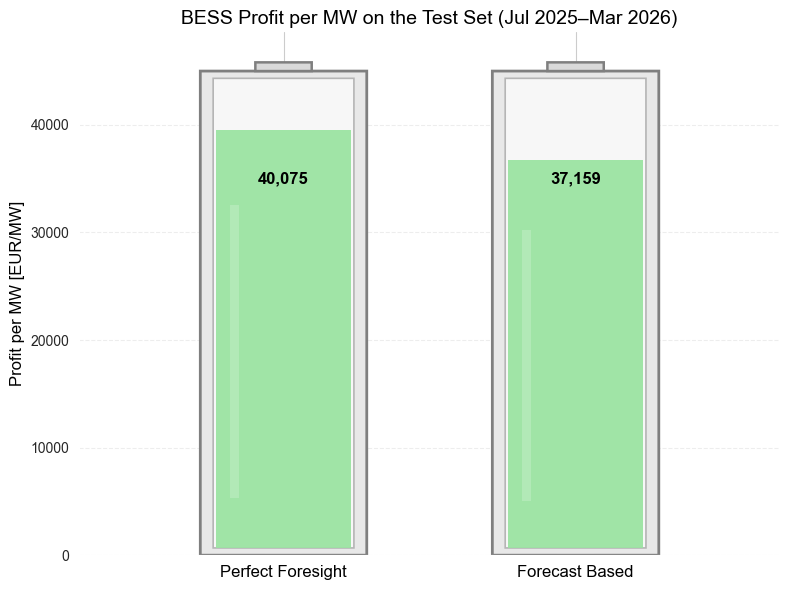

In [110]:
# =========================================================
# Battery-style profit comparison with more rounded batteries
# fixed battery height = 45,000 EUR/MW
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors
bg_color = "white"
shell_color = "#7F7F7F"
inner_edge_color = "#B5B5B5"
fill_color = "#9BE3A2"
text_color = "black"

# Fixed battery scale
battery_max = 45000
xpos = [0, 1]
battery_width = 0.55

# Figure
fig, ax = plt.subplots(figsize=(8, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

def draw_battery(ax, x_center, value, width, battery_max):
    body_bottom = 0
    body_height = battery_max
    body_left = x_center - width / 2

    # Outer rounded shell
    outer = FancyBboxPatch(
        (body_left, body_bottom),
        width,
        body_height,
        boxstyle="round,pad=0.01,rounding_size=0.22",
        linewidth=2.0,
        edgecolor=shell_color,
        facecolor="#E8E8E8",
        mutation_aspect=1
    )
    ax.add_patch(outer)

    # Inner rounded area
    margin_x = width * 0.08
    margin_y = battery_max * 0.015
    inner_left = body_left + margin_x
    inner_bottom = body_bottom + margin_y
    inner_width = width - 2 * margin_x
    inner_height = body_height - 2 * margin_y

    inner = FancyBboxPatch(
        (inner_left, inner_bottom),
        inner_width,
        inner_height,
        boxstyle="round,pad=0.01,rounding_size=0.18",
        linewidth=1.2,
        edgecolor=inner_edge_color,
        facecolor="#F7F7F7"
    )
    ax.add_patch(inner)

    # Fill based on fixed battery scale
    fill_height = inner_height * (value / battery_max)
    liquid = Rectangle(
        (inner_left, inner_bottom),
        inner_width,
        fill_height,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Soft highlight
    highlight = Rectangle(
        (inner_left + inner_width * 0.10, inner_bottom + fill_height * 0.12),
        inner_width * 0.07,
        max(fill_height * 0.70, 0),
        linewidth=0,
        facecolor="white",
        alpha=0.20
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Battery cap
    cap_width = width * 0.34
    cap_height = battery_max * 0.018
    cap_left = x_center - cap_width / 2
    cap_bottom = body_bottom + body_height

    cap = FancyBboxPatch(
        (cap_left, cap_bottom),
        cap_width,
        cap_height,
        boxstyle="round,pad=0.003,rounding_size=0.05",
        linewidth=1.8,
        edgecolor=shell_color,
        facecolor="#D9D9D9"
    )
    ax.add_patch(cap)

# Draw batteries
for x, p in zip(xpos, profits):
    draw_battery(ax, x, p, battery_width, battery_max)

# Put numbers inside batteries at fixed height
label_y = 35000
for x, p in zip(xpos, profits):
    ax.text(
        x,
        label_y,
        f"{p:,.0f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=text_color
    )

# Axes styling
ax.set_xlim(-0.7, 1.7)
ax.set_ylim(0, battery_max * 1.08)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=12, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=12, color=text_color)
ax.set_title("BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)", fontsize=14, color=text_color)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

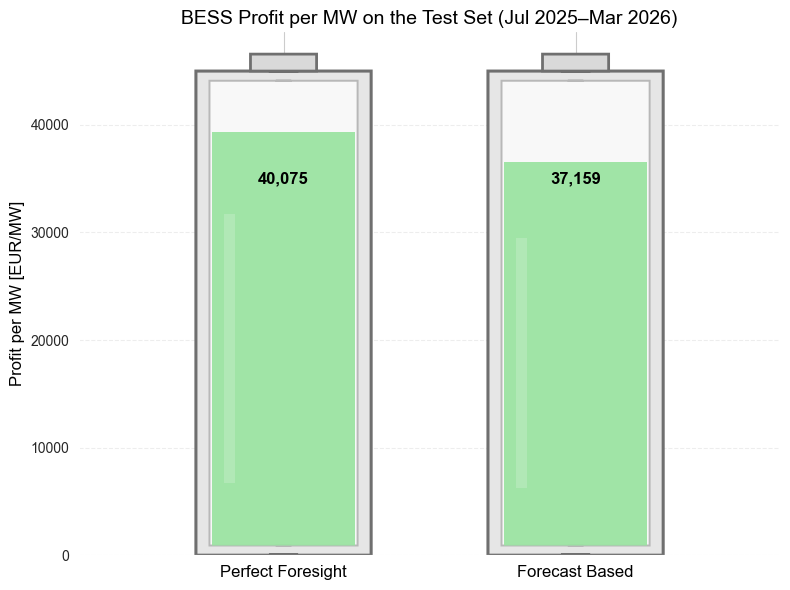

In [111]:
# =========================================================
# Battery-style profit comparison with truly rounded batteries
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors
bg_color = "white"
shell_color = "#6F6F6F"
inner_edge_color = "#B8B8B8"
fill_color = "#9BE3A2"
text_color = "black"

# Fixed battery scale
battery_max = 45000
xpos = [0, 1]
battery_width = 0.58

# Figure
fig, ax = plt.subplots(figsize=(8, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

def draw_battery(ax, x_center, value, width, battery_max):
    body_bottom = 0
    body_height = battery_max
    body_left = x_center - width / 2

    # Outer shell: more rounded
    outer = FancyBboxPatch(
        (body_left, body_bottom),
        width,
        body_height,
        boxstyle="round,pad=0.01,rounding_size=0.35",
        linewidth=2.2,
        edgecolor=shell_color,
        facecolor="#E6E6E6",
        mutation_aspect=1
    )
    ax.add_patch(outer)

    # Inner cavity: strongly rounded
    margin_x = width * 0.08
    margin_y = battery_max * 0.02
    inner_left = body_left + margin_x
    inner_bottom = body_bottom + margin_y
    inner_width = width - 2 * margin_x
    inner_height = body_height - 2 * margin_y

    inner = FancyBboxPatch(
        (inner_left, inner_bottom),
        inner_width,
        inner_height,
        boxstyle="round,pad=0.01,rounding_size=0.28",
        linewidth=1.4,
        edgecolor=inner_edge_color,
        facecolor="#F8F8F8"
    )
    ax.add_patch(inner)

    # Fill clipped to the rounded inner cavity
    fill_height = inner_height * (value / battery_max)
    liquid = Rectangle(
        (inner_left, inner_bottom),
        inner_width,
        fill_height,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Soft vertical highlight
    highlight = Rectangle(
        (inner_left + inner_width * 0.08, inner_bottom + fill_height * 0.15),
        inner_width * 0.08,
        max(fill_height * 0.65, 0),
        linewidth=0,
        facecolor="white",
        alpha=0.18
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Battery cap: rounded
    cap_width = width * 0.38
    cap_height = battery_max * 0.035
    cap_left = x_center - cap_width / 2
    cap_bottom = body_bottom + body_height

    cap = FancyBboxPatch(
        (cap_left, cap_bottom),
        cap_width,
        cap_height,
        boxstyle="round,pad=0.003,rounding_size=0.08",
        linewidth=2.0,
        edgecolor=shell_color,
        facecolor="#D9D9D9"
    )
    ax.add_patch(cap)

# Draw batteries
for x, p in zip(xpos, profits):
    draw_battery(ax, x, p, battery_width, battery_max)

# Numbers inside batteries
label_y = 35000
for x, p in zip(xpos, profits):
    ax.text(
        x,
        label_y,
        f"{p:,.0f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=text_color
    )

# Axes styling
ax.set_xlim(-0.7, 1.7)
ax.set_ylim(0, battery_max * 1.08)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=12, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=12, color=text_color)
ax.set_title("BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)", fontsize=14, color=text_color)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

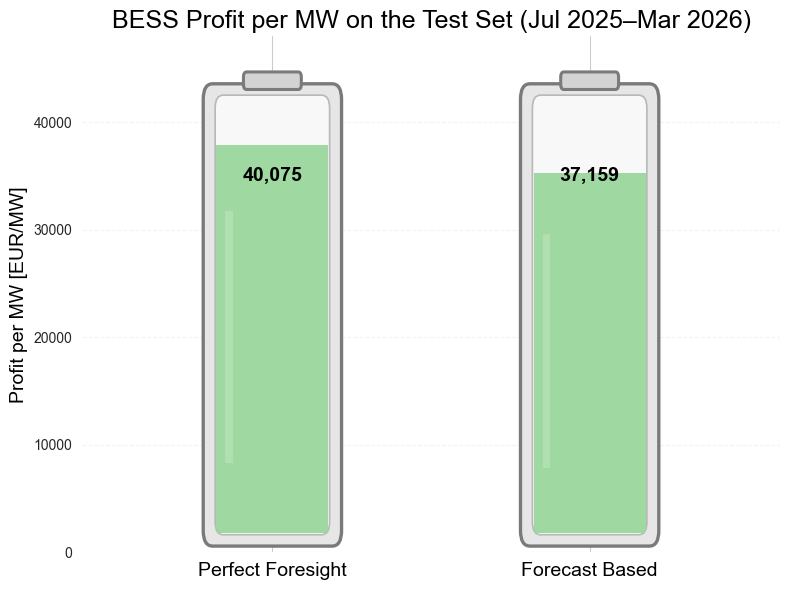

In [112]:
# =========================================================
# Rounded battery chart with true rounded corners
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib import transforms

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors
shell_color = "#7A7A7A"
inner_edge_color = "#B8B8B8"
fill_color = "#9AD79D"
text_color = "black"

battery_max = 45000

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")

# Axes
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, 48000)
ax.set_xticks([0, 1])
ax.set_xticklabels(labels, fontsize=14, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=14, color=text_color)
ax.set_title("BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)", fontsize=18, color=text_color)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------------------------
# Helper: x in data coords, y in axes coords
# ---------------------------------------------------------
trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)

def draw_battery(ax, x_center, value, width_data=0.42):
    # Battery geometry in AXES coordinates
    body_y = 0.02
    body_h = 0.88
    cap_h = 0.028
    cap_w = width_data * 0.42

    x_left = x_center - width_data / 2

    # Outer shell
    outer = FancyBboxPatch(
        (x_left, body_y),
        width_data,
        body_h,
        boxstyle="round,pad=0.008,rounding_size=0.03",
        linewidth=2.4,
        edgecolor=shell_color,
        facecolor="#E6E6E6",
        transform=trans,
        clip_on=False,
        zorder=3
    )
    ax.add_patch(outer)

    # Inner cavity
    margin_x = width_data * 0.08
    margin_y = 0.018
    inner_x = x_left + margin_x
    inner_y = body_y + margin_y
    inner_w = width_data - 2 * margin_x
    inner_h = body_h - 2 * margin_y

    inner = FancyBboxPatch(
        (inner_x, inner_y),
        inner_w,
        inner_h,
        boxstyle="round,pad=0.004,rounding_size=0.025",
        linewidth=1.2,
        edgecolor=inner_edge_color,
        facecolor="#F8F8F8",
        transform=trans,
        clip_on=False,
        zorder=4
    )
    ax.add_patch(inner)

    # Fill level from actual profit / battery_max
    fill_frac = value / battery_max
    fill_h = inner_h * fill_frac

    liquid = Rectangle(
        (inner_x, inner_y),
        inner_w,
        fill_h,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95,
        transform=trans,
        zorder=5
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Highlight
    highlight = Rectangle(
        (inner_x + inner_w * 0.08, inner_y + fill_h * 0.18),
        inner_w * 0.07,
        fill_h * 0.65,
        linewidth=0,
        facecolor="white",
        alpha=0.18,
        transform=trans,
        zorder=6
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Cap
    cap = FancyBboxPatch(
        (x_center - cap_w / 2, body_y + body_h),
        cap_w,
        cap_h,
        boxstyle="round,pad=0.003,rounding_size=0.01",
        linewidth=2.2,
        edgecolor=shell_color,
        facecolor="#D3D3D3",
        transform=trans,
        clip_on=False,
        zorder=7
    )
    ax.add_patch(cap)

# Draw batteries
draw_battery(ax, 0, profits[0])
draw_battery(ax, 1, profits[1])

# Labels inside batteries
label_y = 35000
for x, p in zip([0, 1], profits):
    ax.text(
        x,
        label_y,
        f"{p:,.0f}",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=text_color,
        zorder=10
    )

plt.tight_layout()
plt.show()

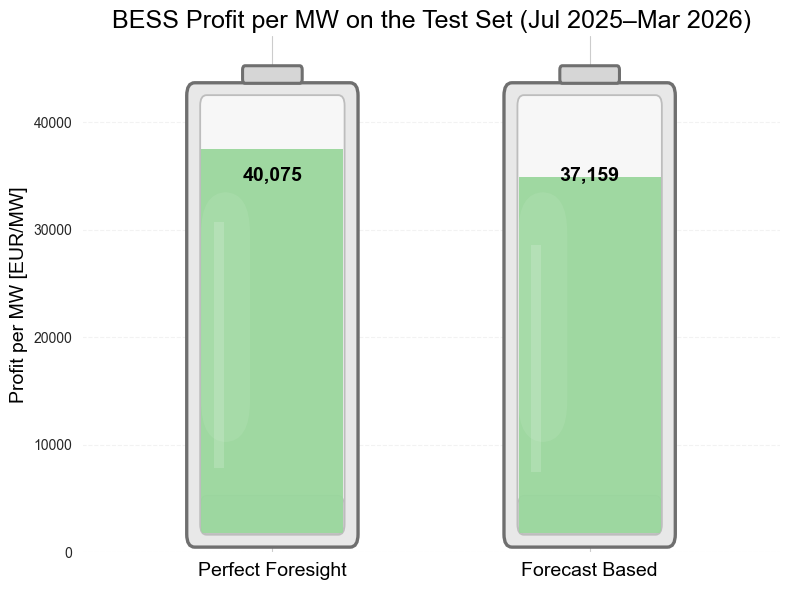

In [113]:
# =========================================================
# Schematic battery chart with image-like battery shape
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib import transforms

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Chart settings
battery_max = 45000
x_positions = [0, 1]

# Colors
shell_edge = "#6F6F6F"
shell_fill = "#E8E8E8"
inner_fill = "#F7F7F7"
inner_edge = "#BDBDBD"
liquid_color = "#9AD79D"
base_band_color = "#D9D9D9"
text_color = "black"

# Figure
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")

# Axes
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, 48000)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, fontsize=14, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=14, color=text_color)
ax.set_title("BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)", fontsize=18, color=text_color)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Use data coordinates in x, axes coordinates in y
trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)

def draw_schematic_battery(ax, x_center, value, width=0.52):
    # Geometry in axes coordinates
    body_y = 0.02
    body_h = 0.88
    body_x = x_center - width / 2

    # Outer shell
    outer = FancyBboxPatch(
        (body_x, body_y),
        width,
        body_h,
        boxstyle="round,pad=0.01,rounding_size=0.025",
        linewidth=2.4,
        edgecolor=shell_edge,
        facecolor=shell_fill,
        transform=trans,
        clip_on=False,
        zorder=3
    )
    ax.add_patch(outer)

    # Inner cavity
    mx = width * 0.07
    my = 0.018
    inner_x = body_x + mx
    inner_y = body_y + my
    inner_w = width - 2 * mx
    inner_h = body_h - 2 * my

    inner = FancyBboxPatch(
        (inner_x, inner_y),
        inner_w,
        inner_h,
        boxstyle="round,pad=0.004,rounding_size=0.020",
        linewidth=1.3,
        edgecolor=inner_edge,
        facecolor=inner_fill,
        transform=trans,
        clip_on=False,
        zorder=4
    )
    ax.add_patch(inner)

    # Bottom base band like in the reference image
    band_h = 0.07
    band = FancyBboxPatch(
        (inner_x, inner_y),
        inner_w,
        band_h,
        boxstyle="round,pad=0.002,rounding_size=0.018",
        linewidth=0.8,
        edgecolor=inner_edge,
        facecolor=base_band_color,
        transform=trans,
        clip_on=False,
        zorder=5
    )
    band.set_clip_path(inner)
    ax.add_patch(band)

    # Fill level
    fill_frac = value / battery_max
    usable_h = inner_h - 0.01
    fill_h = usable_h * fill_frac

    liquid = Rectangle(
        (inner_x, inner_y),
        inner_w,
        fill_h,
        linewidth=0,
        facecolor=liquid_color,
        alpha=0.95,
        transform=trans,
        zorder=5.5
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Soft vertical highlight
    highlight = Rectangle(
        (inner_x + inner_w * 0.09, inner_y + fill_h * 0.17),
        inner_w * 0.07,
        max(fill_h * 0.64, 0),
        linewidth=0,
        facecolor="white",
        alpha=0.16,
        transform=trans,
        zorder=6
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Large curved gloss area
    gloss = FancyBboxPatch(
        (inner_x + inner_w * 0.02, inner_y + inner_h * 0.22),
        inner_w * 0.30,
        inner_h * 0.55,
        boxstyle="round,pad=0.01,rounding_size=0.08",
        linewidth=0,
        facecolor="white",
        alpha=0.08,
        transform=trans,
        zorder=6
    )
    gloss.set_clip_path(inner)
    ax.add_patch(gloss)

    # Top cap
    cap_w = width * 0.35
    cap_h = 0.028
    cap_x = x_center - cap_w / 2
    cap_y = body_y + body_h + 0.012

    cap = FancyBboxPatch(
        (cap_x, cap_y),
        cap_w,
        cap_h,
        boxstyle="round,pad=0.003,rounding_size=0.008",
        linewidth=2.2,
        edgecolor=shell_edge,
        facecolor="#D6D6D6",
        transform=trans,
        clip_on=False,
        zorder=7
    )
    ax.add_patch(cap)

# Draw both batteries
for x, p in zip(x_positions, profits):
    draw_schematic_battery(ax, x, p, width=0.52)

# Value labels inside batteries
label_y = 35000
for x, p in zip(x_positions, profits):
    ax.text(
        x,
        label_y,
        f"{p:,.0f}",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=text_color,
        zorder=10
    )

plt.tight_layout()
plt.show()

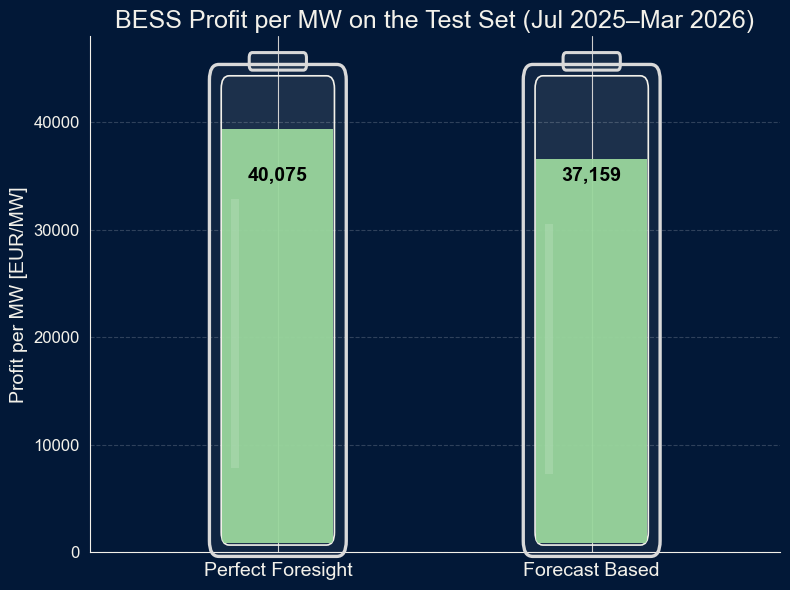

In [115]:
# =========================================================
# Rounded battery chart with correct fill scaling
# and navy presentation background
# =========================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib import transforms

# Data
labels = ["Perfect Foresight", "Forecast Based"]
profits = [40075, 37159]

# Colors
bg_color = "#021837"         # navy background
text_color = "#F3F1EA"       # warm white
shell_color = "#D9D9D9"
inner_edge_color = "#F3F1EA"
fill_color = "#9AD79D"

# Scale
battery_max = 45000
y_max_plot = 48000

fig, ax = plt.subplots(figsize=(8, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Axes
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, y_max_plot)
ax.set_xticks([0, 1])
ax.set_xticklabels(labels, fontsize=14, color=text_color)
ax.set_ylabel("Profit per MW [EUR/MW]", fontsize=14, color=text_color)
ax.set_title(
    "BESS Profit per MW on the Test Set (Jul 2025–Mar 2026)",
    fontsize=18,
    color=text_color
)

ax.grid(axis="y", linestyle="--", alpha=0.18, color="white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(text_color)
ax.spines["bottom"].set_color(text_color)
ax.tick_params(axis="y", colors=text_color, labelsize=12)

# ---------------------------------------------------------
# Helper: x in data coords, y in axes coords
# ---------------------------------------------------------
trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)

def draw_battery(ax, x_center, value, width_data=0.42):
    # Battery geometry in axes coordinates
    body_y = 0.0
    body_h = battery_max / y_max_plot   # matches axis scale exactly
    cap_h = 0.028
    cap_w = width_data * 0.42

    x_left = x_center - width_data / 2

    # Outer shell
    outer = FancyBboxPatch(
        (x_left, body_y),
        width_data,
        body_h,
        boxstyle="round,pad=0.008,rounding_size=0.03",
        linewidth=2.4,
        edgecolor=shell_color,
        facecolor=(1, 1, 1, 0.06),
        transform=trans,
        clip_on=False,
        zorder=3
    )
    ax.add_patch(outer)

    # Inner cavity
    margin_x = width_data * 0.08
    margin_y = 0.018
    inner_x = x_left + margin_x
    inner_y = body_y + margin_y
    inner_w = width_data - 2 * margin_x
    inner_h = body_h - 2 * margin_y

    inner = FancyBboxPatch(
        (inner_x, inner_y),
        inner_w,
        inner_h,
        boxstyle="round,pad=0.004,rounding_size=0.025",
        linewidth=1.2,
        edgecolor=inner_edge_color,
        facecolor=(1, 1, 1, 0.05),
        transform=trans,
        clip_on=False,
        zorder=4
    )
    ax.add_patch(inner)

    # Fill level from actual profit / battery_max
    fill_frac = value / battery_max
    fill_h = inner_h * fill_frac

    liquid = Rectangle(
        (inner_x, inner_y),
        inner_w,
        fill_h,
        linewidth=0,
        facecolor=fill_color,
        alpha=0.95,
        transform=trans,
        zorder=5
    )
    liquid.set_clip_path(inner)
    ax.add_patch(liquid)

    # Highlight
    highlight = Rectangle(
        (inner_x + inner_w * 0.08, inner_y + fill_h * 0.18),
        inner_w * 0.07,
        fill_h * 0.65,
        linewidth=0,
        facecolor="white",
        alpha=0.14,
        transform=trans,
        zorder=6
    )
    highlight.set_clip_path(inner)
    ax.add_patch(highlight)

    # Cap
    cap = FancyBboxPatch(
        (x_center - cap_w / 2, body_y + body_h),
        cap_w,
        cap_h,
        boxstyle="round,pad=0.003,rounding_size=0.01",
        linewidth=2.2,
        edgecolor=shell_color,
        facecolor=(1, 1, 1, 0.08),
        transform=trans,
        clip_on=False,
        zorder=7
    )
    ax.add_patch(cap)

# Draw batteries
draw_battery(ax, 0, profits[0])
draw_battery(ax, 1, profits[1])

# Labels inside batteries
label_y = 35000
for x, p in zip([0, 1], profits):
    ax.text(
        x,
        label_y,
        f"{p:,.0f}",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="black",
        zorder=10
    )

plt.tight_layout()
plt.show()